In [1]:
# -*- coding: utf-8 -*-
import os
from pathlib import Path
from typing import List, Optional
import pandas as pd
import pyarrow as pya
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import glob
from itertools import chain
import numpy as np
from collections import deque, defaultdict
from typing import Dict, List, Optional, Tuple
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
import os, urllib.parse, urllib.request


In [2]:
os.environ["TELEGRAM_BOT_TOKEN"] = "8405665304:AAGsP4fY6MhiVp3kQt6NvZpMIc_h_oxkZNQ"
os.environ["TELEGRAM_CHAT_ID"] = "1515030438"


In [3]:
import os, time, traceback, urllib.parse, urllib.request
from contextlib import contextmanager
from urllib.error import HTTPError, URLError

def notify_cell(message: str) -> bool:
    """Send a simple Telegram message."""
    token = os.getenv("TELEGRAM_BOT_TOKEN")
    chat_id = os.getenv("TELEGRAM_CHAT_ID")
    if not token or not chat_id:
        print("❌ Missing TELEGRAM_BOT_TOKEN or TELEGRAM_CHAT_ID")
        return False

    url = f"https://api.telegram.org/bot{token}/sendMessage"
    data = urllib.parse.urlencode({"chat_id": chat_id, "text": message}).encode()

    try:
        with urllib.request.urlopen(urllib.request.Request(url, data=data), timeout=20) as r:
            print(f"📨 Sent: {message}")
            return True
    except (HTTPError, URLError) as e:
        print("🚫 Telegram error:", e)
        return False


@contextmanager
def notify_wrap(task_name: str):
    """Context manager to auto-notify on success or failure."""
    start = time.time()
    try:
        yield
    except Exception as e:
        elapsed = time.time() - start
        err_text = ''.join(traceback.format_exception_only(type(e), e)).strip()
        notify_cell(
            f"❌ FAILED: {task_name}\n"
            f"Error: `{err_text}`\n"
            f"Duration: {elapsed/60:.1f} min"
        )
        raise
    else:
        elapsed = time.time() - start
        notify_cell(
            f"✅ DONE: {task_name}\n"
            f"Duration: {elapsed/60:.1f} min"
        )



In [4]:
df1 = pq.read_table(r'C:\Users\User\Desktop\OneDrive - Universita degli Studi Roma Tre\Desktop\MATERIALE TESI POLIMI\Filtered Papers\To Study In Depth\Possible Pipeline\First Layer\New_strategy\X-CANIDS\raw\dump1.parquet')
df2 = pq.read_table(r'C:\Users\User\Desktop\OneDrive - Universita degli Studi Roma Tre\Desktop\MATERIALE TESI POLIMI\Filtered Papers\To Study In Depth\Possible Pipeline\First Layer\New_strategy\X-CANIDS\raw\dump2.parquet')
df3 = pq.read_table(r'C:\Users\User\Desktop\OneDrive - Universita degli Studi Roma Tre\Desktop\MATERIALE TESI POLIMI\Filtered Papers\To Study In Depth\Possible Pipeline\First Layer\New_strategy\X-CANIDS\raw\dump3.parquet')
df4 = pq.read_table(r'C:\Users\User\Desktop\OneDrive - Universita degli Studi Roma Tre\Desktop\MATERIALE TESI POLIMI\Filtered Papers\To Study In Depth\Possible Pipeline\First Layer\New_strategy\X-CANIDS\raw\dump4.parquet')
df5 = pq.read_table(r'C:\Users\User\Desktop\OneDrive - Universita degli Studi Roma Tre\Desktop\MATERIALE TESI POLIMI\Filtered Papers\To Study In Depth\Possible Pipeline\First Layer\New_strategy\X-CANIDS\raw\dump5.parquet')
df6 = pq.read_table(r'C:\Users\User\Desktop\OneDrive - Universita degli Studi Roma Tre\Desktop\MATERIALE TESI POLIMI\Filtered Papers\To Study In Depth\Possible Pipeline\First Layer\New_strategy\X-CANIDS\raw\dump6.parquet')
df7 = pq.read_table(r'C:\Users\User\Desktop\OneDrive - Universita degli Studi Roma Tre\Desktop\MATERIALE TESI POLIMI\Filtered Papers\To Study In Depth\Possible Pipeline\First Layer\New_strategy\X-CANIDS\raw\dump7.parquet')

dump1 = df1.to_pandas()
dump2 = df2.to_pandas()
dump3 = df3.to_pandas()
dump4 = df4.to_pandas()
dump5 = df5.to_pandas()
dump6 = df6.to_pandas()
dump7 = df7.to_pandas()


dump1.head()


,arbitration_id,dlc,data,label
timestamp,,,,
0 days 00:00:00.026248,902,8,b'n\x84e\x04m\xc4c\xc4',0
0 days 00:00:00.026416,356,4,b'\x00\x08\x0c\x04',0
0 days 00:00:00.028296,1427,6,"b'\x00\x01!""""!'",0
0 days 00:00:00.028528,899,8,b'\x05(\x94qq\x00\x00\xb9',0
0 days 00:00:00.029188,897,8,b'\x80\x00@\x80\xffE\x85\x01',0


In [5]:
notify_cell("✅ Cell 1 finished")


📨 Sent: ✅ Cell 1 finished


True

In [6]:
files_pathname = r"C:\Users\User\Desktop\OneDrive - Universita degli Studi Roma Tre\Desktop\MATERIALE TESI POLIMI\Filtered Papers\To Study In Depth\Possible Pipeline\First Layer\New_strategy\X-CANIDS\raw"  # ← your directory

masq_files = [
    f for f in os.listdir(files_pathname)
    if f.startswith("dump6-masq-") and f.endswith(".parquet")
]

masq_ids = [f.split('-')[-1].removesuffix('.parquet') for f in masq_files]

print(f"Found {len(masq_ids)} masquerade files.")
print("Masquerade IDs in discovery order:", masq_ids)




Found 35 masquerade files.
Masquerade IDs in discovery order: ['044h', '080h', '081h', '111h', '112h', '113h', '162h', '18Fh', '200h', '220h', '251h', '260h', '2B0h', '316h', '329h', '381h', '383h', '386h', '387h', '47Fh', '4F1h', '50Ch', '52Ah', '541h', '545h', '547h', '549h', '553h', '555h', '556h', '557h', '58Bh', '593h', '5A0h', '5B0h']


In [7]:
notify_cell("✅ masq_ids taken")

📨 Sent: ✅ masq_ids taken


True

In [8]:
class CANBaselineBuilder:
    """
    Builds a baseline profile from multiple CAN dump DataFrames for anomaly detection.
    """
    
    def __init__(self, dump_dataframes):
        """
        Args:
            dump_dataframes: Dictionary of {dump_id: DataFrame}
                            e.g., {'dump1': df1, 'dump2': df2, ...}
        """
        self.dump_dataframes = dump_dataframes
        self.per_dump_stats = None
        self.baseline_profile = None
    
    def compute_stream_statistics(self, df, dump_id):
        """
        Compute statistics for each arbitration_id stream in a single dump.
        
        Args:
            df: DataFrame with index=timestamp and columns [arbitration_id, dlc, data, label]
            dump_id: Identifier for this dump
            
        Returns:
            DataFrame with per-stream statistics
        """
        stats = []
        
        # Reset index to make timestamp a column for easier processing
        df_reset = df.reset_index()
        
        for aid, group in df_reset.groupby('arbitration_id'):
            group = group.sort_values('timestamp')
            n = len(group)
            
            # Convert timestamp to seconds if it's a timedelta
            if pd.api.types.is_timedelta64_dtype(group['timestamp']):
                timestamps = group['timestamp'].dt.total_seconds().values
            else:
                timestamps = group['timestamp'].values
            
            first_ts = timestamps[0]
            last_ts = timestamps[-1]
            duration = last_ts - first_ts
            
            # Interval statistics (time between consecutive messages)
            if n >= 2:
                intervals = np.diff(timestamps)
                interval_mean = float(np.mean(intervals))
                interval_std = float(np.std(intervals, ddof=0))
                interval_min = float(np.min(intervals))
                interval_max = float(np.max(intervals))
            else:
                interval_mean = interval_std = interval_min = interval_max = np.nan
            
            # Data diversity statistics
            unique_data = group['data'].nunique()
            unique_dlc = group['dlc'].nunique()
            most_common_dlc = group['dlc'].mode()[0] if len(group) > 0 else None
            
            stats.append({
                'dump_id': dump_id,
                'arbitration_id': aid,
                'message_count': n,
                'duration_seconds': duration,
                'first_timestamp': first_ts,
                'last_timestamp': last_ts,
                'interval_mean': interval_mean,
                'interval_std': interval_std,
                'interval_min': interval_min,
                'interval_max': interval_max,
                'unique_payloads': unique_data,
                'unique_dlc_values': unique_dlc,
                'primary_dlc': most_common_dlc
            })
        
        return pd.DataFrame(stats)
    
    def build_per_dump_statistics(self, output_path=None):
        """
        Compute statistics for each dump separately.
        """
        all_stats = []
        
        print("Computing per-dump statistics...")
        for dump_id, df in self.dump_dataframes.items():
            print(f"  Processing {dump_id}... ({len(df):,} messages)")
            stats = self.compute_stream_statistics(df, dump_id)
            all_stats.append(stats)
        
        self.per_dump_stats = pd.concat(all_stats, ignore_index=True)
        
        if output_path:
            Path(output_path).parent.mkdir(parents=True, exist_ok=True)
            self.per_dump_stats.to_csv(output_path, index=False)
            print(f"Saved per-dump statistics to {output_path}")
        
        return self.per_dump_stats
    
    def build_baseline_profile(self, output_path=None):
        """
        Aggregate statistics across all dumps to create a baseline profile.
        This represents the "normal" behavior for each arbitration_id.
        """
        if self.per_dump_stats is None:
            raise ValueError("Must run build_per_dump_statistics() first")
        
        print("\nBuilding baseline profile...")
        
        # Group by arbitration_id and aggregate across dumps
        agg_funcs = {
            'message_count': 'sum',              # Total messages across all dumps
            'duration_seconds': 'sum',           # Total observation time
            'interval_mean': 'median',           # Typical interval (robust to outliers)
            'interval_std': 'median',            # Typical variation
            'interval_min': 'min',               # Fastest ever seen
            'interval_max': 'max',               # Slowest ever seen
            'unique_payloads': 'sum',            # Total unique payloads seen
            'unique_dlc_values': 'max',          # Max DLC diversity
            'primary_dlc': lambda x: x.mode()[0] if len(x) > 0 else None
        }
        
        baseline = self.per_dump_stats.groupby('arbitration_id').agg(agg_funcs).reset_index()
        
        # Add derived features useful for anomaly detection
        baseline['dumps_present'] = self.per_dump_stats.groupby('arbitration_id').size().values
        baseline['stable_dlc'] = baseline['unique_dlc_values'] == 1
        baseline['static_payload'] = (baseline['unique_payloads'] == 1) & (baseline['message_count'] >= 100)
        baseline['frequency_hz'] = np.where(
            baseline['interval_mean'] > 0,
            1.0 / baseline['interval_mean'],
            np.nan
        )
        
        # Classify periodicity
        baseline['periodicity'] = baseline['interval_mean'].apply(self._classify_periodicity)
        
        self.baseline_profile = baseline
        
        if output_path:
            Path(output_path).parent.mkdir(parents=True, exist_ok=True)
            self.baseline_profile.to_csv(output_path, index=False)
            print(f"Saved baseline profile to {output_path}")
        
        return self.baseline_profile
    
    @staticmethod
    def _classify_periodicity(interval_mean):
        """Classify message stream by update frequency"""
        if pd.isna(interval_mean):
            return 'unknown'
        elif interval_mean < 0.015:  # < 15ms
            return 'high_freq'       # ~100Hz or faster
        elif interval_mean < 0.055:  # < 55ms
            return 'medium_freq'     # ~20-50Hz
        elif interval_mean < 0.15:   # < 150ms
            return 'low_freq'        # ~10Hz
        else:
            return 'sporadic'        # < 10Hz
    
    def generate_summary_report(self):
        """
        Generate a summary report of the baseline.
        """
        if self.baseline_profile is None:
            raise ValueError("Must run build_baseline_profile() first")
        
        print("\n" + "="*60)
        print("BASELINE PROFILE SUMMARY")
        print("="*60)
        
        total_streams = len(self.baseline_profile)
        total_messages = self.baseline_profile['message_count'].sum()
        
        print(f"\nTotal unique arbitration IDs: {total_streams}")
        print(f"Total messages across all dumps: {total_messages:,}")
        
        print("\nPeriodicity distribution:")
        for period, count in self.baseline_profile['periodicity'].value_counts().items():
            print(f"  {period:15s}: {count:3d} streams")
        
        print("\nDLC stability:")
        stable = self.baseline_profile['stable_dlc'].sum()
        print(f"  Stable DLC:   {stable:3d} streams ({100*stable/total_streams:.1f}%)")
        print(f"  Variable DLC: {total_streams - stable:3d} streams")
        
        print("\nPayload diversity:")
        static = self.baseline_profile['static_payload'].sum()
        print(f"  Static payload:  {static:3d} streams ({100*static/total_streams:.1f}%)")
        print(f"  Dynamic payload: {total_streams - static:3d} streams")
        
        print("\nTop 10 most frequent streams (by message count):")
        top_10 = self.baseline_profile.nlargest(10, 'message_count')[
            ['arbitration_id', 'message_count', 'interval_mean', 'periodicity']
        ]
        print(top_10.to_string(index=False))
        
        print("\n" + "="*60)
    
    def get_stream_profile(self, arbitration_id):
        """
        Get baseline profile for a specific arbitration_id.
        Useful for runtime anomaly detection.
        """
        if self.baseline_profile is None:
            raise ValueError("Must run build_baseline_profile() first")
        
        profile = self.baseline_profile[
            self.baseline_profile['arbitration_id'] == arbitration_id
        ]
        
        if len(profile) == 0:
            return None
        
        return profile.iloc[0].to_dict()


# Usage with your existing DataFrames
if __name__ == "__main__":
    # Create dictionary from your existing DataFrames
    dump_dict = {
        'dump1': dump1,
        'dump2': dump2,
        'dump3': dump3,
        'dump4': dump4,
        'dump5': dump5,
        'dump6': dump6,
        'dump7': dump7
    }
    
    # Build baseline
    builder = CANBaselineBuilder(dump_dict)
    
    # Step 1: Compute per-dump statistics
    per_dump = builder.build_per_dump_statistics(
        output_path='artifacts/baseline/per_dump_statistics.csv'
    )
    
    # Step 2: Build aggregated baseline profile
    baseline = builder.build_baseline_profile(
        output_path='artifacts/baseline/baseline_profile.csv'
    )
    
    # Step 3: Generate summary report
    builder.generate_summary_report()
    
    # Example: Get profile for a specific stream
    profile = builder.get_stream_profile(arbitration_id=128)
    if profile:
        print(f"\nProfile for arbitration_id 128 (EMS_DCT11):")
        for key, value in profile.items():
            print(f"  {key}: {value}")

Computing per-dump statistics...
  Processing dump1... (3,123,785 messages)
  Processing dump2... (4,134,502 messages)
  Processing dump3... (3,233,753 messages)
  Processing dump4... (4,761,327 messages)
  Processing dump5... (2,915,982 messages)
  Processing dump6... (4,279,909 messages)
  Processing dump7... (4,817,590 messages)
Saved per-dump statistics to artifacts/baseline/per_dump_statistics.csv

Building baseline profile...
Saved baseline profile to artifacts/baseline/baseline_profile.csv

BASELINE PROFILE SUMMARY

Total unique arbitration IDs: 64
Total messages across all dumps: 27,266,848

Periodicity distribution:
  sporadic       :  22 streams
  low_freq       :  17 streams
  high_freq      :  16 streams
  medium_freq    :   9 streams

DLC stability:
  Stable DLC:    64 streams (100.0%)
  Variable DLC:   0 streams

Payload diversity:
  Static payload:    0 streams (0.0%)
  Dynamic payload:  64 streams

Top 10 most frequent streams (by message count):
 arbitration_id  messag

In [9]:
# Config
PER_DUMP_CSV = "artifacts/baseline/per_dump_statistics.csv"
OUT_DIR = Path("artifacts/streams/readable")
TOP_N = 20  # how many rows to display per dump

# Load my per-dump stats
per_dump = pd.read_csv(PER_DUMP_CSV)

# Ensure expected columns exist (from your class)
needed = {
    "dump_id","arbitration_id","message_count","duration_seconds",
    "interval_mean","interval_std","interval_min","interval_max",
    "unique_payloads","unique_dlc_values","primary_dlc"
}
missing = needed - set(per_dump.columns)
if missing:
    raise KeyError(f"Missing columns in {PER_DUMP_CSV}: {missing}")

# Units: interval_* are whatever your class produced (seconds). Make a human column in ms too.
per_dump["interval_mean_ms"] = per_dump["interval_mean"] * 1000.0
per_dump["interval_std_ms"]  = per_dump["interval_std"]  * 1000.0
per_dump["interval_min_ms"]  = per_dump["interval_min"]  * 1000.0
per_dump["interval_max_ms"]  = per_dump["interval_max"]  * 1000.0

# Derived flags (readable)
per_dump["stable_dlc"]   = per_dump["unique_dlc_values"] == 1
per_dump["static_payload"] = (per_dump["unique_payloads"] == 1) & (per_dump["message_count"] >= 100)

# A simple periodicity bucket (same logic you used in the class)
def bucket_periodicity(interval_mean_s):
    if pd.isna(interval_mean_s):
        return "unknown"
    elif interval_mean_s < 0.015:
        return "high_freq"      # ~100 Hz+
    elif interval_mean_s < 0.055:
        return "medium_freq"    # ~20–50 Hz
    elif interval_mean_s < 0.15:
        return "low_freq"       # ~10 Hz
    else:
        return "sporadic"       # < 10 Hz

per_dump["periodicity"] = per_dump["interval_mean"].apply(bucket_periodicity)

# ----- SUMMARY BY DUMP -----
summary = (
    per_dump
    .groupby("dump_id", as_index=False)
    .agg(
        streams=("arbitration_id","nunique"),
        total_messages=("message_count","sum"),
        med_interval_ms=("interval_mean_ms","median"),
        med_jitter_ms=("interval_std_ms","median"),
        stable_dlc_streams=("stable_dlc","sum"),
        static_payload_streams=("static_payload","sum"),
    )
)
# Percentages
summary["stable_dlc_%"]   = (summary["stable_dlc_streams"] / summary["streams"] * 100).round(1)
summary["static_payload_%"] = (summary["static_payload_streams"] / summary["streams"] * 100).round(1)

# Periodicity distribution per dump (wide table)
period_counts = (
    per_dump
    .pivot_table(index="dump_id", columns="periodicity", values="arbitration_id", aggfunc="nunique", fill_value=0)
    .reset_index()
)

# Print compact summaries
print("=== Per-dump summary ===")
display(summary.sort_values("dump_id"))

print("\n=== Periodicity distribution (streams count) ===")
display(period_counts.sort_values("dump_id"))

# ----- READABLE TABLES PER DUMP -----
OUT_DIR.mkdir(parents=True, exist_ok=True)

cols_show = [
    "arbitration_id","message_count",
    "interval_mean_ms","interval_std_ms","interval_min_ms","interval_max_ms",
    "unique_payloads","unique_dlc_values","primary_dlc",
    "stable_dlc","static_payload","periodicity"
]

for dump in sorted(per_dump["dump_id"].unique()):
    df_dump = per_dump[per_dump["dump_id"] == dump].copy()
    df_dump_readable = (
        df_dump[cols_show]
        .sort_values(["message_count","interval_mean_ms"], ascending=[False, True])
        .reset_index(drop=True)
    )
    # Display top N for quick inspection
    print(f"\n=== {dump}: top {TOP_N} streams by message_count ===")
    display(df_dump_readable.head(TOP_N))

    # Save full table for that dump
    out_path = OUT_DIR / f"{dump}_streams_readable.csv"
    df_dump_readable.to_csv(out_path, index=False)
    print(f"[Saved] {out_path}")

# ----- OPTIONAL: one consolidated readable CSV for all dumps -----
all_readable = (
    per_dump[["dump_id"] + cols_show]
    .sort_values(["dump_id","message_count"], ascending=[True, False])
    .reset_index(drop=True)
)
all_path = OUT_DIR / "all_dumps_streams_readable.csv"
all_readable.to_csv(all_path, index=False)
print(f"\n[Saved] consolidated → {all_path}")

=== Per-dump summary ===


,dump_id,streams,total_messages,med_interval_ms,med_jitter_ms,stable_dlc_streams,static_payload_streams,stable_dlc_%,static_payload_%
0,dump1,62,3123785,99.974746,0.515903,62,20,100.0,32.3
1,dump2,64,4134502,99.970564,0.532373,64,18,100.0,28.1
2,dump3,62,3233753,99.967931,0.484026,62,20,100.0,32.3
3,dump4,64,4761327,99.966048,0.530037,64,18,100.0,28.1
4,dump5,64,2915982,99.965319,0.507557,64,19,100.0,29.7
5,dump6,64,4279909,99.965131,0.511130,64,18,100.0,28.1
6,dump7,62,4817590,99.966056,0.468106,62,14,100.0,22.6



=== Periodicity distribution (streams count) ===


periodicity,dump_id,high_freq,low_freq,medium_freq,sporadic
0,dump1,16,17,9,20
1,dump2,16,17,9,22
2,dump3,16,17,9,20
3,dump4,16,17,9,22
4,dump5,16,17,9,22
5,dump6,16,17,9,22
6,dump7,16,16,9,21



=== dump1: top 20 streams by message_count ===


...

[Saved] artifacts\streams\readable\dump5_streams_readable.csv

=== dump6: top 20 streams by message_count ===


,arbitration_id,message_count,interval_mean_ms,interval_std_ms,interval_min_ms,interval_max_ms,unique_payloads,unique_dlc_values,primary_dlc,stable_dlc,static_payload,periodicity
0,399,196211,9.999072,0.468196,7.045,12.689000,4364,1,8,True,False,high_freq
1,809,196211,9.999075,0.391890,7.031,12.967000,8864,1,8,True,False,high_freq
2,512,196211,9.999075,0.398836,7.403,12.605000,327,1,6,True,False,high_freq
3,608,196211,9.999075,0.702894,6.458,13.761000,56977,1,8,True,False,high_freq
4,790,196211,9.999075,0.874189,5.808,13.936000,81572,1,8,True,False,high_freq
5,128,196211,9.999078,0.340461,8.359,11.588000,129515,1,8,True,False,high_freq
6,129,196211,9.999079,0.377726,8.179,11.836000,1742,1,8,True,False,high_freq
7,356,196208,9.999254,0.178298,7.900,12.084000,16,1,4,True,False,high_freq
8,339,196207,9.999255,0.182685,7.842,12.155999,15,1,8,True,False,high_freq
9,544,196207,9.999255,0.273265,7.230,12.753999,191660,1,8,True,False,high_freq


[Saved] artifacts\streams\readable\dump6_streams_readable.csv

=== dump7: top 20 streams by message_count ===


,arbitration_id,message_count,interval_mean_ms,interval_std_ms,interval_min_ms,interval_max_ms,unique_payloads,unique_dlc_values,primary_dlc,stable_dlc,static_payload,periodicity
0,809,221326,9.999136,0.348842,7.562,12.863,94,1,8,True,False,high_freq
1,512,221326,9.999136,0.359199,7.406,12.609,28,1,6,True,False,high_freq
2,399,221326,9.999136,0.437012,7.405,12.609,383,1,8,True,False,high_freq
3,790,221326,9.999137,0.815085,6.382,13.793,1107,1,8,True,False,high_freq
4,608,221326,9.999137,0.670178,6.705,13.326,1351,1,8,True,False,high_freq
5,128,221326,9.999137,0.290615,8.631,11.329,4387,1,8,True,False,high_freq
6,129,221326,9.999137,0.345234,8.546,11.687,708,1,8,True,False,high_freq
7,544,221323,9.999261,0.260033,7.302,12.615,61757,1,8,True,False,high_freq
8,339,221323,9.999261,0.173234,8.116,11.739,30,1,8,True,False,high_freq
9,356,221323,9.999262,0.179394,7.834,12.165,16,1,4,True,False,high_freq


[Saved] artifacts\streams\readable\dump7_streams_readable.csv

[Saved] consolidated → artifacts\streams\readable\all_dumps_streams_readable.csv


In [10]:
class CANStatisticsReader:
    """
    Read and display statistics for individual CAN dumps.
    Allows comparison with reference statistics and cross-dump analysis.
    """
    
    def __init__(self, per_dump_stats_path=None):
        """
        Args:
            per_dump_stats_path: Path to the per_dump_statistics.csv file
                                If None, must provide stats DataFrame directly
        """
        if per_dump_stats_path:
            self.stats = pd.read_csv(per_dump_stats_path)
        else:
            self.stats = None
    
    def load_stats(self, stats_df):
        """Load statistics from a DataFrame"""
        self.stats = stats_df
    
    def get_dump_statistics(self, dump_id):
        """
        Get all statistics for a specific dump.
        
        Args:
            dump_id: Identifier for the dump (e.g., 'dump1', 'dump2')
            
        Returns:
            DataFrame with statistics for all streams in that dump
        """
        if self.stats is None:
            raise ValueError("No statistics loaded")
        
        dump_stats = self.stats[self.stats['dump_id'] == dump_id].copy()
        
        if len(dump_stats) == 0:
            print(f"Warning: No statistics found for {dump_id}")
            return None
        
        # Sort by arbitration_id for consistent ordering
        dump_stats = dump_stats.sort_values('arbitration_id')
        
        return dump_stats
    
    def display_dump_summary(self, dump_id, show_all_streams=False, top_n=20):
        """
        Display a summary of statistics for a specific dump.
        
        Args:
            dump_id: Dump identifier
            show_all_streams: If True, show all streams; if False, show top N
            top_n: Number of top streams to display (by message count)
        """
        dump_stats = self.get_dump_statistics(dump_id)
        
        if dump_stats is None:
            return
        
        total_messages = dump_stats['message_count'].sum()
        total_streams = len(dump_stats)
        duration = dump_stats['duration_seconds'].max()
        
        print("\n" + "="*80)
        print(f"STATISTICS FOR {dump_id.upper()}")
        print("="*80)
        
        print(f"\nOverview:")
        print(f"  Total streams (arbitration IDs): {total_streams}")
        print(f"  Total messages: {total_messages:,}")
        print(f"  Capture duration: {duration:.2f} seconds ({duration/60:.2f} minutes)")
        print(f"  Average messages per second: {total_messages/duration:.1f}")
        
        # Display stream statistics
        if show_all_streams:
            display_df = dump_stats
            print(f"\nAll {total_streams} streams:")
        else:
            display_df = dump_stats.nlargest(top_n, 'message_count')
            print(f"\nTop {min(top_n, total_streams)} streams by message count:")
        
        # Format for display
        display_cols = [
            'arbitration_id', 'message_count', 'unique_payloads', 
            'interval_mean', 'interval_std', 'primary_dlc'
        ]
        
        formatted = display_df[display_cols].copy()
        formatted['arbitration_id_hex'] = formatted['arbitration_id'].apply(
            lambda x: f"{x:03X}h"
        )
        formatted['interval_mean'] = formatted['interval_mean'].round(4)
        formatted['interval_std'] = formatted['interval_std'].round(6)
        
        # Reorder columns
        formatted = formatted[[
            'arbitration_id', 'arbitration_id_hex', 'message_count', 
            'unique_payloads', 'interval_mean', 'interval_std', 'primary_dlc'
        ]]
        
        print(formatted.to_string(index=False))
        print("="*80)
    
    def compare_dumps(self, dump_id1, dump_id2, arbitration_id=None):
        """
        Compare statistics between two dumps.
        
        Args:
            dump_id1: First dump identifier
            dump_id2: Second dump identifier
            arbitration_id: If provided, compare only this specific stream
        """
        stats1 = self.get_dump_statistics(dump_id1)
        stats2 = self.get_dump_statistics(dump_id2)
        
        if stats1 is None or stats2 is None:
            return
        
        print("\n" + "="*80)
        print(f"COMPARISON: {dump_id1.upper()} vs {dump_id2.upper()}")
        print("="*80)
        
        if arbitration_id:
            # Compare specific stream
            stream1 = stats1[stats1['arbitration_id'] == arbitration_id]
            stream2 = stats2[stats2['arbitration_id'] == arbitration_id]
            
            if len(stream1) == 0 or len(stream2) == 0:
                print(f"\nArbitration ID {arbitration_id} not found in one or both dumps")
                return
            
            print(f"\nStream: {arbitration_id} (0x{arbitration_id:03X})")
            print(f"\n{'Metric':<25} {dump_id1:>15} {dump_id2:>15} {'Difference':>15}")
            print("-"*80)
            
            metrics = [
                ('Message count', 'message_count'),
                ('Unique payloads', 'unique_payloads'),
                ('Interval mean (s)', 'interval_mean'),
                ('Interval std (s)', 'interval_std'),
                ('Primary DLC', 'primary_dlc')
            ]
            
            for label, col in metrics:
                val1 = stream1[col].iloc[0]
                val2 = stream2[col].iloc[0]
                
                if pd.api.types.is_numeric_dtype(stream1[col]):
                    diff = val2 - val1
                    print(f"{label:<25} {val1:>15.6f} {val2:>15.6f} {diff:>15.6f}")
                else:
                    print(f"{label:<25} {str(val1):>15} {str(val2):>15} {'N/A':>15}")
        else:
            # Compare overall statistics
            print(f"\n{'Metric':<30} {dump_id1:>15} {dump_id2:>15}")
            print("-"*80)
            print(f"{'Total streams':<30} {len(stats1):>15,} {len(stats2):>15,}")
            print(f"{'Total messages':<30} {stats1['message_count'].sum():>15,} {stats2['message_count'].sum():>15,}")
            print(f"{'Duration (minutes)':<30} {stats1['duration_seconds'].max()/60:>15.2f} {stats2['duration_seconds'].max()/60:>15.2f}")
            
            # Shared streams
            aids1 = set(stats1['arbitration_id'])
            aids2 = set(stats2['arbitration_id'])
            shared = aids1 & aids2
            print(f"{'Shared streams':<30} {len(shared):>15,}")
            print(f"{'Only in {dump_id1}':<30} {len(aids1 - aids2):>15,}")
            print(f"{'Only in {dump_id2}':<30} {len(aids2 - aids1):>15,}")
        
        print("="*80)
    
    def get_stream_across_dumps(self, arbitration_id):
        """
        Get statistics for a specific arbitration_id across all dumps.
        
        Args:
            arbitration_id: The arbitration ID to track
            
        Returns:
            DataFrame with one row per dump for this stream
        """
        if self.stats is None:
            raise ValueError("No statistics loaded")
        
        stream_stats = self.stats[
            self.stats['arbitration_id'] == arbitration_id
        ].copy()
        
        if len(stream_stats) == 0:
            print(f"Warning: Arbitration ID {arbitration_id} not found in any dump")
            return None
        
        # Sort by dump_id for consistent ordering
        stream_stats = stream_stats.sort_values('dump_id')
        
        return stream_stats
    
    def display_stream_evolution(self, arbitration_id):
        """
        Display how a specific stream's statistics vary across dumps.
        Useful for detecting consistency or identifying outliers.
        
        Args:
            arbitration_id: The arbitration ID to analyze
        """
        stream_stats = self.get_stream_across_dumps(arbitration_id)
        
        if stream_stats is None:
            return
        
        print("\n" + "="*80)
        print(f"STREAM EVOLUTION: Arbitration ID {arbitration_id} (0x{arbitration_id:03X}h)")
        print("="*80)
        
        print(f"\nPresent in {len(stream_stats)} dump(s)")
        
        display_cols = [
            'dump_id', 'message_count', 'unique_payloads', 
            'interval_mean', 'interval_std', 'primary_dlc'
        ]
        
        formatted = stream_stats[display_cols].copy()
        formatted['interval_mean'] = formatted['interval_mean'].round(4)
        formatted['interval_std'] = formatted['interval_std'].round(6)
        
        print("\n" + formatted.to_string(index=False))
        
        # Statistical summary across dumps
        print("\n" + "-"*80)
        print("Statistical Summary Across Dumps:")
        print("-"*80)
        
        numeric_cols = ['message_count', 'unique_payloads', 'interval_mean', 'interval_std']
        summary_data = []
        
        for col in numeric_cols:
            values = stream_stats[col].dropna()
            if len(values) > 0:
                summary_data.append({
                    'Metric': col,
                    'Min': values.min(),
                    'Max': values.max(),
                    'Mean': values.mean(),
                    'Std': values.std()
                })
        
        summary_df = pd.DataFrame(summary_data)
        print(summary_df.to_string(index=False))
        print("="*80)
    
    def list_all_dumps(self):
        """List all available dumps in the statistics"""
        if self.stats is None:
            raise ValueError("No statistics loaded")
        
        dumps = sorted(self.stats['dump_id'].unique())
        print(f"\nAvailable dumps ({len(dumps)}):")
        for dump in dumps:
            count = len(self.stats[self.stats['dump_id'] == dump])
            total_msgs = self.stats[self.stats['dump_id'] == dump]['message_count'].sum()
            print(f"  {dump}: {count} streams, {total_msgs:,} messages")
        
        return dumps
    
    def export_dump_stats(self, dump_id, output_path):
        """
        Export statistics for a specific dump to CSV.
        
        Args:
            dump_id: Dump identifier
            output_path: Path for output CSV file
        """
        dump_stats = self.get_dump_statistics(dump_id)
        
        if dump_stats is None:
            return
        
        # Add hex representation
        dump_stats['arbitration_id_hex'] = dump_stats['arbitration_id'].apply(
            lambda x: f"{x:03X}h"
        )
        
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        dump_stats.to_csv(output_path, index=False)
        print(f"\nExported {dump_id} statistics to {output_path}")


# Usage examples
if __name__ == "__main__":
    # Initialize reader with pre-computed statistics
    reader = CANStatisticsReader('artifacts/baseline/per_dump_statistics.csv')
    
    # List all available dumps
    reader.list_all_dumps()
    
    # Display summary for a specific dump
    reader.display_dump_summary('dump1', top_n=30)
    
    # Display all streams for a dump
    reader.display_dump_summary('dump1', show_all_streams=True)
    
    # Compare two dumps overall
    reader.compare_dumps('dump1', 'dump2')
    
    # Compare specific stream between dumps
    reader.compare_dumps('dump1', 'dump2', arbitration_id=128)
    
    # Track a stream across all dumps
    reader.display_stream_evolution(arbitration_id=128)  # EMS_DCT11
    
    # Export statistics for a specific dump
    reader.export_dump_stats('dump1', 'artifacts/analysis/dump1_detailed.csv')


Available dumps (7):
  dump1: 62 streams, 3,123,785 messages
  dump2: 64 streams, 4,134,502 messages
  dump3: 62 streams, 3,233,753 messages
  dump4: 64 streams, 4,761,327 messages
  dump5: 64 streams, 2,915,982 messages
  dump6: 64 streams, 4,279,909 messages
  dump7: 62 streams, 4,817,590 messages

STATISTICS FOR DUMP1

Overview:
  Total streams (arbitration IDs): 62
  Total messages: 3,123,785
  Capture duration: 1431.46 seconds (23.86 minutes)
  Average messages per second: 2182.2

Top 30 streams by message count:
 arbitration_id arbitration_id_hex  message_count  unique_payloads  interval_mean  interval_std  primary_dlc
            128               080h         143160           111800         0.0100      0.000303            8
            129               081h         143160             1020         0.0100      0.000353            8
            399               18Fh         143160             2204         0.0100      0.000448            8
            512               200h     

In [11]:
#Try to implement Levenshtein Distance and hamming distance between two data fields to create the baseline and the thresholds based on the plots 

In [12]:
with notify_wrap("Cell 4: heavy dataframe processing"):
    def hex_to_bytes(h):
        """Convert various hex formats to bytes."""
        if h is None or (isinstance(h, float) and np.isnan(h)): 
            return b""
        if isinstance(h, (bytes, bytearray)): 
            return bytes(h)
        s = str(h).strip().replace("0x","").replace(" ","")
        if s == "": 
            return b""
        if len(s) % 2 == 1: 
            s = "0"+s
        try: 
            return bytes.fromhex(s)
        except Exception: 
            return str(h).encode("utf-8", errors="ignore")

    def lev_bytes(a: bytes, b: bytes) -> int:
        """Compute Levenshtein distance between two byte sequences."""
        m, n = len(a), len(b)
        if m == 0: return n
        if n == 0: return m
        prev = list(range(n+1))
        for i in range(1, m+1):
            curr = [i] + [0]*n
            ai = a[i-1]
            for j in range(1, n+1):
                cost = 0 if ai == b[j-1] else 1
                curr[j] = min(curr[j-1]+1, prev[j]+1, prev[j-1]+cost)
            prev = curr
        return prev[n]
    
def compute_payload_lev(dumps, out_csv, process_per_dump=True):
    """
    Compute normalized Levenshtein distance between consecutive payloads (p1) per AID.

    Args:
        dumps: list of tuples (dump_name, dataframe)
        out_csv: output CSV path
        process_per_dump: if True, reset AID history between dumps
    """
    Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
    recs = []
    prev_by_aid = defaultdict(lambda: None)

    for dump_name, df in dumps:
        d = df.copy()
        # Ensure timestamp column exists
        if "timestamp" not in d.columns:
            if d.index.name == "timestamp":
                d = d.reset_index()
            else:
                d = d.reset_index().rename(columns={"index": "timestamp"})
        d = d.sort_values("timestamp", kind="mergesort")

        has_label = "label" in d.columns

        for _, row in d.iterrows():
            aid = row["arbitration_id"]
            ts = row["timestamp"]
            lab = int(row["label"]) if has_label and not pd.isna(row["label"]) else 0
            curb = hex_to_bytes(row["data"])

            prev = prev_by_aid[aid]
            if prev is not None:
                d1 = lev_bytes(curb, prev)
                L = max(len(curb), len(prev))
                n1 = d1 / L if L > 0 else np.nan
                recs.append({
                    "dump": dump_name,
                    "timestamp": ts,
                    "arbitration_id": aid,
                    "payload_len": len(curb),
                    "lev_dist": d1,
                    "lev_norm": n1,
                    "label": lab
                })
            prev_by_aid[aid] = curb

        if process_per_dump:
            prev_by_aid.clear()

    out = pd.DataFrame.from_records(recs)
    out["lev_dist"] = pd.to_numeric(out["lev_dist"], errors="coerce")
    out["lev_norm"] = pd.to_numeric(out["lev_norm"], errors="coerce")
    out.to_csv(out_csv, index=False)
    print(f"✅ Saved: {out_csv} (rows={len(out):,})")
    return out

📨 Sent: ✅ DONE: Cell 4: heavy dataframe processing
Duration: 0.0 min


In [13]:
notify_cell("✅ Function to compute lev distance is done")

📨 Sent: ✅ Function to compute lev distance is done


True

In [14]:
with notify_wrap("Cell 5: Benign and Attack lev distance processing"):
    # ============================================================================
    # STEP 1: Compute Levenshtein distances for BENIGN data
    # ============================================================================
    print("=" * 70)
    print("📊 Computing Levenshtein distances for BENIGN data...")
    print("=" * 70)

    benign_dumps = [
    ("dump1", dump1),
    ("dump2", dump2),
    ("dump3", dump3),
    ("dump4", dump4),
    ("dump5", dump5),
    ("dump6", dump6),
    ("dump7", dump7)  # Skip dump6 - it has attacks mixed in
]
    benign_lev = compute_payload_lev(
        benign_dumps, 
        out_csv="artifacts/benign_lev.csv",
        process_per_dump=True
    )

    print(f"\n✅ Benign data processed: {len(benign_lev):,} records")
    print(f"   Unique AIDs: {benign_lev['arbitration_id'].nunique()}")

    # ============================================================================
    # STEP 2: Compute Levenshtein distances for ATTACK data
    # ============================================================================
    print("\n" + "=" * 70)
    print("🚨 Computing Levenshtein distances for ATTACK data...")
    print("=" * 70)

    # Load attack files - modify paths as needed
    attack_dumps = []
    for masq_id in masq_ids[:5]:  # Process first 5 attack types
        try:
            fname = f"dump6-masq-{masq_id}.parquet"
            fpath = os.path.join(files_pathname, fname)
            df = pq.read_table(fpath).to_pandas()
            attack_dumps.append((f"masq_{masq_id}", df))
            print(f"   Loaded: {fname} ({len(df):,} records)")
        except Exception as e:
            print(f"   ⚠️  Could not load {fname}: {e}")

    attack_lev = compute_payload_lev(
        attack_dumps,
        out_csv="artifacts/attack_lev.csv", 
        process_per_dump=True
    )

    print(f"\n✅ Attack data processed: {len(attack_lev):,} records")
    print(f"   Unique AIDs: {attack_lev['arbitration_id'].nunique()}")

    # ============================================================================
    # STEP 3: Quick summary statistics
    # ============================================================================
    print("\n" + "=" * 70)
    print("📈 Summary Statistics")
    print("=" * 70)

    print("\nBENIGN - Top 10 AIDs by message count:")
    benign_top = (benign_lev.groupby('arbitration_id')
                .size()
                .sort_values(ascending=False)
                .head(10))
    for aid, count in benign_top.items():
        print(f"   0x{aid:03X}: {count:,} messages")

    print("\nATTACK - Top 10 AIDs by message count:")
    attack_top = (attack_lev.groupby('arbitration_id')
                .size()
                .sort_values(ascending=False)
                .head(10))
    for aid, count in attack_top.items():
        print(f"   0x{aid:03X}: {count:,} messages")

📊 Computing Levenshtein distances for BENIGN data...
✅ Saved: artifacts/benign_lev.csv (rows=27,266,406)

✅ Benign data processed: 27,266,406 records
   Unique AIDs: 64

🚨 Computing Levenshtein distances for ATTACK data...
   Loaded: dump6-masq-044h.parquet (4,279,909 records)
   Loaded: dump6-masq-080h.parquet (4,279,909 records)
   Loaded: dump6-masq-081h.parquet (4,279,909 records)
   Loaded: dump6-masq-111h.parquet (4,279,909 records)
   Loaded: dump6-masq-112h.parquet (4,279,909 records)
✅ Saved: artifacts/attack_lev.csv (rows=21,399,225)

✅ Attack data processed: 21,399,225 records
   Unique AIDs: 64

📈 Summary Statistics

BENIGN - Top 10 AIDs by message count:
   0x329: 1,250,191 messages
   0x081: 1,250,190 messages
   0x18F: 1,250,190 messages
   0x080: 1,250,190 messages
   0x200: 1,250,190 messages
   0x260: 1,250,188 messages
   0x316: 1,250,188 messages
   0x164: 1,250,165 messages
   0x220: 1,250,162 messages
   0x153: 1,250,162 messages

ATTACK - Top 10 AIDs by message c

In [15]:
notify_cell("✅ bening and attack lev distance computed")

📨 Sent: ✅ bening and attack lev distance computed


True

In [16]:
import numpy as np
import pandas as pd
from collections import deque, defaultdict
from pathlib import Path
with notify_wrap("Cell 6: build thresholds and detect anomalies"):
    def build_robust_thresholds(benign_lev, method='percentile', 
                            percentile=99, sigma_mult=3.0, 
                            min_samples=30, min_variability=0.01):
        """
        Build robust per-ID thresholds with multiple strategies.
        
        Improvements over basic μ+ασ:
        1. Support percentile-based thresholds (better for non-normal data)
        2. Handle low-variability IDs gracefully
        3. Classify IDs by detectability
        4. Provide fallback thresholds
        
        Args:
            benign_lev: DataFrame with benign Levenshtein distances
            method: 'percentile' (recommended), 'sigma', or 'hybrid'
            percentile: Which percentile to use (default 99th = 1% FPR target)
            sigma_mult: Sigma multiplier for 'sigma' method
            min_samples: Minimum samples needed to compute threshold
            min_variability: Minimum std to be considered "variable"
        
        Returns:
            Dict mapping arbitration_id → threshold stats
        """
        stats = {}
        grouped = benign_lev.groupby('arbitration_id')
        
        for aid, g in grouped:
            vals = g['lev_norm'].dropna().values
            
            if len(vals) < min_samples:
                continue
            
            # Basic statistics
            mu = float(np.mean(vals))
            sigma = float(np.std(vals, ddof=1))  # Use ddof=1 for sample std
            median = float(np.median(vals))
            q95 = float(np.percentile(vals, 95))
            q99 = float(np.percentile(vals, 99))
            max_val = float(np.max(vals))
            
            # Classify ID variability
            if sigma < min_variability:
                variability_class = 'static'  # Almost no change
            elif sigma < 0.1:
                variability_class = 'low'     # Small changes
            elif sigma < 0.2:
                variability_class = 'medium'  # Moderate changes
            else:
                variability_class = 'high'    # Highly variable
            
            # Compute threshold based on method
            if method == 'percentile':
                # Recommended: Use percentile (robust to outliers)
                thresh = float(np.percentile(vals, percentile))
                
            elif method == 'sigma':
                # Classic: Mean + k*sigma
                thresh = mu + sigma_mult * sigma
                # Clamp to [0, 1] for normalized distances
                thresh = max(0.0, min(1.0, thresh))
                
            elif method == 'hybrid':
                # Adaptive: Use percentile for stable IDs, sigma for variable
                if variability_class in ['static', 'low']:
                    thresh = q99  # Stricter for stable IDs
                else:
                    thresh = mu + sigma_mult * sigma
                    thresh = max(0.0, min(1.0, thresh))
            else:
                raise ValueError(f"Unknown method: {method}")
            
            # For very stable IDs, ensure threshold allows some detection
            if variability_class == 'static' and thresh < median + 0.05:
                thresh = median + 0.05  # Small buffer above typical value
            
            # Detectability assessment
            if variability_class == 'static':
                detectability = 'poor'       # Hard to detect attacks
                expected_tpr = 0.3
            elif variability_class == 'low':
                detectability = 'moderate'
                expected_tpr = 0.6
            elif variability_class == 'medium':
                detectability = 'good'
                expected_tpr = 0.8
            else:
                detectability = 'excellent'
                expected_tpr = 0.9
            
            stats[aid] = {
                'mu': mu,
                'sigma': sigma,
                'median': median,
                'q95': q95,
                'q99': q99,
                'max': max_val,
                'threshold': thresh,
                'n_samples': len(vals),
                'variability_class': variability_class,
                'detectability': detectability,
                'expected_tpr': expected_tpr
            }
        
        return stats


    def detect_with_windowed_alarms(attack_lev, stats, 
                                    m_required=3, w=10,
                                    cooldown_time=None,
                                    label_col='label'):
        """
        Detect anomalies with windowed alarm logic.
        
        Improvements:
        1. Don't clear window on alarm (better for sustained attacks)
        2. Optional time-based cooldown instead of immediate clear
        3. Compute performance metrics if labels available
        4. Per-ID and overall statistics
        
        Args:
            attack_lev: DataFrame with attack Levenshtein distances
            stats: Threshold stats from build_robust_thresholds()
            m_required: Number of anomalies in window to trigger alarm
            w: Window size (number of messages)
            cooldown_time: Cooldown period in seconds (None = immediate clear)
            label_col: Name of ground truth label column
        
        Returns:
            Tuple of (scores_df, alarms_df, metrics_dict)
        """
        alarms = []
        rows = []
        windows = defaultdict(lambda: deque(maxlen=w))
        last_alarm_time = {}  # For cooldown tracking
        
        has_labels = label_col in attack_lev.columns
        
        # Ensure sorted by timestamp
        attack_sorted = attack_lev.sort_values('timestamp').copy()
        
        for idx, r in attack_sorted.iterrows():
            aid = r['arbitration_id']
            ts = r['timestamp']
            
            # Convert timestamp to seconds for cooldown logic
            if pd.api.types.is_timedelta64_dtype(attack_sorted['timestamp']):
                ts_sec = ts.total_seconds()
            else:
                ts_sec = float(ts) if not isinstance(ts, str) else 0.0
            
            # Skip if no threshold for this ID
            if aid not in stats:
                rows.append({
                    **r.to_dict(), 
                    'is_anom': False, 
                    'threshold': np.nan,
                    'distance': r.get('lev_norm', np.nan)
                })
                continue
            
            # Check against threshold
            thresh = stats[aid]['threshold']
            d = r.get('lev_norm', np.nan)
            is_anom = False if np.isnan(d) else (d > thresh)
            
            # Update sliding window
            dq = windows[aid]
            dq.append(bool(is_anom))
            
            # Check if alarm should be raised
            anoms_in_window = sum(dq)
            should_alarm = anoms_in_window >= m_required
            
            # Apply cooldown if specified
            if should_alarm and cooldown_time is not None:
                last_alarm = last_alarm_time.get(aid, -np.inf)
                if ts_sec - last_alarm < cooldown_time:
                    should_alarm = False  # Still in cooldown
            
            # Store row-level data
            rows.append({
                **r.to_dict(),
                'is_anom': is_anom,
                'threshold': thresh,
                'distance': d,
                'anoms_in_window': anoms_in_window,
                'alarm_raised': should_alarm
            })
            
            # Raise alarm if conditions met
            if should_alarm:
                alarms.append({
                    'arbitration_id': aid,
                    'timestamp': ts,
                    'anoms_in_window': anoms_in_window,
                    'distance': d,
                    'threshold': thresh,
                    'variability_class': stats[aid]['variability_class']
                })
                
                # Update cooldown tracker
                last_alarm_time[aid] = ts_sec
        
        scores_df = pd.DataFrame(rows)
        alarms_df = pd.DataFrame(alarms)
        
        # Compute metrics if labels available
        metrics = {}
        if has_labels:
            # Overall metrics
            y_true = scores_df[label_col].values
            y_pred = scores_df['alarm_raised'].values
            
            TP = np.sum((y_true == 1) & (y_pred == True))
            FP = np.sum((y_true == 0) & (y_pred == True))
            TN = np.sum((y_true == 0) & (y_pred == False))
            FN = np.sum((y_true == 1) & (y_pred == False))
            
            tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
            fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
            precision = TP / (TP + FP) if (TP + FP) > 0 else 0
            f1 = 2 * precision * tpr / (precision + tpr) if (precision + tpr) > 0 else 0
            
            metrics['overall'] = {
                'TP': int(TP), 'FP': int(FP), 'TN': int(TN), 'FN': int(FN),
                'TPR': tpr, 'FPR': fpr, 'Precision': precision, 'F1': f1,
                'total_alarms': len(alarms_df)
            }
            
            # Per-ID metrics
            per_id = []
            for aid in scores_df['arbitration_id'].unique():
                aid_data = scores_df[scores_df['arbitration_id'] == aid]
                
                if aid not in stats:
                    continue
                
                y_t = aid_data[label_col].values
                y_p = aid_data['alarm_raised'].values
                
                tp = np.sum((y_t == 1) & (y_p == True))
                fn = np.sum((y_t == 1) & (y_p == False))
                tpr_id = tp / (tp + fn) if (tp + fn) > 0 else 0
                
                per_id.append({
                    'arbitration_id': aid,
                    'aid_hex': f"0x{aid:03X}",
                    'n_attacks': int(tp + fn),
                    'detected': int(tp),
                    'missed': int(fn),
                    'tpr': tpr_id,
                    'variability': stats[aid]['variability_class'],
                    'detectability': stats[aid]['detectability'],
                    'expected_tpr': stats[aid]['expected_tpr']
                })
            
            metrics['per_id'] = pd.DataFrame(per_id)
        
        return scores_df, alarms_df, metrics


    def compare_threshold_methods(benign_lev, attack_lev, 
                                save_prefix="artifacts/threshold_comparison"):
        """
        Compare different threshold methods side-by-side.
        """
        print("="*70)
        print("🔬 COMPARING THRESHOLD METHODS")
        print("="*70)
        
        methods = [
            ('percentile_95', {'method': 'percentile', 'percentile': 95}),
            ('percentile_99', {'method': 'percentile', 'percentile': 99}),
            ('sigma_2', {'method': 'sigma', 'sigma_mult': 2.0}),
            ('sigma_3', {'method': 'sigma', 'sigma_mult': 3.0}),
            ('hybrid', {'method': 'hybrid', 'percentile': 99, 'sigma_mult': 3.0})
        ]
        
        results = []
        
        for name, params in methods:
            print(f"\n{'─'*70}")
            print(f"Testing: {name}")
            print(f"{'─'*70}")
            
            # Build thresholds
            stats = build_robust_thresholds(benign_lev, **params)
            print(f"   Built thresholds for {len(stats)} IDs")
            
            # Detect
            scores, alarms, metrics = detect_with_windowed_alarms(
                attack_lev, stats, m_required=3, w=10
            )
            
            if 'overall' in metrics:
                m = metrics['overall']
                print(f"   TPR: {m['TPR']*100:.1f}%  FPR: {m['FPR']*100:.2f}%  F1: {m['F1']*100:.1f}%")
                print(f"   Alarms: {m['total_alarms']}")
                
                results.append({
                    'method': name,
                    **params,
                    'TPR': m['TPR'] * 100,
                    'FPR': m['FPR'] * 100,
                    'F1': m['F1'] * 100,
                    'total_alarms': m['total_alarms']
                })
                
                # Save detailed results
                scores.to_csv(f"{save_prefix}_{name}_scores.csv", index=False)
                alarms.to_csv(f"{save_prefix}_{name}_alarms.csv", index=False)
                if 'per_id' in metrics:
                    metrics['per_id'].to_csv(f"{save_prefix}_{name}_per_id.csv", index=False)
        
        # Summary comparison
        if results:
            print("\n" + "="*70)
            print("📊 SUMMARY COMPARISON")
            print("="*70)
            comp_df = pd.DataFrame(results)
            print(comp_df[['method', 'TPR', 'FPR', 'F1', 'total_alarms']].to_string(index=False))
            comp_df.to_csv(f"{save_prefix}_summary.csv", index=False)
            
            # Recommendation
            best = comp_df.loc[comp_df['F1'].idxmax()]
            print(f"\n🏆 Best method: {best['method']}")
            print(f"   TPR: {best['TPR']:.1f}%, FPR: {best['FPR']:.2f}%, F1: {best['F1']:.1f}%")
        
        print("="*70)
        return results


    # ============================================================================
    # USAGE EXAMPLE
    # ============================================================================

    if __name__ == "__main__":
        # Load your data
        benign_lev = pd.read_csv("artifacts/benign_lev.csv")
        attack_lev = pd.read_csv("artifacts/attack_lev.csv")
        
        # Compare methods
        comparison = compare_threshold_methods(benign_lev, attack_lev)

🔬 COMPARING THRESHOLD METHODS

──────────────────────────────────────────────────────────────────────
Testing: percentile_95
──────────────────────────────────────────────────────────────────────
   Built thresholds for 62 IDs
   TPR: 42.4%  FPR: 2.84%  F1: 28.5%
   Alarms: 759600

──────────────────────────────────────────────────────────────────────
Testing: percentile_99
──────────────────────────────────────────────────────────────────────
   Built thresholds for 62 IDs
   TPR: 40.4%  FPR: 1.16%  F1: 39.7%
   Alarms: 399856

──────────────────────────────────────────────────────────────────────
Testing: sigma_2
──────────────────────────────────────────────────────────────────────
   Built thresholds for 62 IDs
   TPR: 42.4%  FPR: 7.38%  F1: 15.5%
   Alarms: 1713362

──────────────────────────────────────────────────────────────────────
Testing: sigma_3
──────────────────────────────────────────────────────────────────────
   Built thresholds for 62 IDs


KeyboardInterrupt: 

In [ ]:
"""# Compare different methods to find best
comparison = compare_threshold_methods(benign_lev, attack_lev)

# Use the best method found
stats = build_robust_thresholds(
    benign_lev, 
    method='percentile',  # or 'hybrid' if it wins
    percentile=99
)

scores, alarms, metrics = detect_with_windowed_alarms(
    attack_lev, stats, 
    m_required=3, w=10
)

# Check performance
print(f"Detection Rate: {metrics['overall']['TPR']*100:.1f}%")
print(f"False Alarms: {metrics['overall']['FPR']*100:.2f}%")"""

In [ ]:
"""with notify_wrap("Cell 6: Threshold calculation processing"):
    def plot_threshold_analysis(benign_csv, attack_csv, aid, 
                            threshold_p1=None, threshold_p2=None,
                            threshold_combined=None,
                            save_prefix=None):
        
        Visualize benign vs attack distributions WITHOUT ML.
        Allows manual threshold tuning by overlaying threshold lines.
        
        Args:
            benign_csv: Path to benign Levenshtein CSV
            attack_csv: Path to attack Levenshtein CSV
            aid: Arbitration ID to analyze
            threshold_p1: Vertical threshold on lev_norm_p1 (optional)
            threshold_p2: Horizontal threshold on lev_norm_p2 (optional)
            threshold_combined: Tuple (slope, intercept) for diagonal line (optional)
            save_prefix: Path prefix for saving plots
        
        benign = pd.read_csv(benign_csv)
        attack = pd.read_csv(attack_csv)
        
        # Filter for specific AID and drop NaN
        b_data = benign[benign['arbitration_id'] == aid][['lev_norm_p1', 'lev_norm_p2']].dropna()
        a_data = attack[attack['arbitration_id'] == aid][['lev_norm_p1', 'lev_norm_p2']].dropna()
        
        if len(b_data) < 10:
            print(f"⚠️  AID 0x{aid:03X}: Insufficient benign data ({len(b_data)} samples)")
            return None
        if len(a_data) < 10:
            print(f"⚠️  AID 0x{aid:03X}: Insufficient attack data ({len(a_data)} samples)")
            return None
        
        # Create figure with 3 subplots
        fig = plt.figure(figsize=(18, 6))
        
        # ============================================================================
        # SUBPLOT 1: 2D Scatter (Main View)
        # ============================================================================
        ax1 = plt.subplot(1, 3, 1)
        
        # Plot points
        ax1.scatter(b_data['lev_norm_p1'], b_data['lev_norm_p2'], 
                c='blue', marker='o', s=30, alpha=0.4, label=f'Benign (n={len(b_data):,})')
        ax1.scatter(a_data['lev_norm_p1'], a_data['lev_norm_p2'], 
                c='red', marker='^', s=50, alpha=0.7, label=f'Attack (n={len(a_data):,})')
        
        # Plot threshold lines if provided
        xlim = ax1.get_xlim()
        ylim = ax1.get_ylim()
        
        if threshold_p1 is not None:
            ax1.axvline(threshold_p1, color='orange', linestyle='--', linewidth=2, 
                    label=f'Threshold P1 = {threshold_p1:.3f}')
        
        if threshold_p2 is not None:
            ax1.axhline(threshold_p2, color='purple', linestyle='--', linewidth=2,
                    label=f'Threshold P2 = {threshold_p2:.3f}')
        
        if threshold_combined is not None:
            slope, intercept = threshold_combined
            x_line = np.linspace(xlim[0], xlim[1], 100)
            y_line = slope * x_line + intercept
            # Clip to visible region
            mask = (y_line >= ylim[0]) & (y_line <= ylim[1])
            ax1.plot(x_line[mask], y_line[mask], color='green', linestyle='-', 
                    linewidth=2.5, label=f'Combined: P2 = {slope:.2f}*P1 + {intercept:.2f}')
        
        ax1.set_xlabel('Lev Distance to Prev-1 (normalized)', fontsize=11)
        ax1.set_ylabel('Lev Distance to Prev-2 (normalized)', fontsize=11)
        ax1.set_title(f'AID 0x{aid:03X}: 2D Feature Space', fontsize=12, fontweight='bold')
        ax1.legend(fontsize=9, loc='best')
        ax1.grid(alpha=0.3)
        ax1.set_xlim(xlim)
        ax1.set_ylim(ylim)
        
        # ============================================================================
        # SUBPLOT 2: Histogram of lev_norm_p1
        # ============================================================================
        ax2 = plt.subplot(1, 3, 2)
        
        bins = np.linspace(0, 1, 51)
        ax2.hist(b_data['lev_norm_p1'], bins=bins, alpha=0.6, color='blue', 
                label='Benign', edgecolor='black', linewidth=0.5)
        ax2.hist(a_data['lev_norm_p1'], bins=bins, alpha=0.6, color='red', 
                label='Attack', edgecolor='black', linewidth=0.5)
        
        if threshold_p1 is not None:
            ax2.axvline(threshold_p1, color='orange', linestyle='--', linewidth=2)
        
        ax2.set_xlabel('Lev Distance to Prev-1 (normalized)', fontsize=11)
        ax2.set_ylabel('Frequency', fontsize=11)
        ax2.set_title('Distribution: Prev-1 Distance', fontsize=12, fontweight='bold')
        ax2.legend(fontsize=9)
        ax2.grid(alpha=0.3, axis='y')
        
        # ============================================================================
        # SUBPLOT 3: Histogram of lev_norm_p2
        # ============================================================================
        ax3 = plt.subplot(1, 3, 3)
        
        ax3.hist(b_data['lev_norm_p2'], bins=bins, alpha=0.6, color='blue', 
                label='Benign', edgecolor='black', linewidth=0.5)
        ax3.hist(a_data['lev_norm_p2'], bins=bins, alpha=0.6, color='red', 
                label='Attack', edgecolor='black', linewidth=0.5)
        
        if threshold_p2 is not None:
            ax3.axvline(threshold_p2, color='purple', linestyle='--', linewidth=2)
        
        ax3.set_xlabel('Lev Distance to Prev-2 (normalized)', fontsize=11)
        ax3.set_ylabel('Frequency', fontsize=11)
        ax3.set_title('Distribution: Prev-2 Distance', fontsize=12, fontweight='bold')
        ax3.legend(fontsize=9)
        ax3.grid(alpha=0.3, axis='y')
        
        plt.tight_layout()
        
        if save_prefix:
            Path(save_prefix).parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(f"{save_prefix}_threshold_analysis_0x{aid:03X}.png", 
                    dpi=300, bbox_inches='tight')
            print(f"📊 Saved: {save_prefix}_threshold_analysis_0x{aid:03X}.png")
        
        plt.show()
        
        # ============================================================================
        # Calculate performance metrics if thresholds provided
        # ============================================================================
        if threshold_p1 is not None or threshold_p2 is not None or threshold_combined is not None:
            print(f"\n{'='*70}")
            print(f"AID 0x{aid:03X} - Threshold Performance Analysis")
            print(f"{'='*70}")
            
            # Apply thresholds
            def is_anomaly(row, t_p1, t_p2, t_comb):
                flags = []
                if t_p1 is not None:
                    flags.append(row['lev_norm_p1'] > t_p1)
                if t_p2 is not None:
                    flags.append(row['lev_norm_p2'] > t_p2)
                if t_comb is not None:
                    slope, intercept = t_comb
                    flags.append(row['lev_norm_p2'] > slope * row['lev_norm_p1'] + intercept)
                return any(flags) if flags else False
            
            b_pred = b_data.apply(lambda r: is_anomaly(r, threshold_p1, threshold_p2, threshold_combined), axis=1)
            a_pred = a_data.apply(lambda r: is_anomaly(r, threshold_p1, threshold_p2, threshold_combined), axis=1)
            
            # Confusion matrix
            TN = (~b_pred).sum()  # Correctly classified as benign
            FP = b_pred.sum()     # Benign misclassified as attack
            TP = a_pred.sum()     # Correctly classified as attack
            FN = (~a_pred).sum()  # Attack misclassified as benign
            
            # Metrics
            accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
            precision = TP / (TP + FP) if (TP + FP) > 0 else 0
            recall = TP / (TP + FN) if (TP + FN) > 0 else 0
            fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            print(f"\n📊 Confusion Matrix:")
            print(f"   True Positives (TP):  {TP:6d}  (attacks detected)")
            print(f"   False Negatives (FN): {FN:6d}  (attacks missed)")
            print(f"   True Negatives (TN):  {TN:6d}  (benign correctly classified)")
            print(f"   False Positives (FP): {FP:6d}  (benign flagged as attack)")
            
            print(f"\n🎯 Performance Metrics:")
            print(f"   Accuracy:            {accuracy*100:6.2f}%")
            print(f"   Detection Rate (TPR): {recall*100:6.2f}%  (How many attacks caught)")
            print(f"   False Alarm Rate:     {fpr*100:6.2f}%  (How many benign flagged)")
            print(f"   Precision:            {precision*100:6.2f}%  (When flagged, how often correct)")
            print(f"   F1-Score:             {f1*100:6.2f}%")
            print(f"{'='*70}\n")
            
            return {
                'aid': aid,
                'TP': int(TP), 'FP': int(FP), 'TN': int(TN), 'FN': int(FN),
                'accuracy': accuracy, 'precision': precision, 'recall': recall,
                'fpr': fpr, 'f1': f1
            }
        
        return None"""

📨 Sent: ✅ DONE: Cell 6: Threshold calculation processing
Duration: 0.0 min


In [ ]:
notify_cell("✅ threshold calculation completed")

📨 Sent: ✅ threshold calculation completed


True


🔍 Analyzing AID 0x044 (68 decimal)

📊 Step 1: Visualizing data distribution (no thresholds)...
📊 Saved: artifacts/plots/initial_threshold_analysis_0x044.png


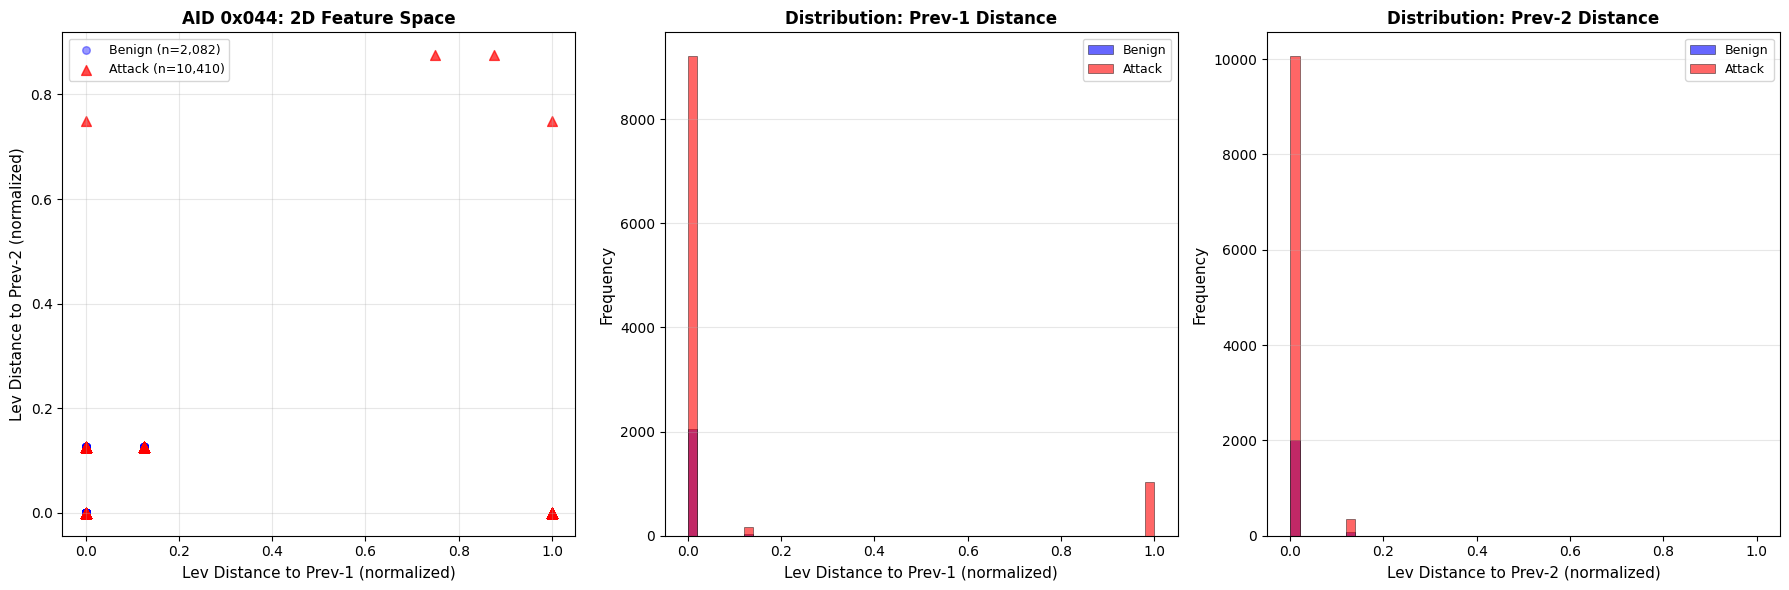


🎯 Step 2: Testing threshold values...
📊 Saved: artifacts/plots/with_thresholds_threshold_analysis_0x044.png


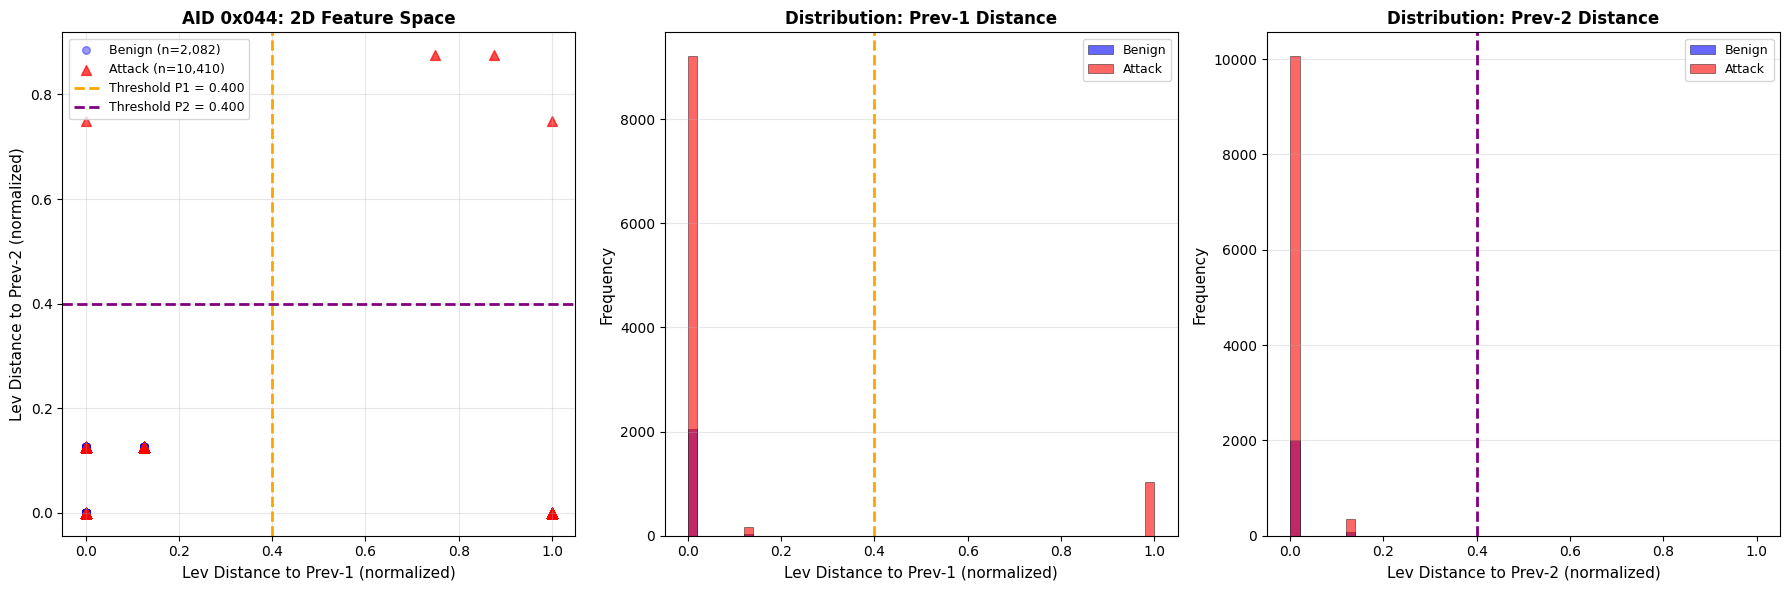


AID 0x044 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):    1030  (attacks detected)
   False Negatives (FN):   9380  (attacks missed)
   True Negatives (TN):    2082  (benign correctly classified)
   False Positives (FP):      0  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             24.91%
   Detection Rate (TPR):   9.89%  (How many attacks caught)
   False Alarm Rate:       0.00%  (How many benign flagged)
   Precision:            100.00%  (When flagged, how often correct)
   F1-Score:              18.01%


🔍 Analyzing AID 0x080 (128 decimal)

📊 Step 1: Visualizing data distribution (no thresholds)...
📊 Saved: artifacts/plots/initial_threshold_analysis_0x080.png


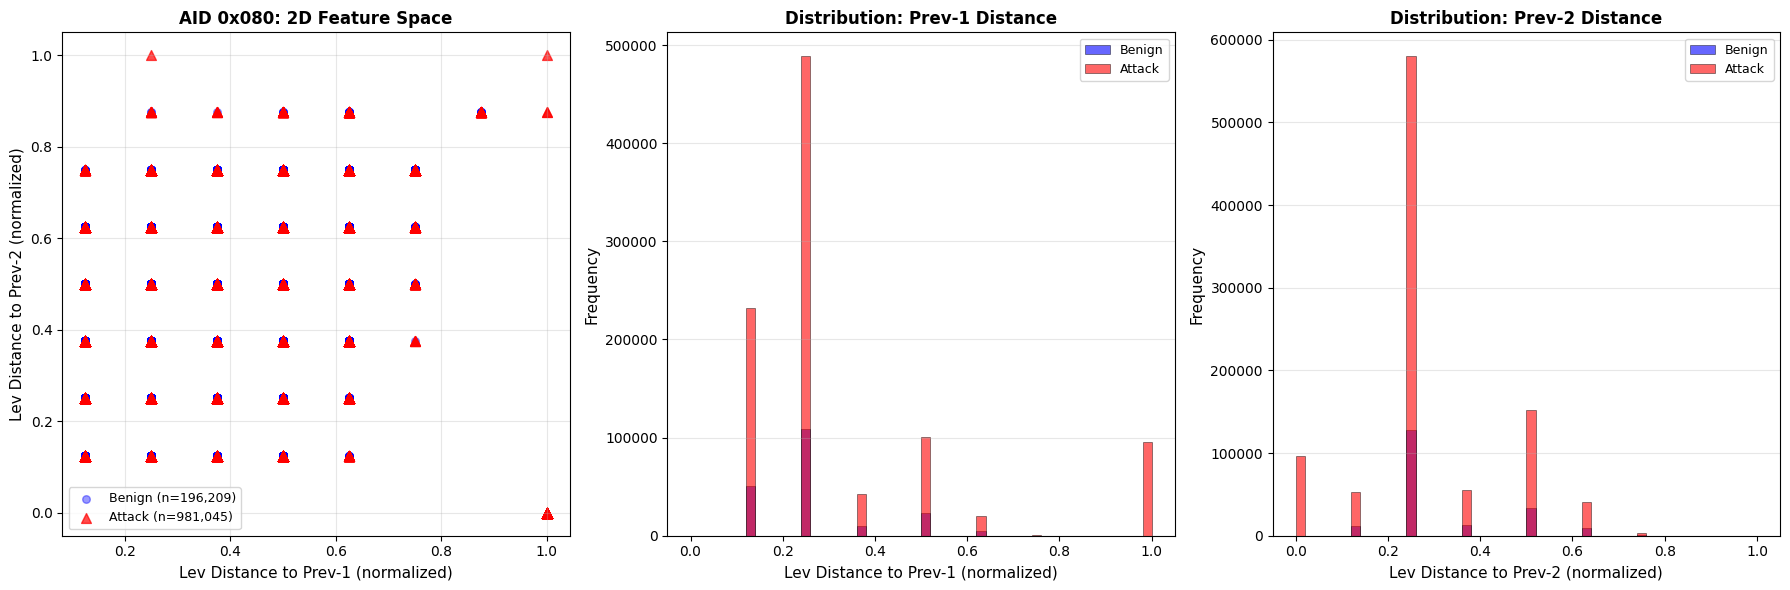


🎯 Step 2: Testing threshold values...
📊 Saved: artifacts/plots/with_thresholds_threshold_analysis_0x080.png


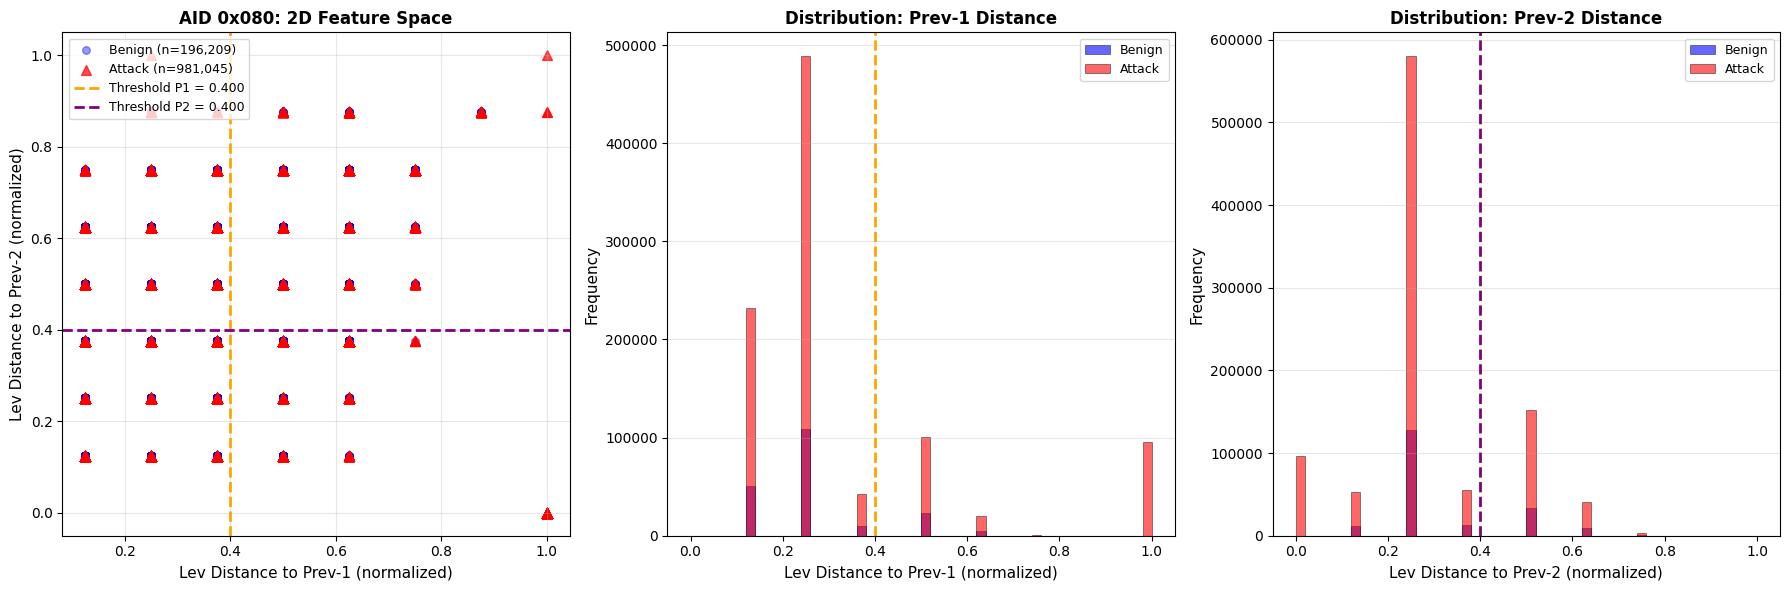


AID 0x080 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):  305926  (attacks detected)
   False Negatives (FN): 675119  (attacks missed)
   True Negatives (TN):  149099  (benign correctly classified)
   False Positives (FP):  47110  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             38.65%
   Detection Rate (TPR):  31.18%  (How many attacks caught)
   False Alarm Rate:      24.01%  (How many benign flagged)
   Precision:             86.66%  (When flagged, how often correct)
   F1-Score:              45.86%


🔍 Analyzing AID 0x220 (544 decimal)

📊 Step 1: Visualizing data distribution (no thresholds)...
📊 Saved: artifacts/plots/initial_threshold_analysis_0x220.png


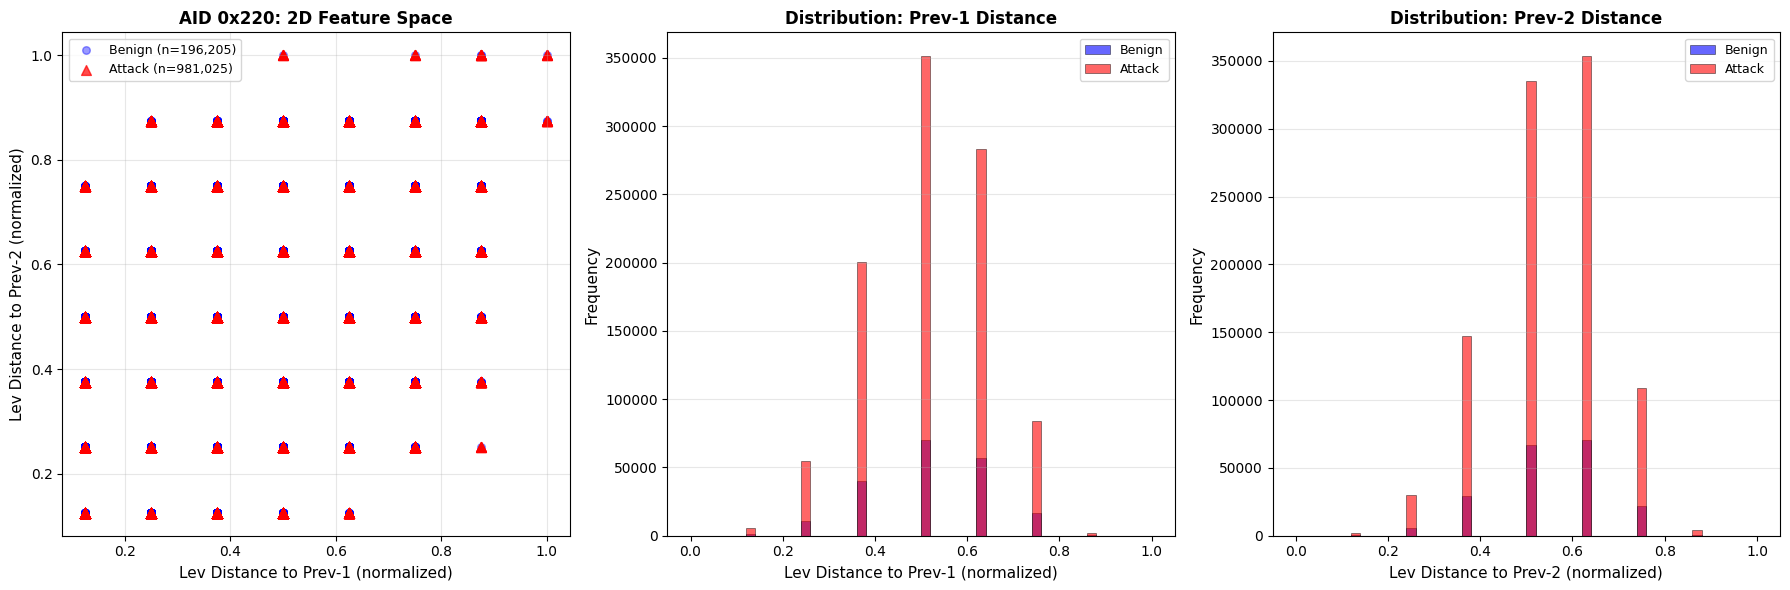


🎯 Step 2: Testing threshold values...
📊 Saved: artifacts/plots/with_thresholds_threshold_analysis_0x220.png


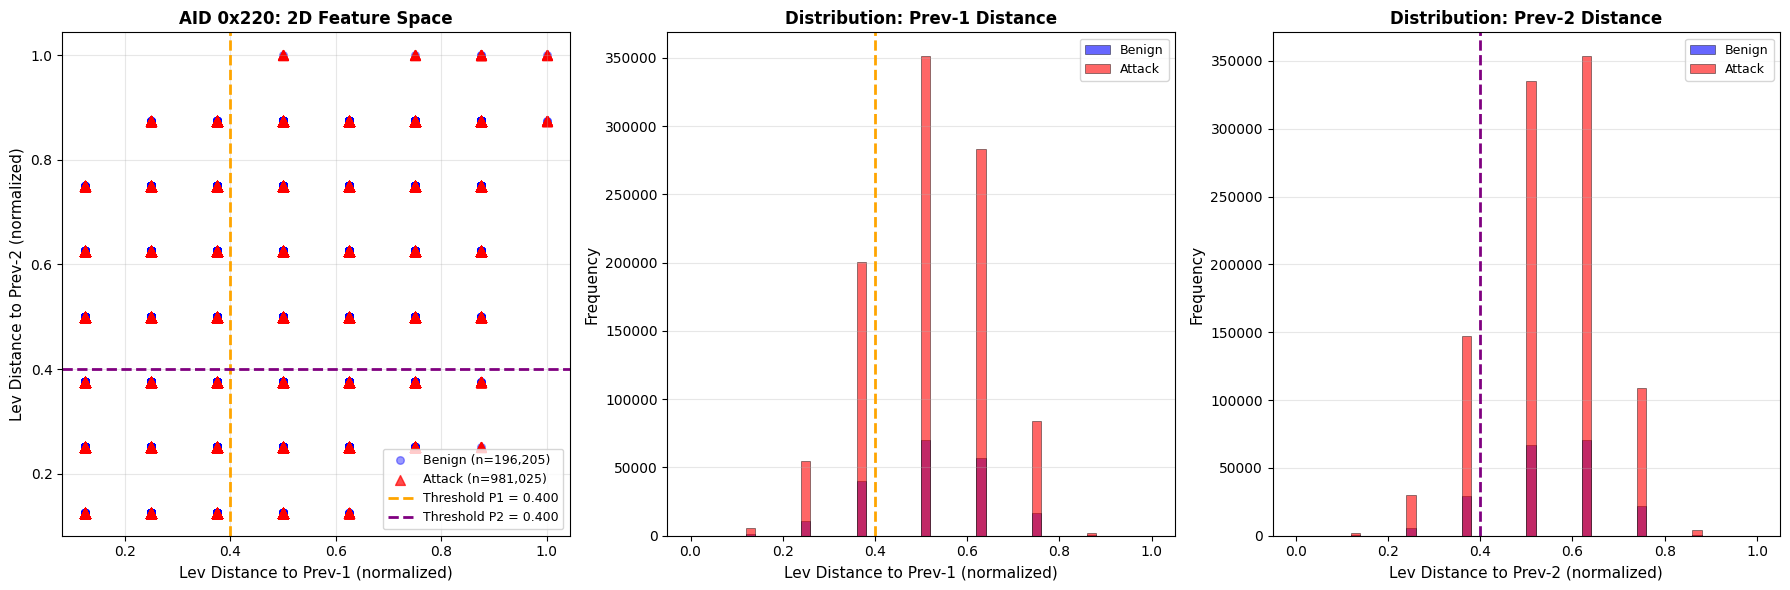


AID 0x220 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):  871635  (attacks detected)
   False Negatives (FN): 109390  (attacks missed)
   True Negatives (TN):   21878  (benign correctly classified)
   False Positives (FP): 174327  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             75.90%
   Detection Rate (TPR):  88.85%  (How many attacks caught)
   False Alarm Rate:      88.85%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:              86.00%


📋 SUMMARY: Threshold Performance Across AIDs
aid_hex     TP     FN     FP     TN   recall      fpr  precision       f1
  0x044   1030   9380      0   2082 0.098943 0.000000   1.000000 0.180070
  0x080 305926 675119  47110 149099 0.311837 0.240101   0.866558 0.458632
  0x220 871635 109390 174327  21878 0.888494 0.888494   0.833333 0.860030

✅ Summary saved to: artifacts/threshold_performance_summary.csv
📨 Sent: ✅ DONE: Cell 7: A

In [ ]:
"""with notify_wrap("Cell 7: Analysis of specific AIDs"):
    # ============================================================================
    # ANALYZE SPECIFIC ARBITRATION IDs
    # ============================================================================

    # Example: Analyze AID 0x044 (68 decimal)
    # This is one of the masqueraded IDs in your dataset

    target_aids = [
        0x044,  # 68 decimal
        0x080,  # 128 decimal
        0x220,  # 544 decimal
        # Add more as needed
    ]

    results = []

    for aid in target_aids:
        print("\n" + "="*70)
        print(f"🔍 Analyzing AID 0x{aid:03X} ({aid} decimal)")
        print("="*70)
        
        # Step 1: Plot WITHOUT thresholds to see the data distribution
        print("\n📊 Step 1: Visualizing data distribution (no thresholds)...")
        plot_threshold_analysis(
            benign_csv="artifacts/benign_lev.csv",
            attack_csv="artifacts/attack_lev.csv",
            aid=aid,
            save_prefix="artifacts/plots/initial"
        )
        
        # Step 2: After seeing the plot, set thresholds manually
        # YOU ADJUST THESE VALUES based on the plots above!
        print("\n🎯 Step 2: Testing threshold values...")
        
        # Example thresholds - YOU NEED TO TUNE THESE!
        # Look at the histograms and 2D scatter to decide where to cut
        result = plot_threshold_analysis(
            benign_csv="artifacts/benign_lev.csv",
            attack_csv="artifacts/attack_lev.csv",
            aid=aid,
            threshold_p1=0.40,      # ← ADJUST THIS based on histogram
            threshold_p2=0.40,      # ← ADJUST THIS based on histogram
            threshold_combined=None,  # Optional: (-1, 0.8) for diagonal
            save_prefix="artifacts/plots/with_thresholds"
        )
        
        if result:
            results.append(result)

    # ============================================================================
    # SUMMARY TABLE
    # ============================================================================
    if results:
        print("\n" + "="*70)
        print("📋 SUMMARY: Threshold Performance Across AIDs")
        print("="*70)
        
        summary_df = pd.DataFrame(results)
        summary_df['aid_hex'] = summary_df['aid'].apply(lambda x: f"0x{x:03X}")
        
        display_cols = ['aid_hex', 'TP', 'FN', 'FP', 'TN', 'recall', 'fpr', 'precision', 'f1']
        print(summary_df[display_cols].to_string(index=False))
        
        # Save summary
        summary_df.to_csv("artifacts/threshold_performance_summary.csv", index=False)
        print(f"\n✅ Summary saved to: artifacts/threshold_performance_summary.csv")"""

In [ ]:
notify_cell("✅ analysis of the 3 specific arbitration IDs is done")

📨 Sent: ✅ analysis of the 3 specific arbitration IDs is done


True


🔍 Threshold Search for AID 0x044
Data: 2,082 benign, 10,410 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.128
   Threshold P2: 0.128

   Performance:
   - Detection Rate: 9.9%
   - False Alarms:   0.00%
   - Precision:      100.0%
   - F1-Score:       18.0%
   - TP=1030, FP=0, TN=2082, FN=9380

📊 Top 5 Alternative Configurations:
    t_p1     t_p2   recall  fpr      f1
0.900000 0.734483 0.098943  0.0 0.18007
0.127586 0.127586 0.098943  0.0 0.18007
0.127586 0.155172 0.098943  0.0 0.18007
0.900000 0.293103 0.098943  0.0 0.18007
0.900000 0.265517 0.098943  0.0 0.18007
📊 Saved: artifacts/plots/optimized_threshold_analysis_0x044.png


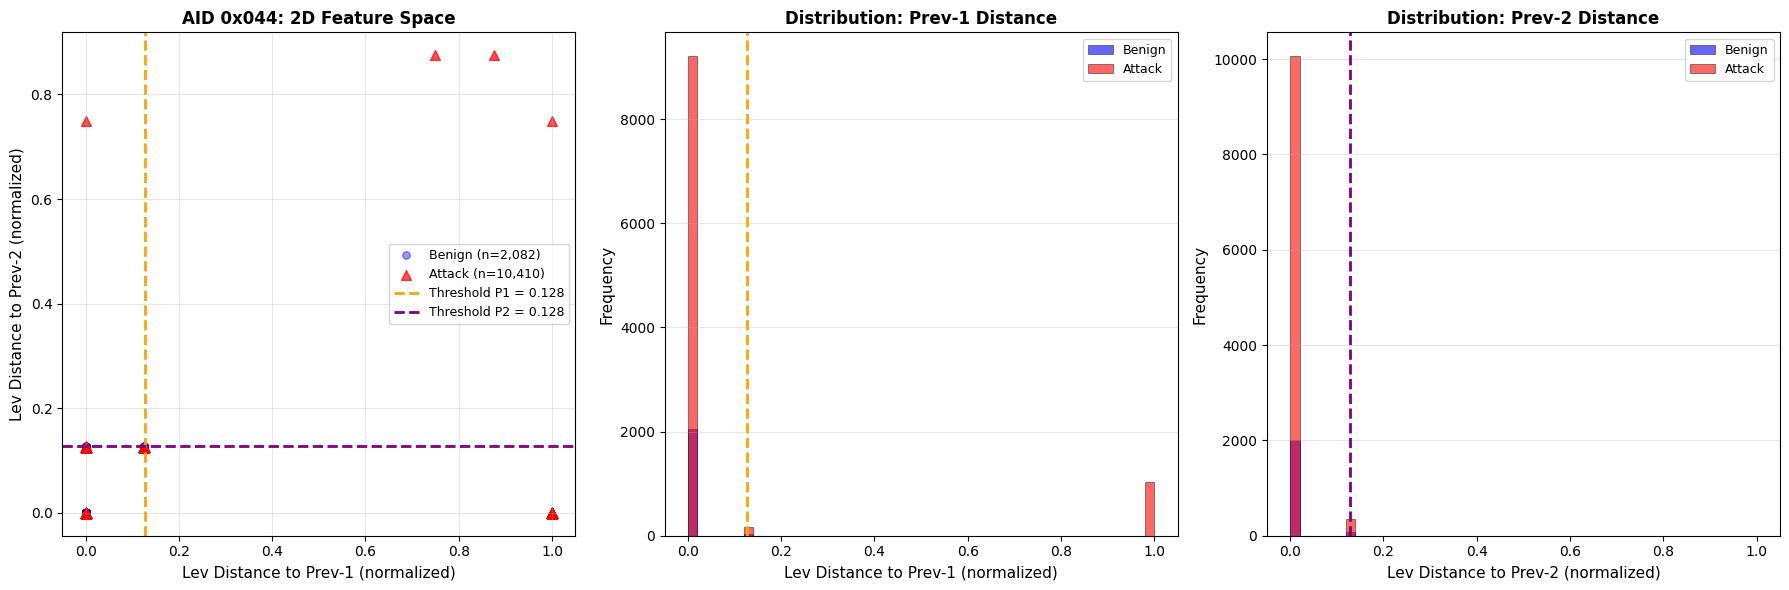


AID 0x044 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):    1030  (attacks detected)
   False Negatives (FN):   9380  (attacks missed)
   True Negatives (TN):    2082  (benign correctly classified)
   False Positives (FP):      0  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             24.91%
   Detection Rate (TPR):   9.89%  (How many attacks caught)
   False Alarm Rate:       0.00%  (How many benign flagged)
   Precision:            100.00%  (When flagged, how often correct)
   F1-Score:              18.01%

📨 Sent: ✅ DONE: Cell 8: threshold suggestion function
Duration: 1.2 min


In [ ]:
"""with notify_wrap("Cell 8: threshold suggestion function"):
    # ============================================================================
    # FUNCTION TO SUGGEST THRESHOLDS BASED ON STATISTICS
    # ============================================================================
    def suggest_thresholds(benign_csv, attack_csv, aid, 
                        target_fpr=0.01, metric='f1'):
        """
        Suggest threshold values by grid search (still NO ML, just statistics).
        
        Args:
            benign_csv: Path to benign data
            attack_csv: Path to attack data
            aid: Arbitration ID
            target_fpr: Maximum acceptable false positive rate (default 1%)
            metric: Optimization metric ('f1', 'recall', 'precision')
        
        Returns:
            Dictionary with suggested thresholds and their performance
        """
        benign = pd.read_csv(benign_csv)
        attack = pd.read_csv(attack_csv)
        
        b_data = benign[benign['arbitration_id'] == aid][['lev_norm_p1', 'lev_norm_p2']].dropna()
        a_data = attack[attack['arbitration_id'] == aid][['lev_norm_p1', 'lev_norm_p2']].dropna()
        
        if len(b_data) < 10 or len(a_data) < 10:
            print(f"⚠️  Insufficient data for AID 0x{aid:03X}")
            return None
        
        print(f"\n{'='*70}")
        print(f"🔍 Threshold Search for AID 0x{aid:03X}")
        print(f"{'='*70}")
        print(f"Data: {len(b_data):,} benign, {len(a_data):,} attack samples")
        print(f"Target: max FPR = {target_fpr*100:.1f}%, optimize {metric.upper()}")
        
        # Grid search over threshold values
        threshold_range = np.linspace(0.1, 0.9, 30)
        best_score = -1
        best_config = None
        candidates = []
        
        print("\n🔄 Searching threshold space...")
        
        for t_p1 in threshold_range:
            for t_p2 in threshold_range:
                # Apply thresholds
                b_pred = (b_data['lev_norm_p1'] > t_p1) | (b_data['lev_norm_p2'] > t_p2)
                a_pred = (a_data['lev_norm_p1'] > t_p1) | (a_data['lev_norm_p2'] > t_p2)
                
                TP = a_pred.sum()
                FP = b_pred.sum()
                TN = len(b_data) - FP
                FN = len(a_data) - TP
                
                fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
                
                # Only consider configs that meet FPR constraint
                if fpr > target_fpr:
                    continue
                
                recall = TP / (TP + FN) if (TP + FN) > 0 else 0
                precision = TP / (TP + FP) if (TP + FP) > 0 else 0
                f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
                
                score = {'f1': f1, 'recall': recall, 'precision': precision}[metric]
                
                candidates.append({
                    't_p1': t_p1, 't_p2': t_p2,
                    'recall': recall, 'precision': precision, 'f1': f1, 'fpr': fpr,
                    'TP': int(TP), 'FP': int(FP), 'TN': int(TN), 'FN': int(FN)
                })
                
                if score > best_score:
                    best_score = score
                    best_config = candidates[-1].copy()
        
        if best_config is None:
            print(f"❌ No configuration found meeting FPR ≤ {target_fpr*100:.1f}%")
            print("   Try increasing target_fpr or checking your data distribution")
            return None
        
        print(f"\n✅ Best configuration found:")
        print(f"   Threshold P1: {best_config['t_p1']:.3f}")
        print(f"   Threshold P2: {best_config['t_p2']:.3f}")
        print(f"\n   Performance:")
        print(f"   - Detection Rate: {best_config['recall']*100:.1f}%")
        print(f"   - False Alarms:   {best_config['fpr']*100:.2f}%")
        print(f"   - Precision:      {best_config['precision']*100:.1f}%")
        print(f"   - F1-Score:       {best_config['f1']*100:.1f}%")
        print(f"   - TP={best_config['TP']}, FP={best_config['FP']}, "
            f"TN={best_config['TN']}, FN={best_config['FN']}")
        
        # Show top 5 alternatives
        print(f"\n📊 Top 5 Alternative Configurations:")
        cand_df = pd.DataFrame(candidates).sort_values(metric, ascending=False).head(5)
        print(cand_df[['t_p1', 't_p2', 'recall', 'fpr', 'f1']].to_string(index=False))
        
        return best_config


    # ============================================================================
    # EXAMPLE USAGE: Find thresholds for specific AIDs
    # ============================================================================

    # Find optimal thresholds for AID 0x044
    config_044 = suggest_thresholds(
        benign_csv="artifacts/benign_lev.csv",
        attack_csv="artifacts/attack_lev.csv",
        aid=0x044,
        target_fpr=0.01,  # Accept max 1% false alarms
        metric='f1'       # Optimize F1-score
    )

    if config_044:
        # Visualize with suggested thresholds
        plot_threshold_analysis(
            benign_csv="artifacts/benign_lev.csv",
            attack_csv="artifacts/attack_lev.csv",
            aid=0x044,
            threshold_p1=config_044['t_p1'],
            threshold_p2=config_044['t_p2'],
            save_prefix="artifacts/plots/optimized"
        )"""

In [ ]:
notify_cell("✅ threshold suggestion function is done")

📨 Sent: ✅ threshold suggestion function is done


True

🚀 BATCH ANALYSIS: Processing 35 Masqueraded AIDs

──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x044 (masq-044h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x044
Data: 2,082 benign, 10,410 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.128
   Threshold P2: 0.128

   Performance:
   - Detection Rate: 9.9%
   - False Alarms:   0.00%
   - Precision:      100.0%
   - F1-Score:       18.0%
   - TP=1030, FP=0, TN=2082, FN=9380

📊 Top 5 Alternative Configurations:
    t_p1     t_p2   recall  fpr      f1
0.900000 0.734483 0.098943  0.0 0.18007
0.127586 0.127586 0.098943  0.0 0.18007
0.127586 0.155172 0.098943  0.0 0.18007
0.900000 0.293103 0.098943  0.0 0.18007
0.900000 0.265517 0.098943  0.0 0.18007
📊 Saved: artifacts/batch_results/aid_044h_threshold_analysis_0x044.png


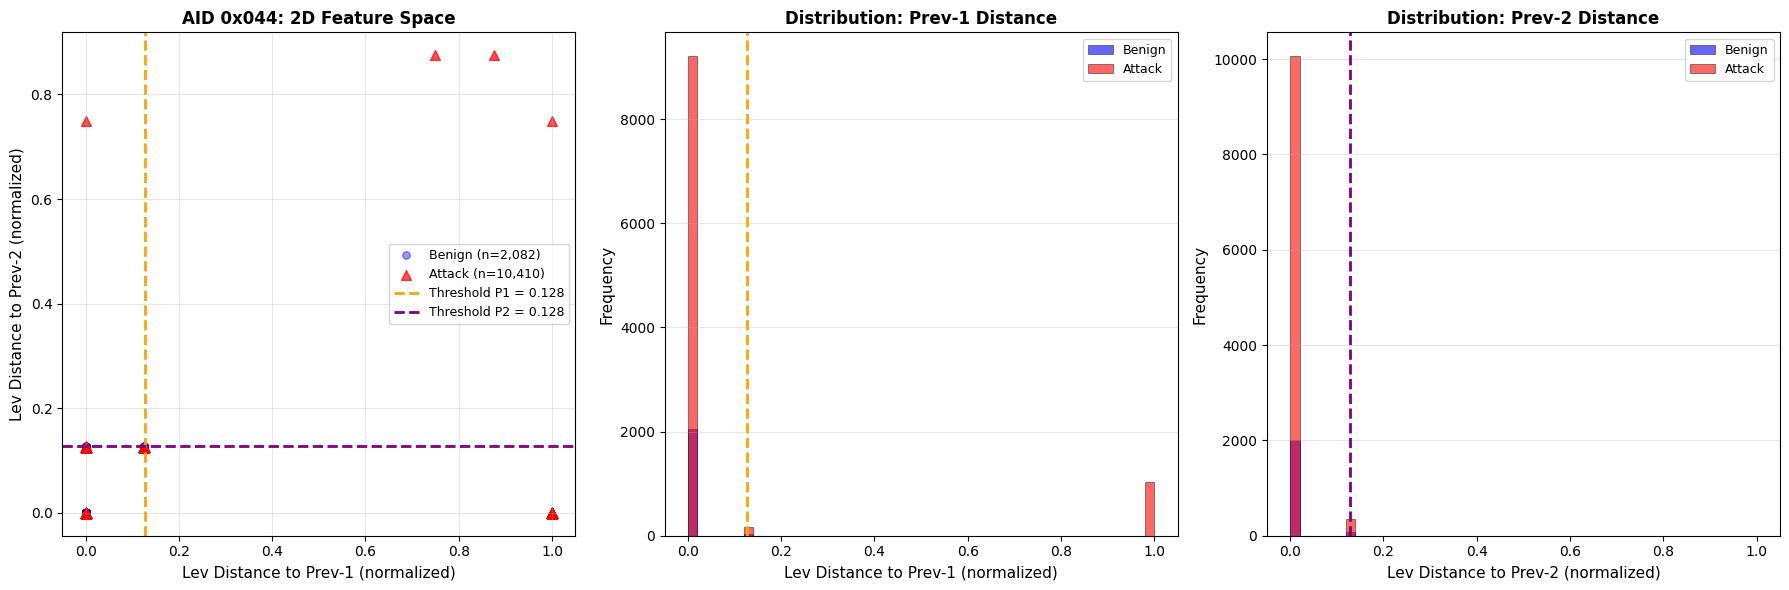


AID 0x044 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):    1030  (attacks detected)
   False Negatives (FN):   9380  (attacks missed)
   True Negatives (TN):    2082  (benign correctly classified)
   False Positives (FP):      0  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             24.91%
   Detection Rate (TPR):   9.89%  (How many attacks caught)
   False Alarm Rate:       0.00%  (How many benign flagged)
   Precision:            100.00%  (When flagged, how often correct)
   F1-Score:              18.01%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x080 (masq-080h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x080
Data: 196,209 benign, 981,045 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.652
   Threshold P2: 0.652

   Performance:
   - Detection 

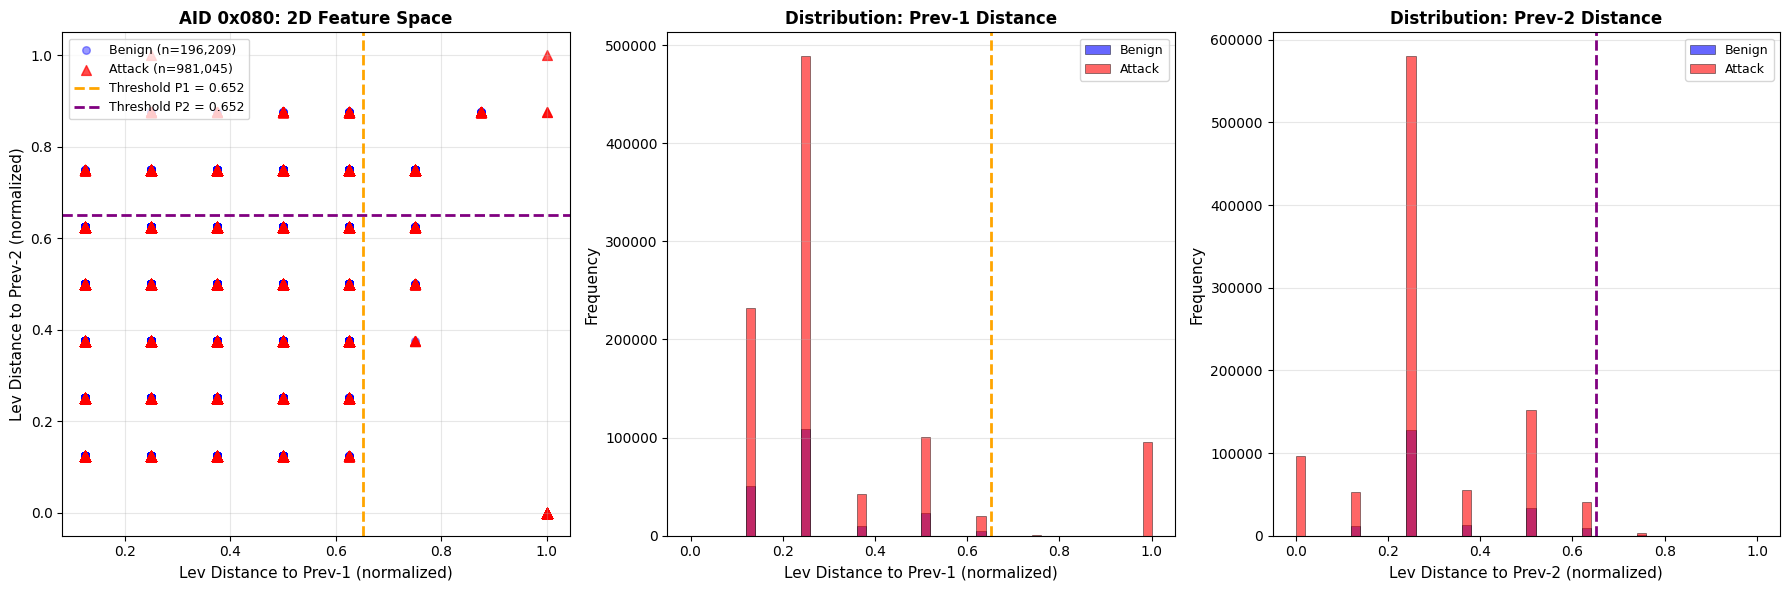


AID 0x080 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):   99413  (attacks detected)
   False Negatives (FN): 881632  (attacks missed)
   True Negatives (TN):  195454  (benign correctly classified)
   False Positives (FP):    755  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             25.05%
   Detection Rate (TPR):  10.13%  (How many attacks caught)
   False Alarm Rate:       0.38%  (How many benign flagged)
   Precision:             99.25%  (When flagged, how often correct)
   F1-Score:              18.39%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x081 (masq-081h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x081
Data: 196,209 benign, 981,045 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.128
   Threshold P2: 0.128

   Performance:
   - Detection 

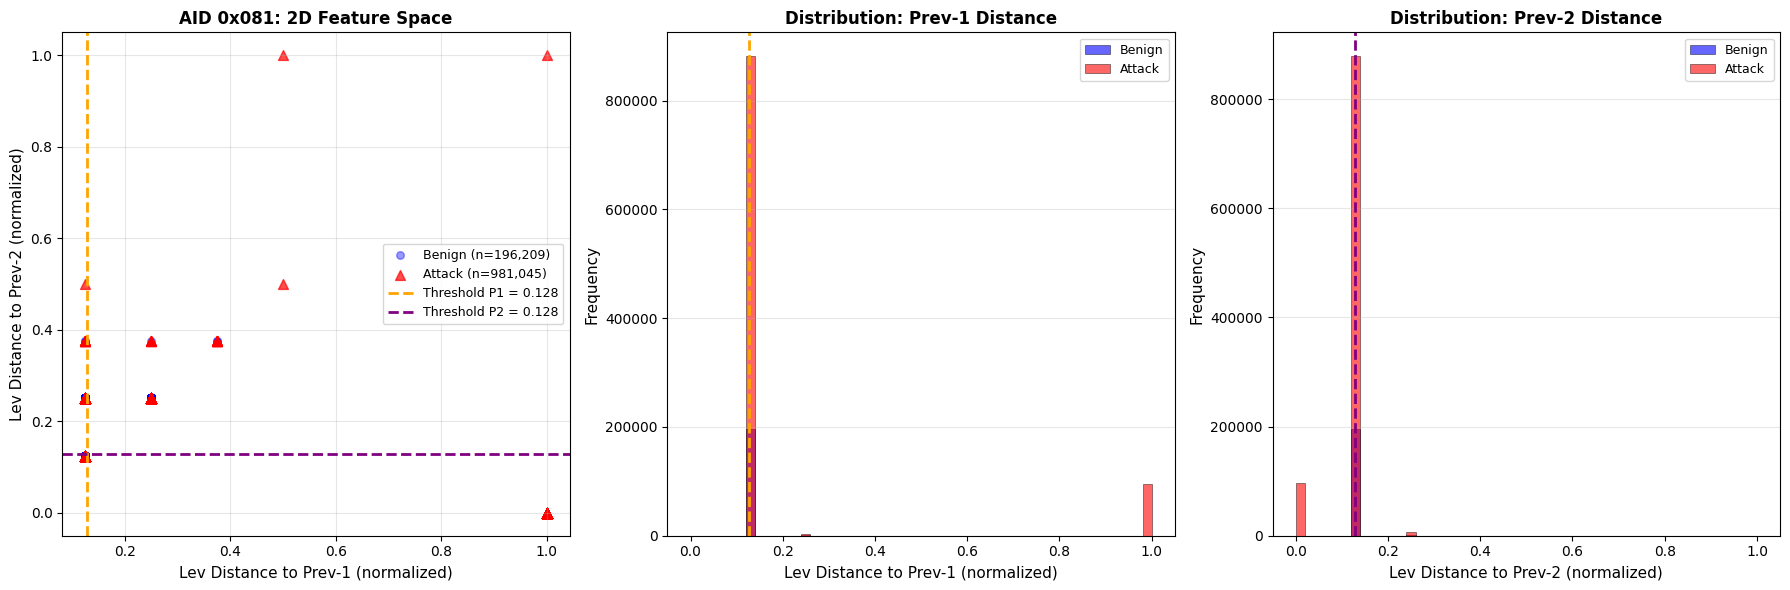


AID 0x081 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):  102616  (attacks detected)
   False Negatives (FN): 878429  (attacks missed)
   True Negatives (TN):  194713  (benign correctly classified)
   False Positives (FP):   1496  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             25.26%
   Detection Rate (TPR):  10.46%  (How many attacks caught)
   False Alarm Rate:       0.76%  (How many benign flagged)
   Precision:             98.56%  (When flagged, how often correct)
   F1-Score:              18.91%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x111 (masq-111h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x111
Data: 196,185 benign, 980,925 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.128
   Threshold P2: 0.266

   Performance:
   - Detection 

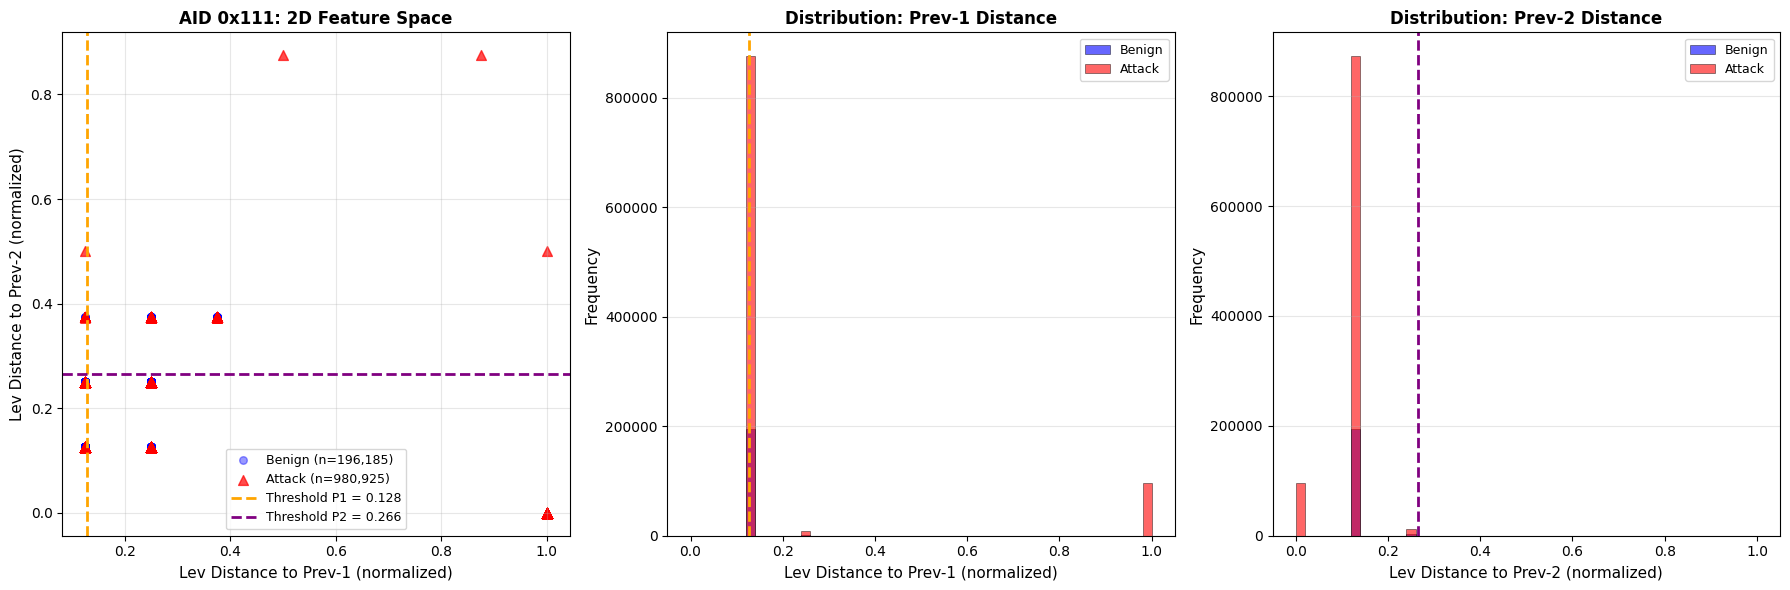


AID 0x111 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):  104904  (attacks detected)
   False Negatives (FN): 876021  (attacks missed)
   True Negatives (TN):  194236  (benign correctly classified)
   False Positives (FP):   1949  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             25.41%
   Detection Rate (TPR):  10.69%  (How many attacks caught)
   False Alarm Rate:       0.99%  (How many benign flagged)
   Precision:             98.18%  (When flagged, how often correct)
   F1-Score:              19.29%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x112 (masq-112h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x112
Data: 196,185 benign, 980,925 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.376
   Threshold P2: 0.376

   Performance:
   - Detection 

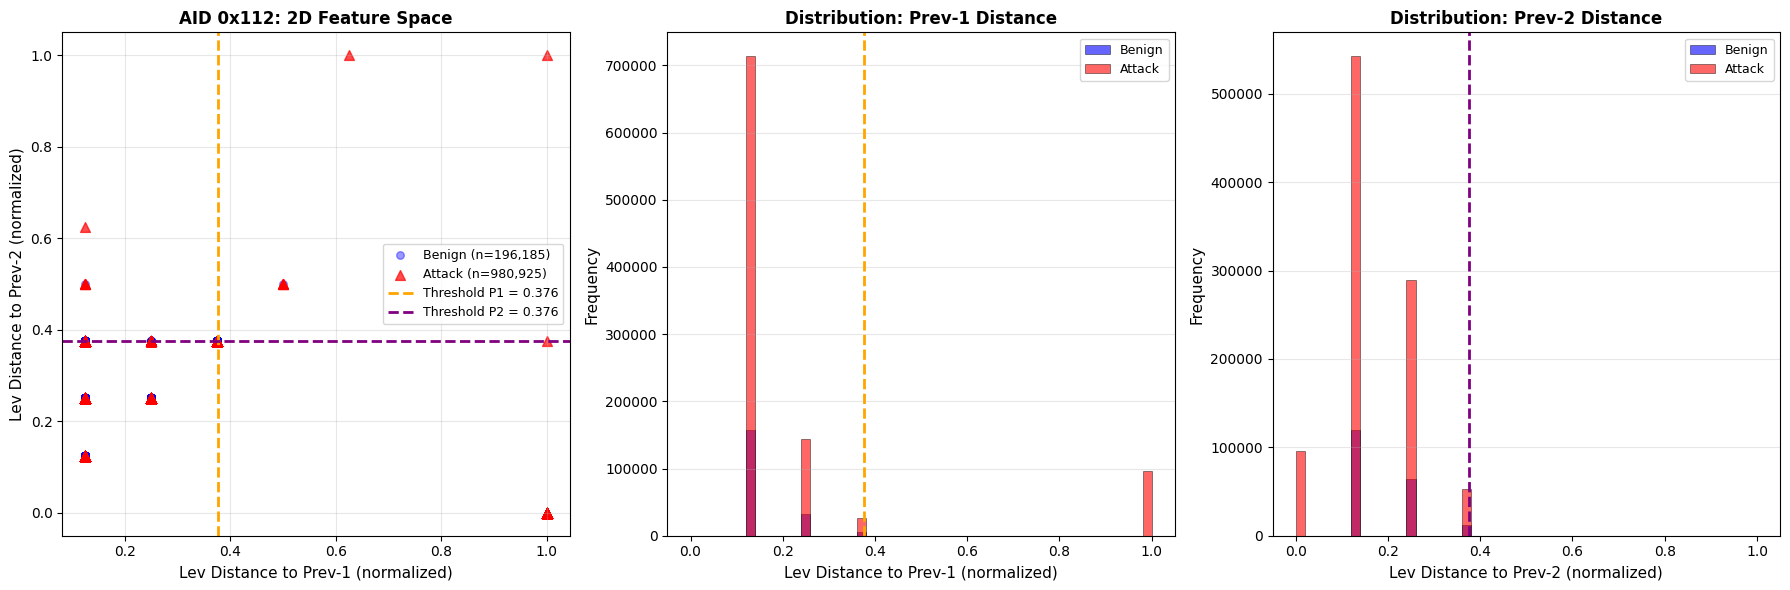


AID 0x112 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):   96008  (attacks detected)
   False Negatives (FN): 884917  (attacks missed)
   True Negatives (TN):  196183  (benign correctly classified)
   False Positives (FP):      2  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             24.82%
   Detection Rate (TPR):   9.79%  (How many attacks caught)
   False Alarm Rate:       0.00%  (How many benign flagged)
   Precision:            100.00%  (When flagged, how often correct)
   F1-Score:              17.83%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x113 (masq-113h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x113
Data: 196,185 benign, 980,925 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.128
   Threshold P2: 0.266

   Performance:
   - Detection 

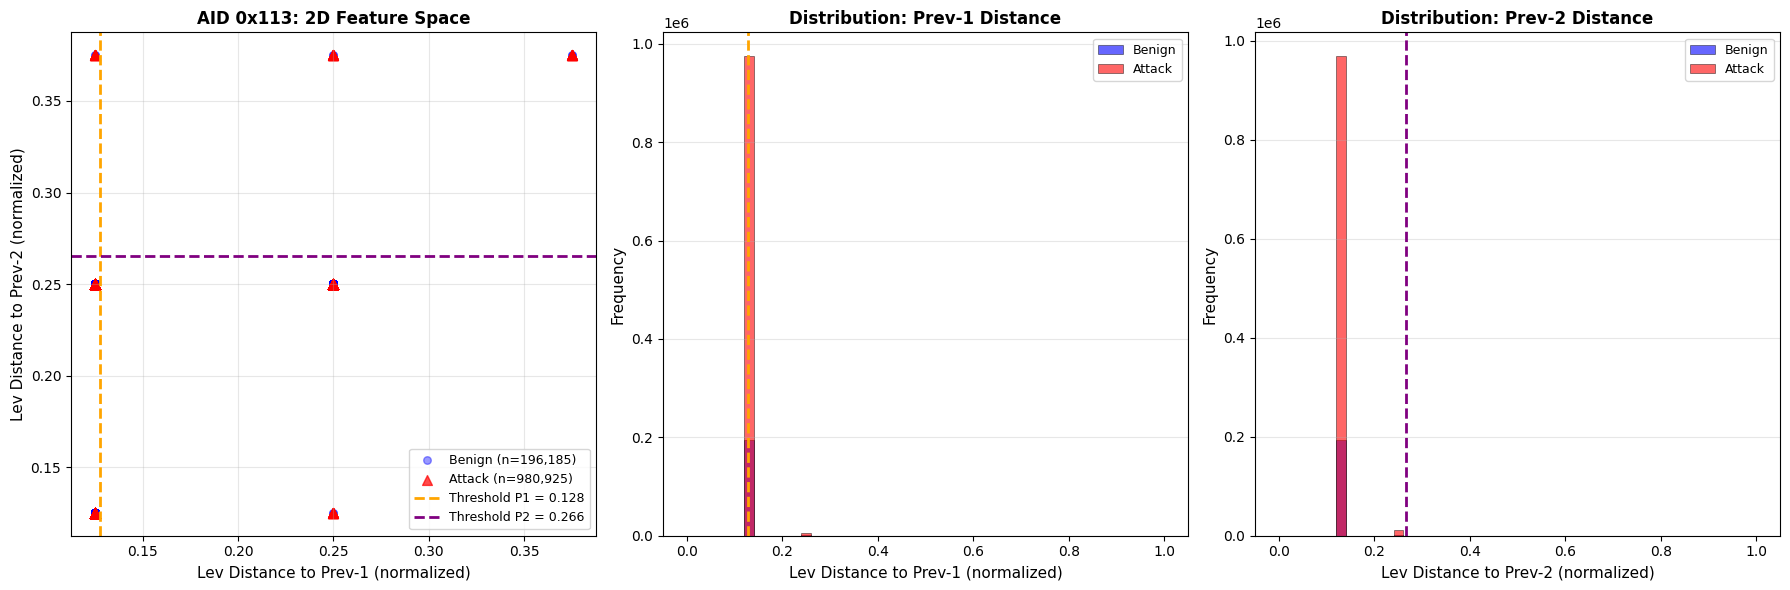


AID 0x113 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):    6150  (attacks detected)
   False Negatives (FN): 974775  (attacks missed)
   True Negatives (TN):  194955  (benign correctly classified)
   False Positives (FP):   1230  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             17.08%
   Detection Rate (TPR):   0.63%  (How many attacks caught)
   False Alarm Rate:       0.63%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               1.24%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x162 (masq-162h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x162
Data: 196,185 benign, 980,925 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.679
   Threshold P2: 0.679

   Performance:
   - Detection 

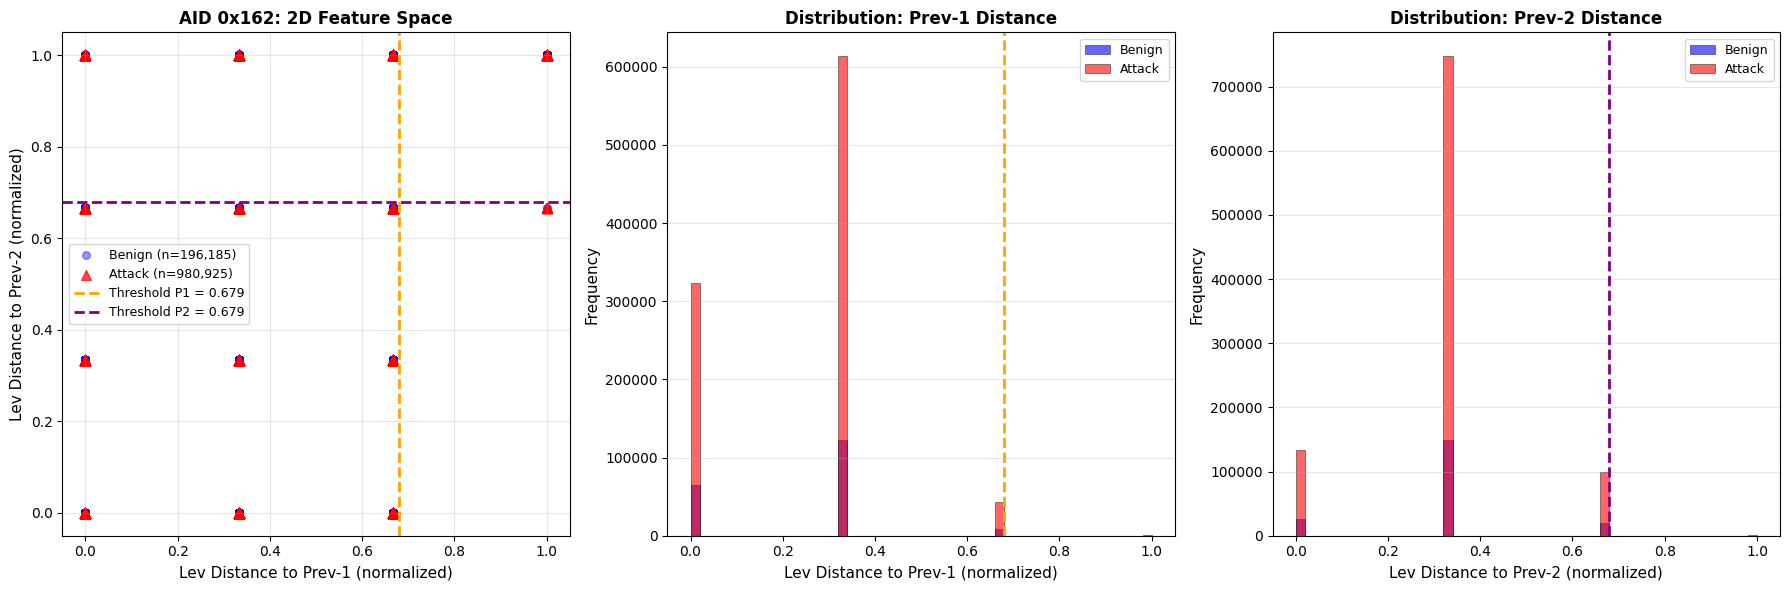


AID 0x162 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):    1415  (attacks detected)
   False Negatives (FN): 979510  (attacks missed)
   True Negatives (TN):  195902  (benign correctly classified)
   False Positives (FP):    283  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.76%
   Detection Rate (TPR):   0.14%  (How many attacks caught)
   False Alarm Rate:       0.14%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               0.29%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x18F (masq-18Fh)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x18F
Data: 196,209 benign, 981,045 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.128
   Threshold P2: 0.128

   Performance:
   - Detection 

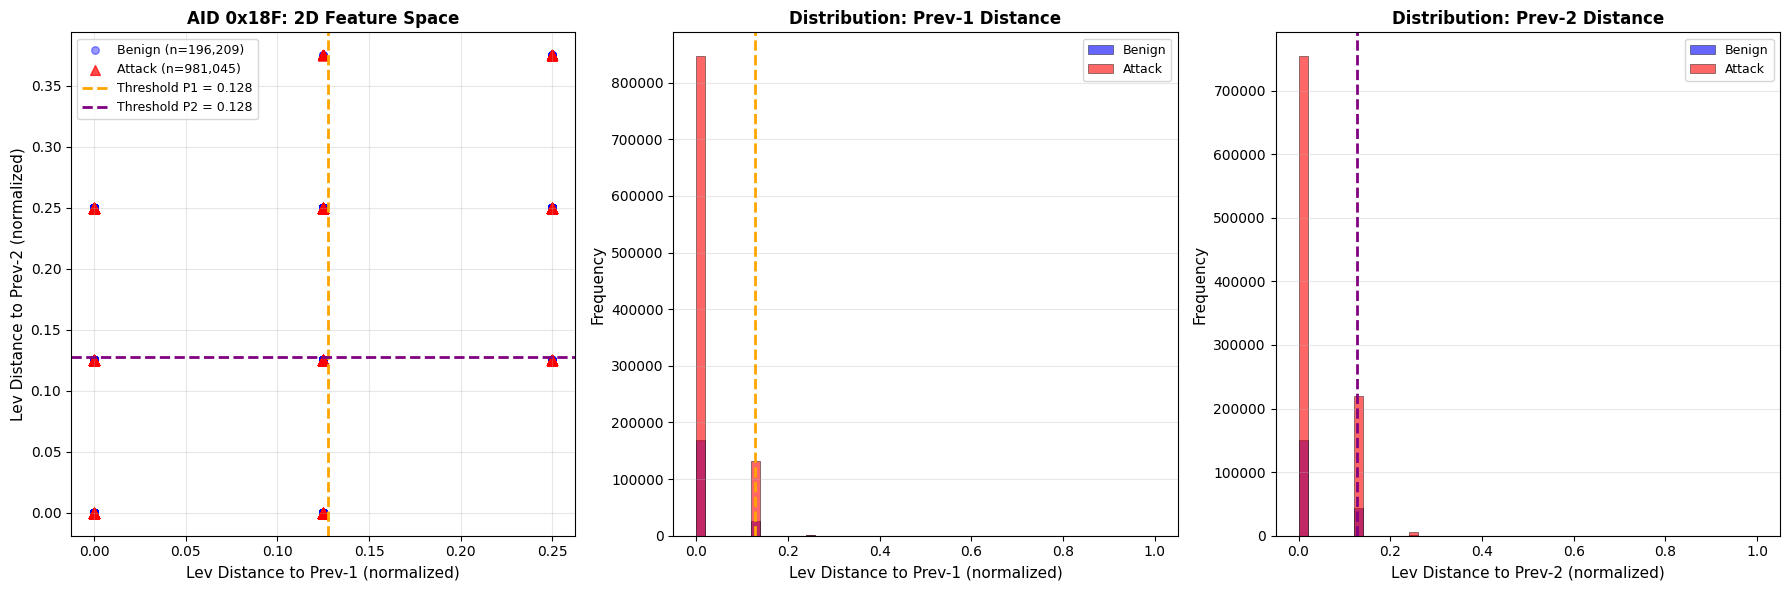


AID 0x18F - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):    6635  (attacks detected)
   False Negatives (FN): 974410  (attacks missed)
   True Negatives (TN):  194882  (benign correctly classified)
   False Positives (FP):   1327  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             17.12%
   Detection Rate (TPR):   0.68%  (How many attacks caught)
   False Alarm Rate:       0.68%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               1.34%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x200 (masq-200h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x200
Data: 196,209 benign, 981,045 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.183
   Threshold P2: 0.183

   Performance:
   - Detection 

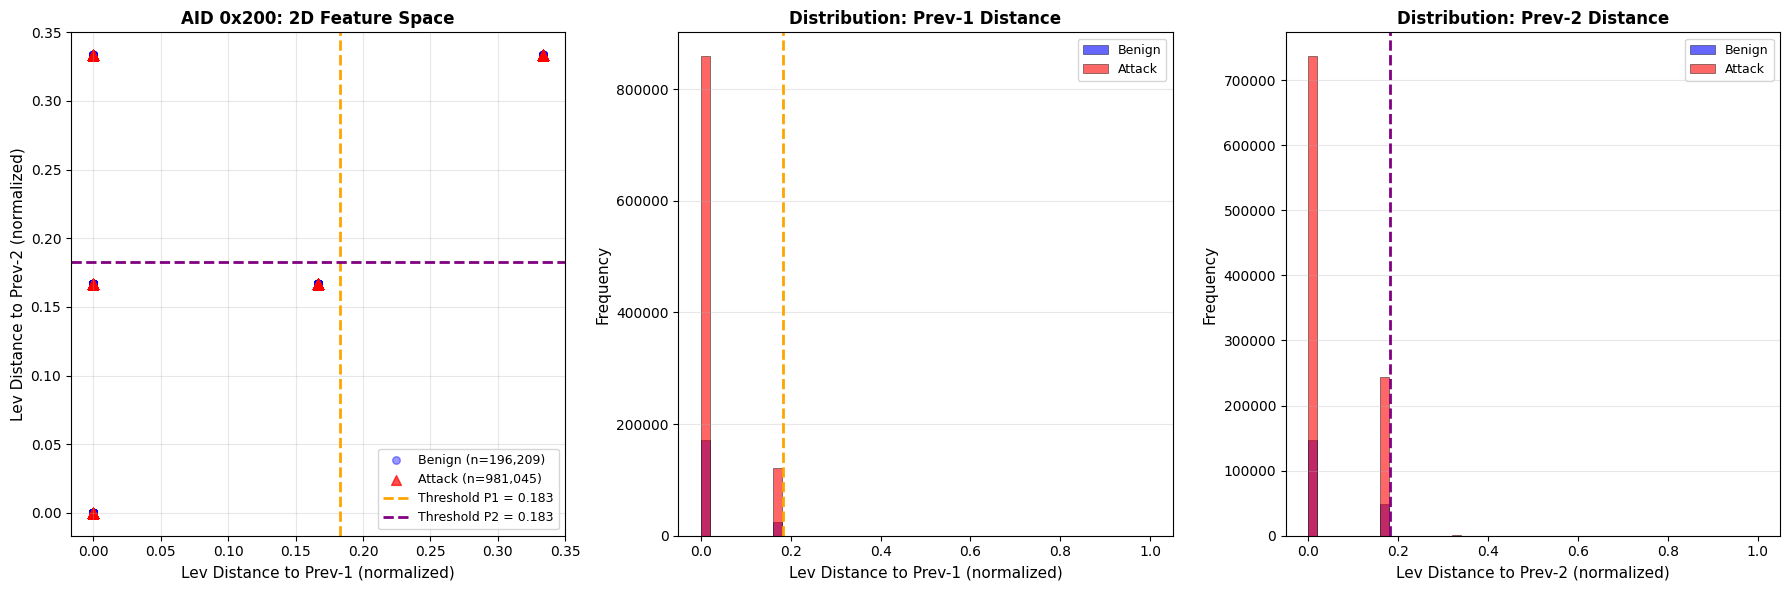


AID 0x200 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):     400  (attacks detected)
   False Negatives (FN): 980645  (attacks missed)
   True Negatives (TN):  196129  (benign correctly classified)
   False Positives (FP):     80  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.69%
   Detection Rate (TPR):   0.04%  (How many attacks caught)
   False Alarm Rate:       0.04%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               0.08%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x220 (masq-220h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x220
Data: 196,205 benign, 981,025 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.762
   Threshold P2: 0.762

   Performance:
   - Detection 

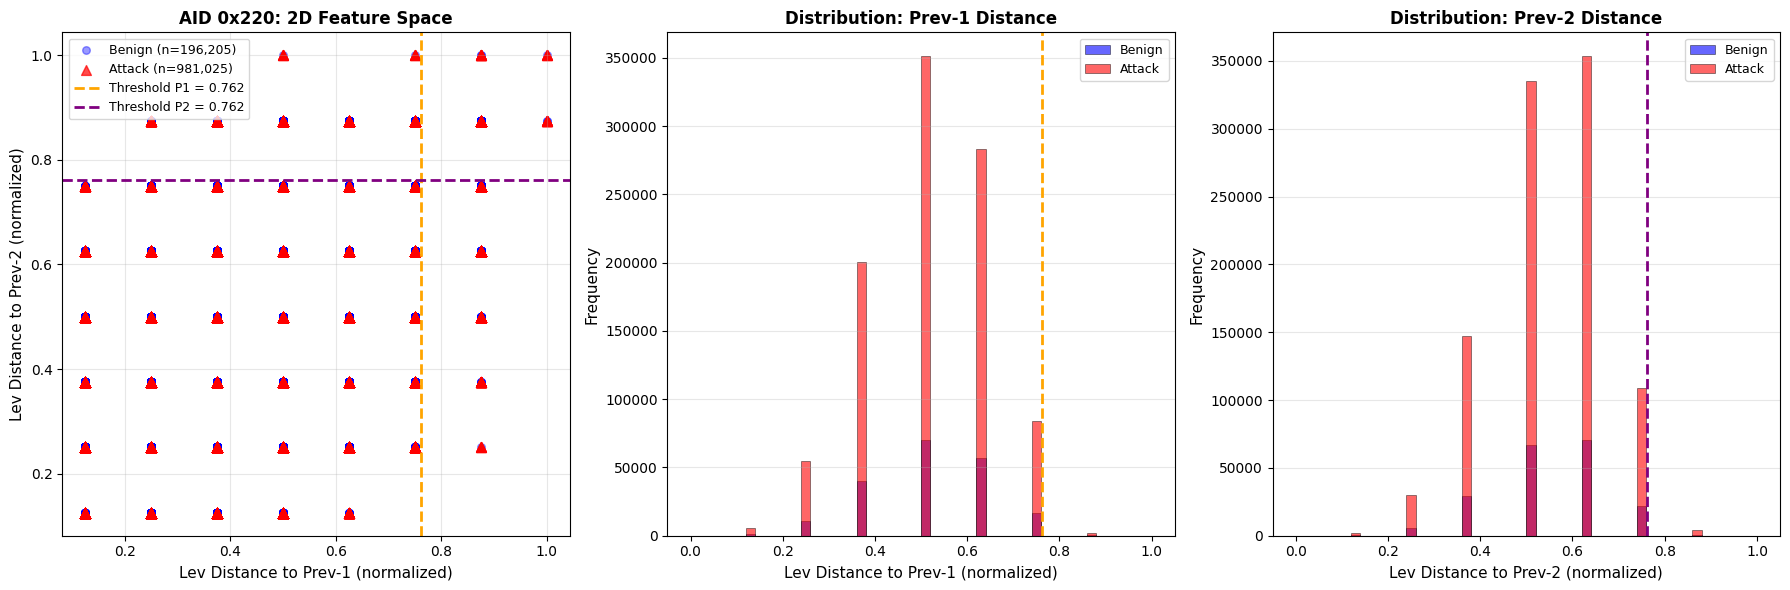


AID 0x220 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):    5725  (attacks detected)
   False Negatives (FN): 975300  (attacks missed)
   True Negatives (TN):  195060  (benign correctly classified)
   False Positives (FP):   1145  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             17.06%
   Detection Rate (TPR):   0.58%  (How many attacks caught)
   False Alarm Rate:       0.58%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               1.16%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x251 (masq-251h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x251
Data: 196,178 benign, 980,890 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.652
   Threshold P2: 0.652

   Performance:
   - Detection 

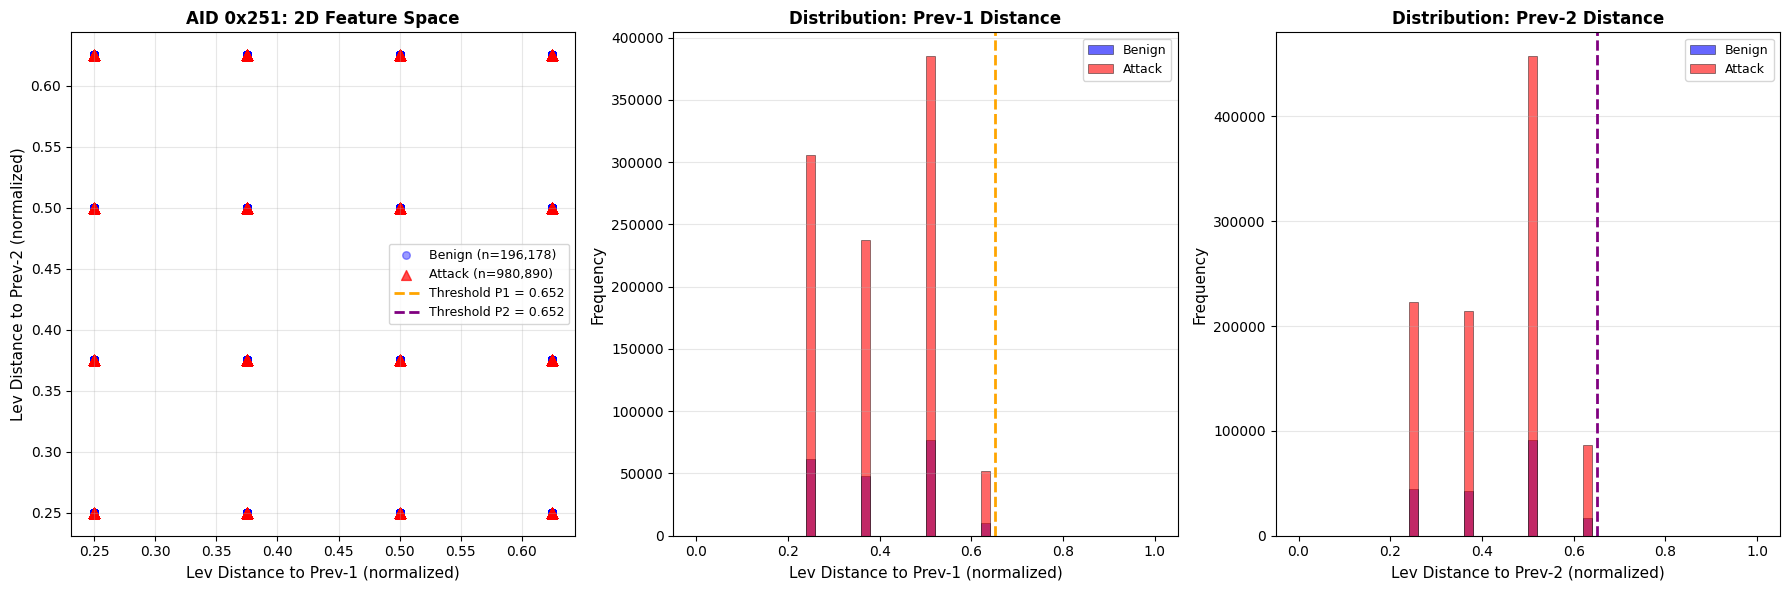


AID 0x251 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):       0  (attacks detected)
   False Negatives (FN): 980890  (attacks missed)
   True Negatives (TN):  196178  (benign correctly classified)
   False Positives (FP):      0  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.67%
   Detection Rate (TPR):   0.00%  (How many attacks caught)
   False Alarm Rate:       0.00%  (How many benign flagged)
   Precision:              0.00%  (When flagged, how often correct)
   F1-Score:               0.00%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x260 (masq-260h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x260
Data: 196,209 benign, 981,045 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.514
   Threshold P2: 0.514

   Performance:
   - Detection 

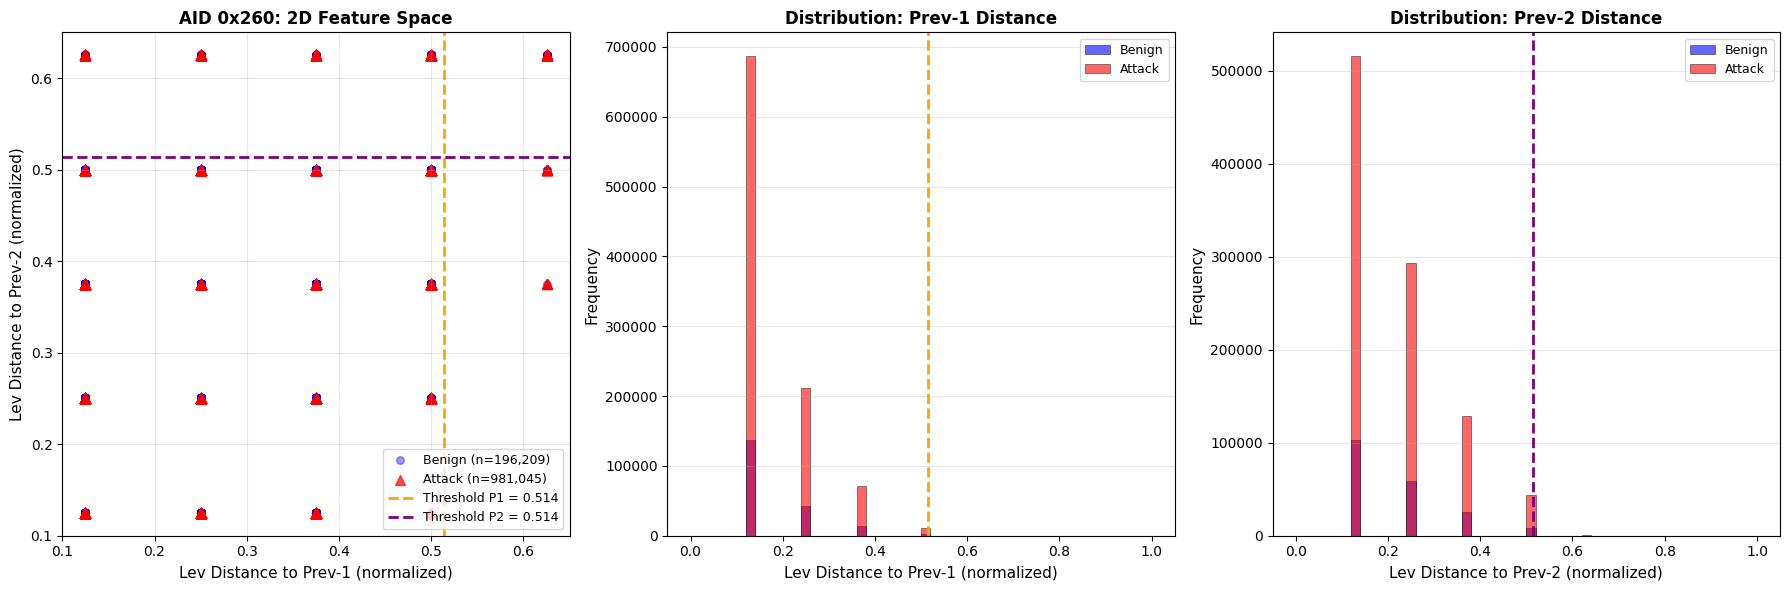


AID 0x260 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):     575  (attacks detected)
   False Negatives (FN): 980470  (attacks missed)
   True Negatives (TN):  196094  (benign correctly classified)
   False Positives (FP):    115  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.71%
   Detection Rate (TPR):   0.06%  (How many attacks caught)
   False Alarm Rate:       0.06%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               0.12%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x2B0 (masq-2B0h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x2B0
Data: 196,178 benign, 980,890 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.624
   Threshold P2: 0.624

   Performance:
   - Detection 

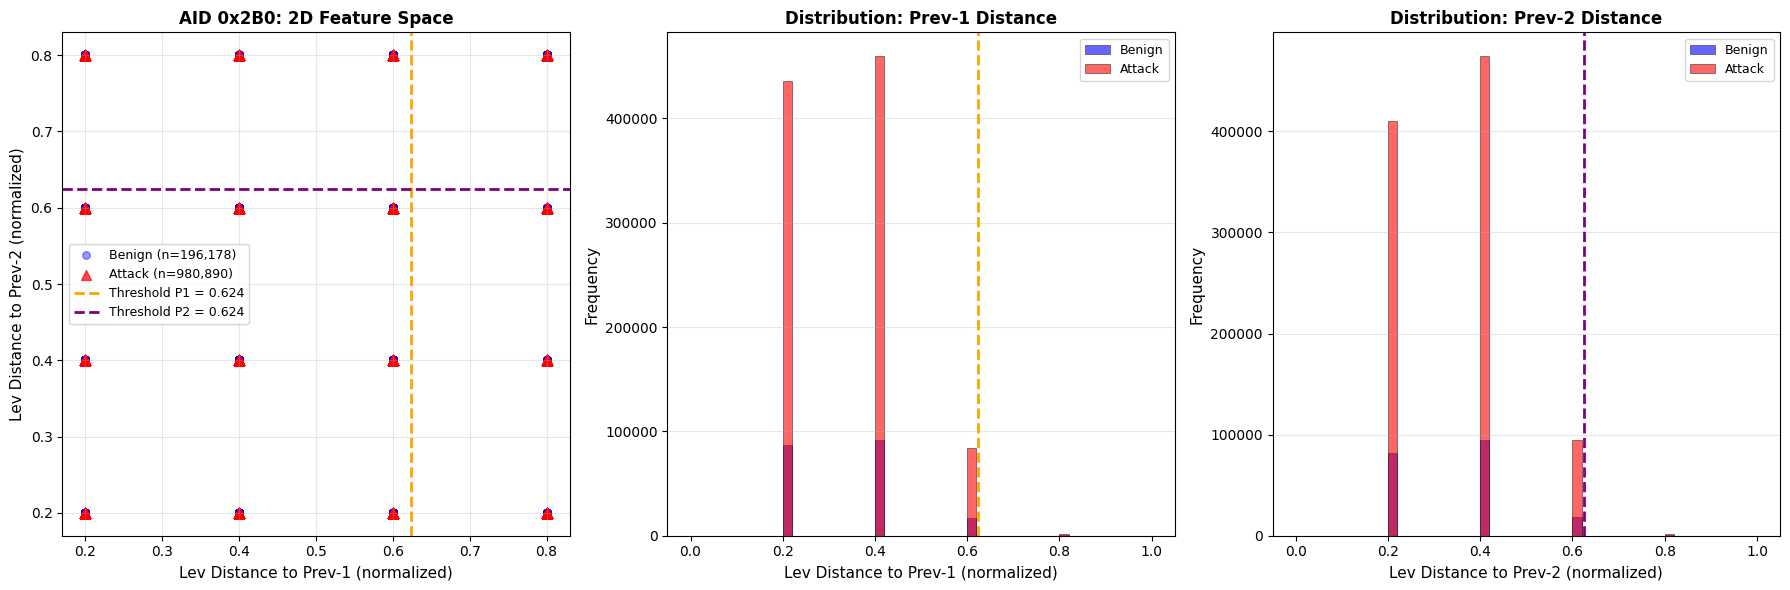


AID 0x2B0 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):    2465  (attacks detected)
   False Negatives (FN): 978425  (attacks missed)
   True Negatives (TN):  195685  (benign correctly classified)
   False Positives (FP):    493  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.83%
   Detection Rate (TPR):   0.25%  (How many attacks caught)
   False Alarm Rate:       0.25%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               0.50%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x316 (masq-316h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x316
Data: 196,209 benign, 981,045 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.376
   Threshold P2: 0.652

   Performance:
   - Detection 

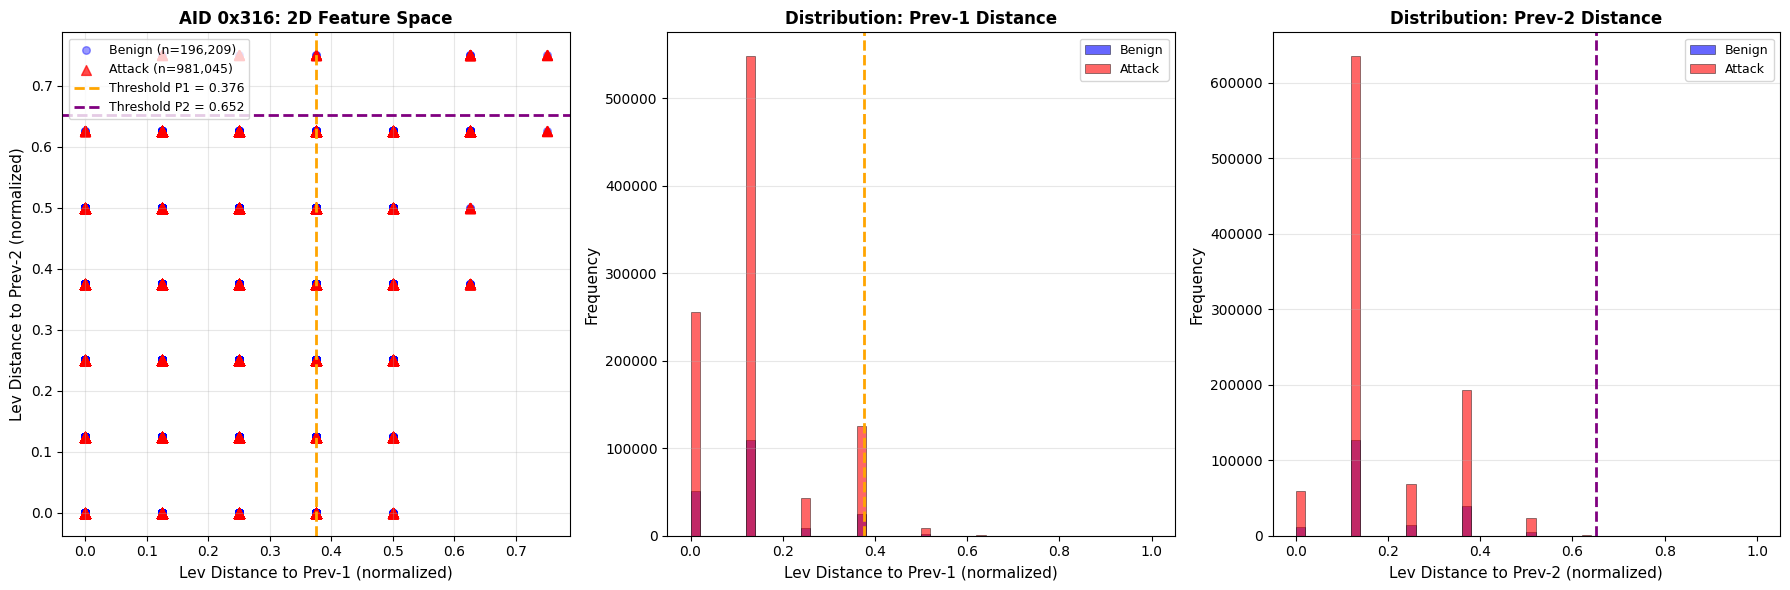


AID 0x316 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):    9400  (attacks detected)
   False Negatives (FN): 971645  (attacks missed)
   True Negatives (TN):  194329  (benign correctly classified)
   False Positives (FP):   1880  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             17.31%
   Detection Rate (TPR):   0.96%  (How many attacks caught)
   False Alarm Rate:       0.96%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               1.89%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x329 (masq-329h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x329
Data: 196,209 benign, 981,045 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.266
   Threshold P2: 0.376

   Performance:
   - Detection 

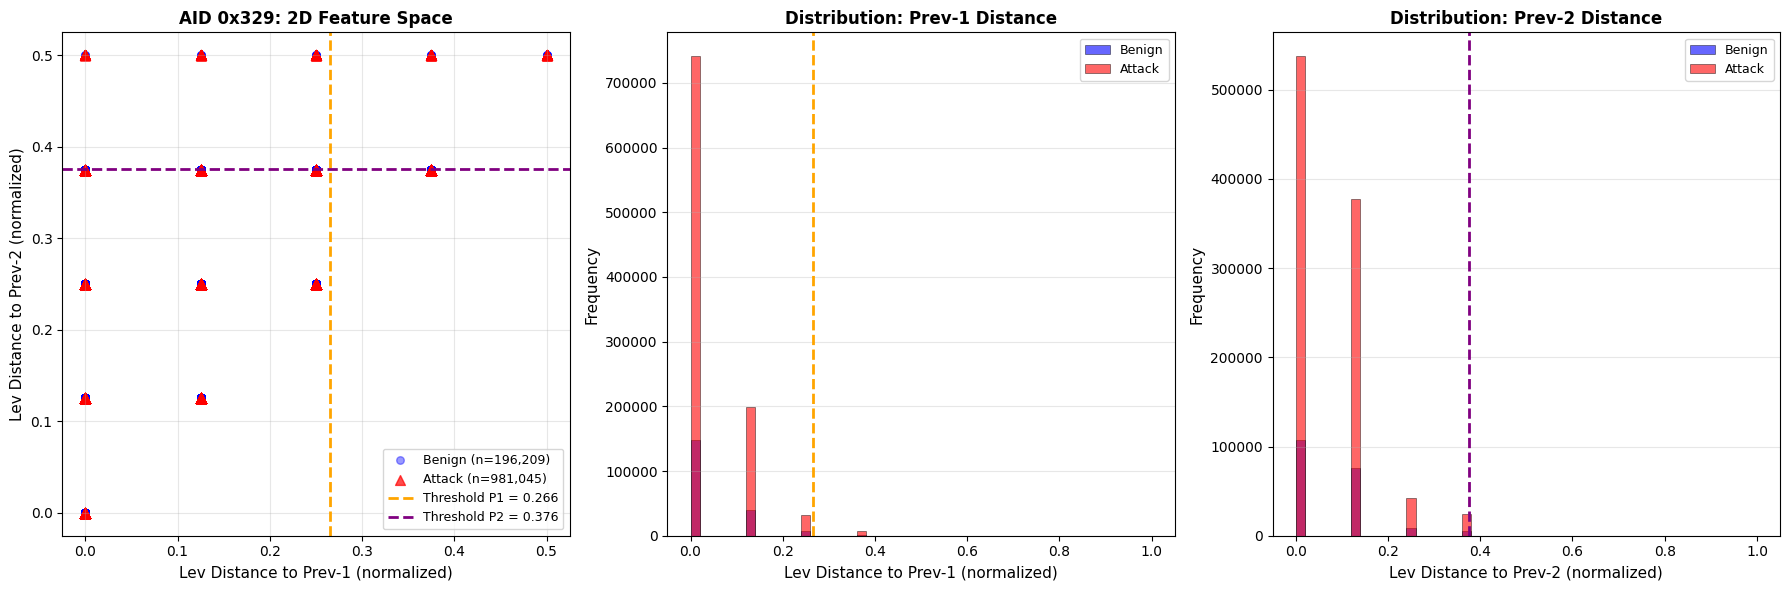


AID 0x329 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):    7710  (attacks detected)
   False Negatives (FN): 973335  (attacks missed)
   True Negatives (TN):  194667  (benign correctly classified)
   False Positives (FP):   1542  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             17.19%
   Detection Rate (TPR):   0.79%  (How many attacks caught)
   False Alarm Rate:       0.79%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               1.56%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x381 (masq-381h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x381
Data: 98,091 benign, 490,455 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.376
   Threshold P2: 0.514

   Performance:
   - Detection R

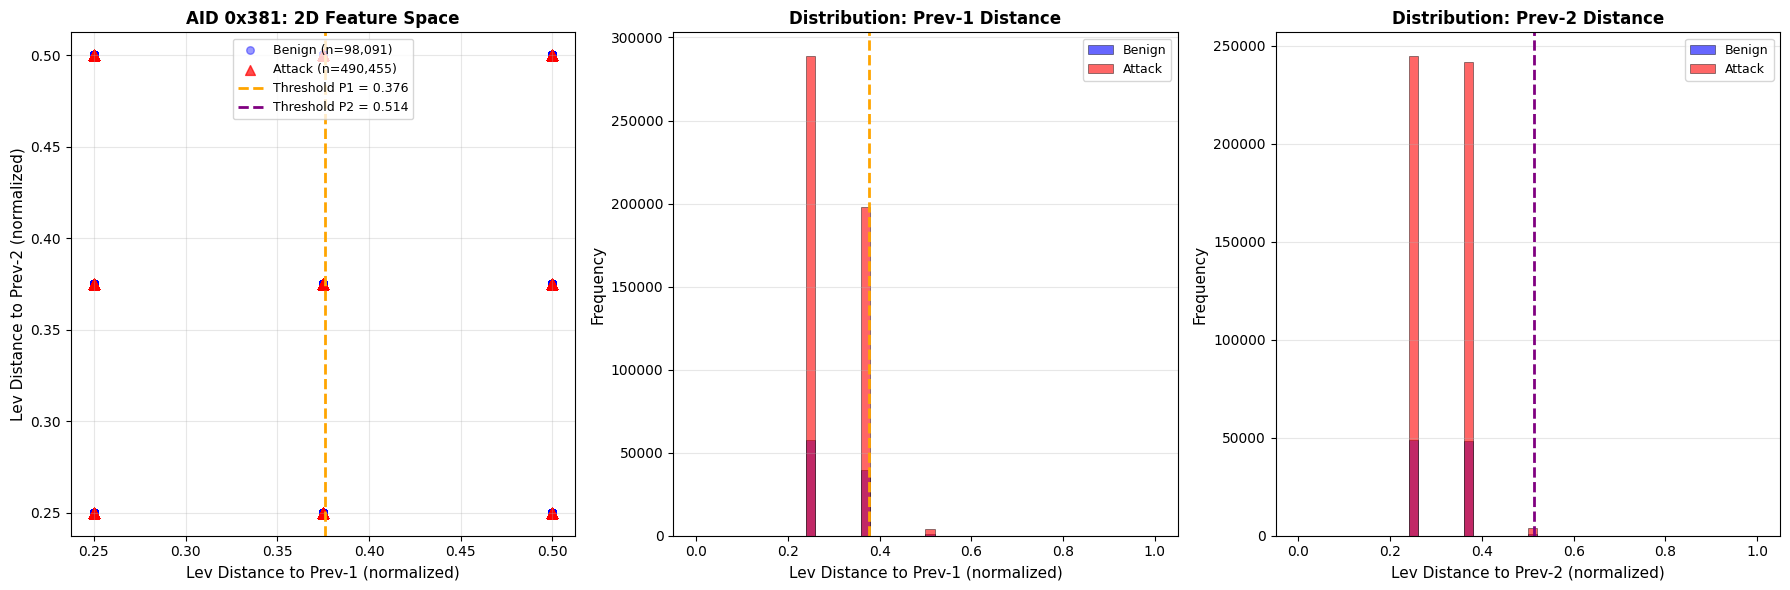


AID 0x381 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):    3950  (attacks detected)
   False Negatives (FN): 486505  (attacks missed)
   True Negatives (TN):   97301  (benign correctly classified)
   False Positives (FP):    790  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             17.20%
   Detection Rate (TPR):   0.81%  (How many attacks caught)
   False Alarm Rate:       0.81%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               1.60%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x383 (masq-383h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x383
Data: 98,334 benign, 491,670 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.266
   Threshold P2: 0.266

   Performance:
   - Detection R

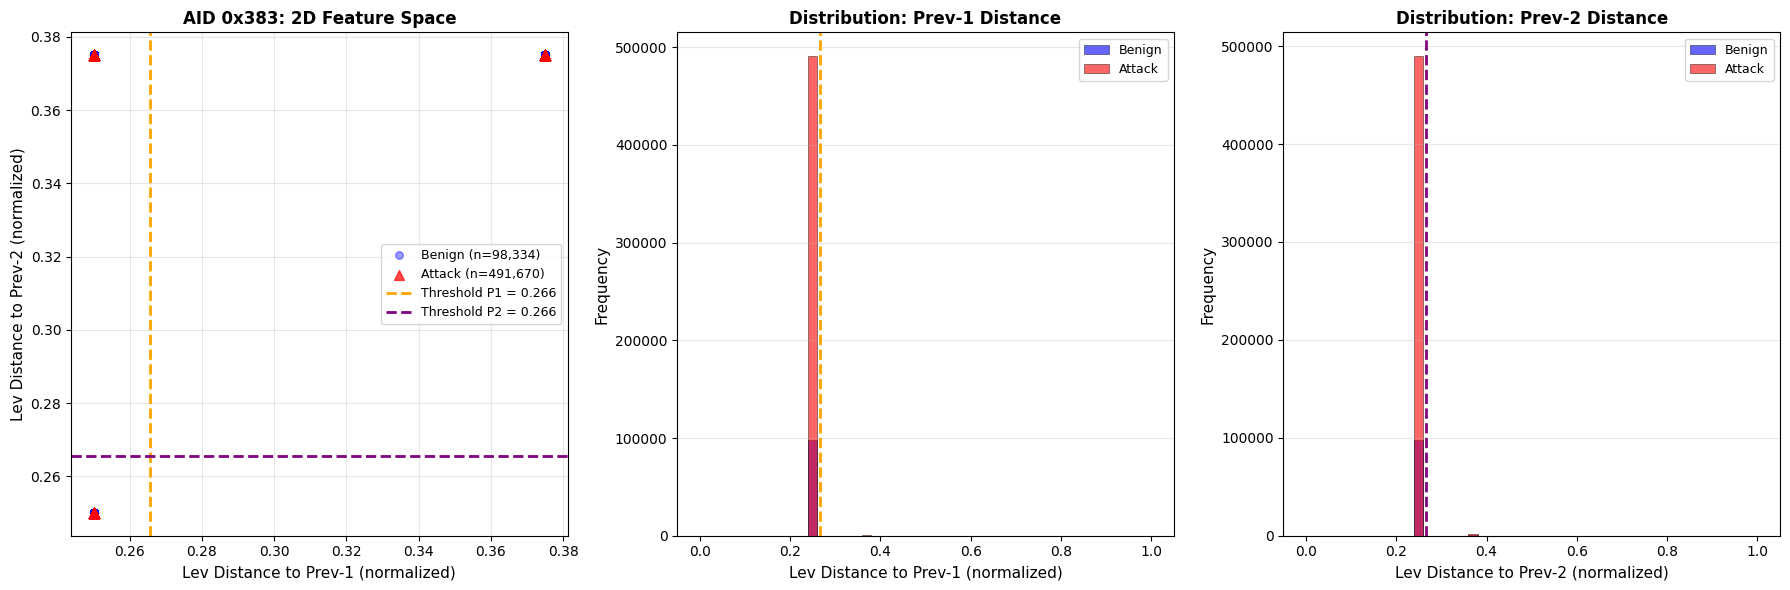


AID 0x383 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):    2100  (attacks detected)
   False Negatives (FN): 489570  (attacks missed)
   True Negatives (TN):   97914  (benign correctly classified)
   False Positives (FP):    420  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.95%
   Detection Rate (TPR):   0.43%  (How many attacks caught)
   False Alarm Rate:       0.43%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               0.85%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x386 (masq-386h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x386
Data: 98,102 benign, 490,510 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...
❌ No configuration found meeting FPR ≤ 1.0%
   Try increasing target_fpr or checking your data distribution


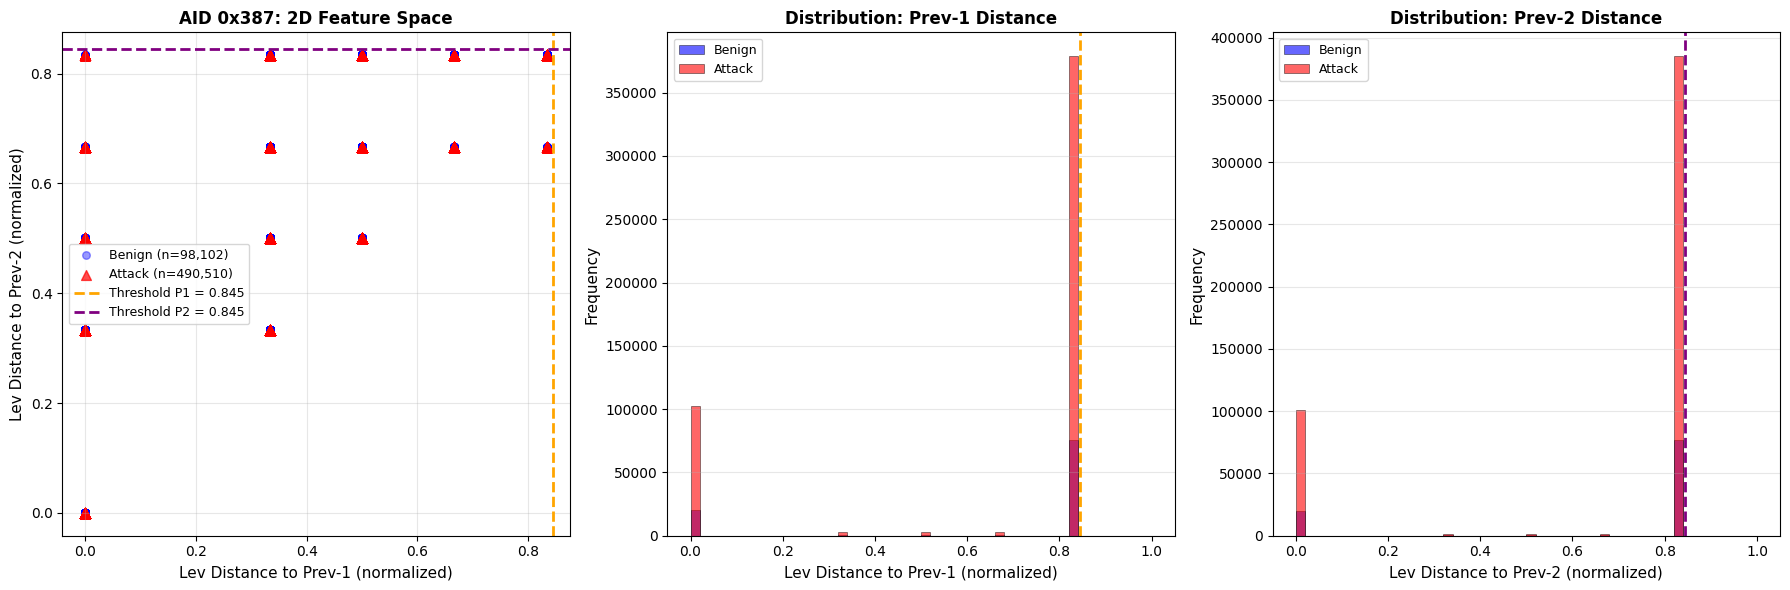


AID 0x387 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):       0  (attacks detected)
   False Negatives (FN): 490510  (attacks missed)
   True Negatives (TN):   98102  (benign correctly classified)
   False Positives (FP):      0  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.67%
   Detection Rate (TPR):   0.00%  (How many attacks caught)
   False Alarm Rate:       0.00%  (How many benign flagged)
   Precision:              0.00%  (When flagged, how often correct)
   F1-Score:               0.00%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x47F (masq-47Fh)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x47F
Data: 98,102 benign, 490,510 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.183
   Threshold P2: 0.183

   Performance:
   - Detection R

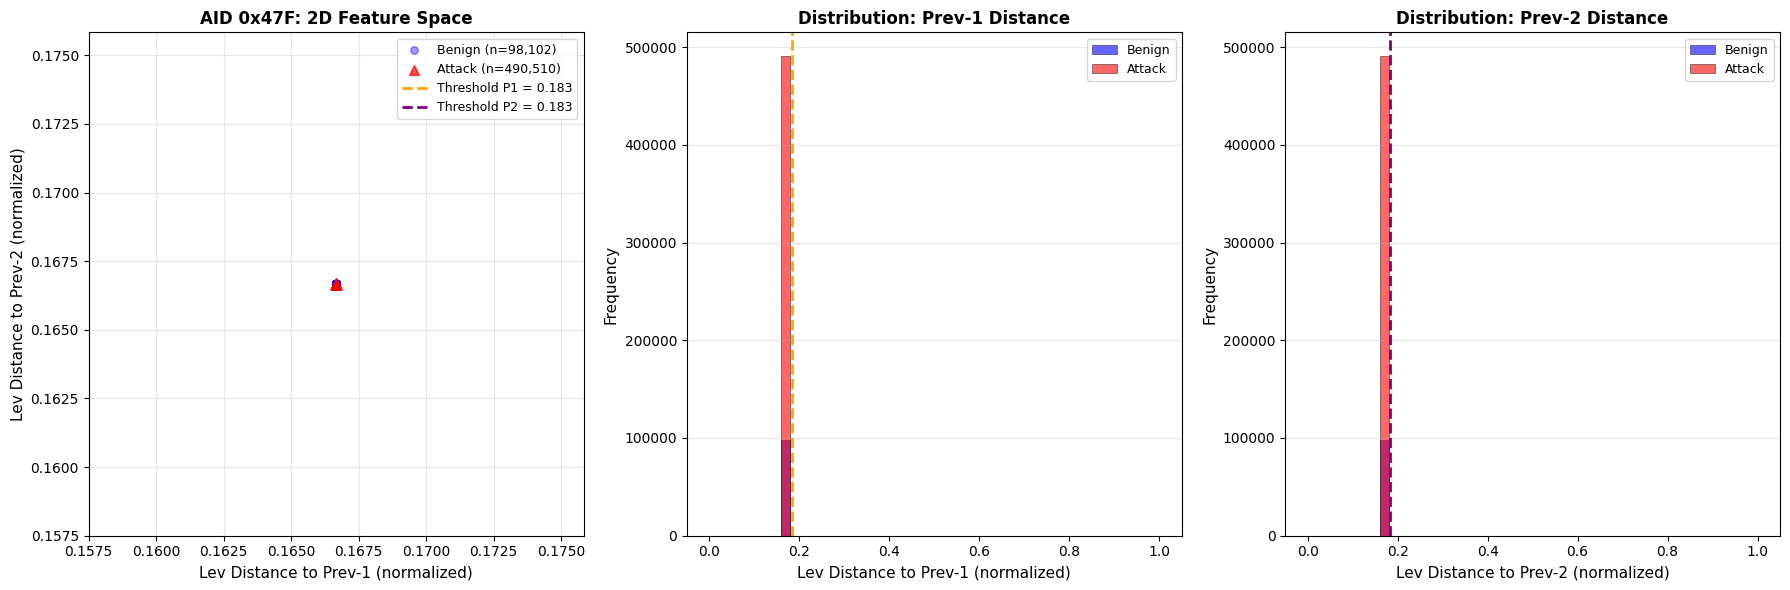


AID 0x47F - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):       0  (attacks detected)
   False Negatives (FN): 490510  (attacks missed)
   True Negatives (TN):   98102  (benign correctly classified)
   False Positives (FP):      0  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.67%
   Detection Rate (TPR):   0.00%  (How many attacks caught)
   False Alarm Rate:       0.00%  (How many benign flagged)
   Precision:              0.00%  (When flagged, how often correct)
   F1-Score:               0.00%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x4F1 (masq-4F1h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x4F1
Data: 98,129 benign, 490,645 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.762
   Threshold P2: 0.762

   Performance:
   - Detection R

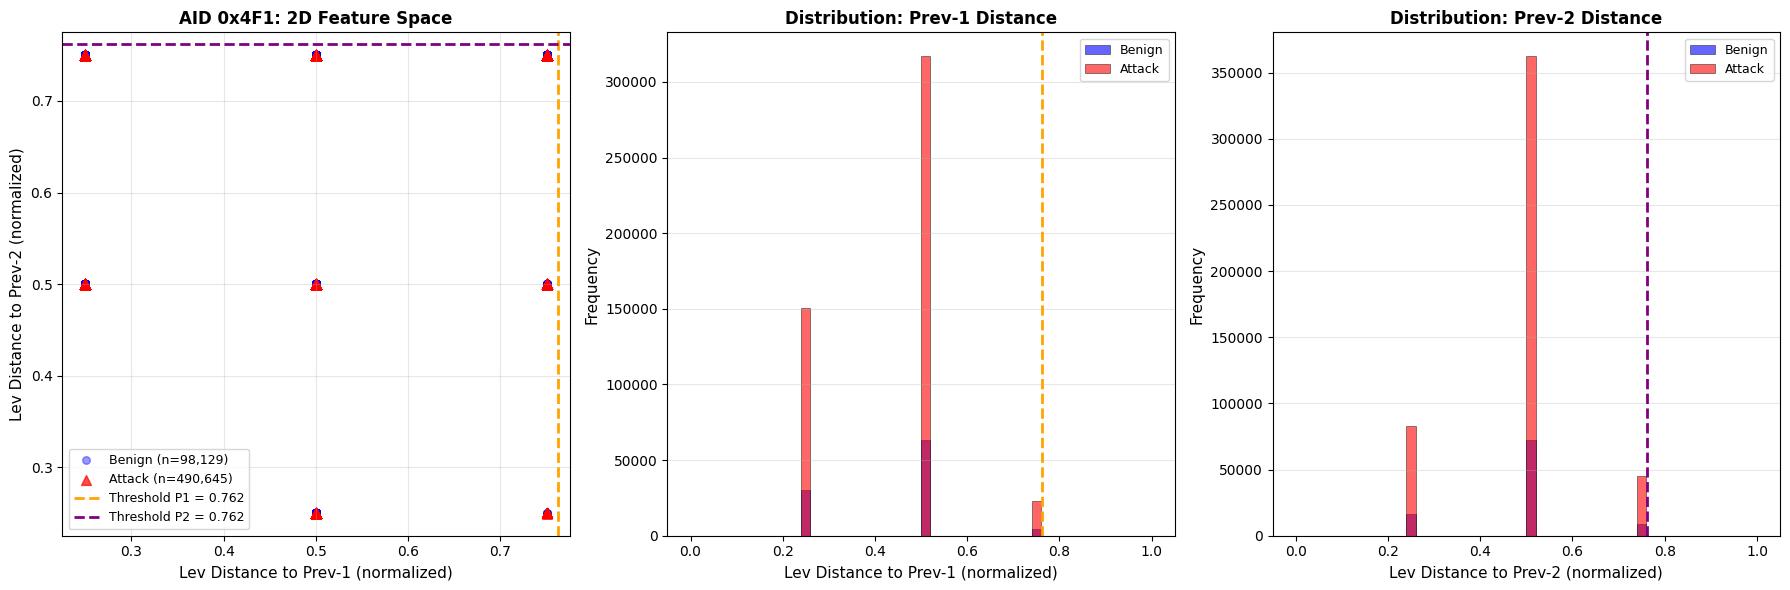


AID 0x4F1 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):       0  (attacks detected)
   False Negatives (FN): 490645  (attacks missed)
   True Negatives (TN):   98129  (benign correctly classified)
   False Positives (FP):      0  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.67%
   Detection Rate (TPR):   0.00%  (How many attacks caught)
   False Alarm Rate:       0.00%  (How many benign flagged)
   Precision:              0.00%  (When flagged, how often correct)
   F1-Score:               0.00%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x50C (masq-50Ch)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x50C
Data: 19,624 benign, 98,120 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.128
   Threshold P2: 0.128

   Performance:
   - Detection Ra

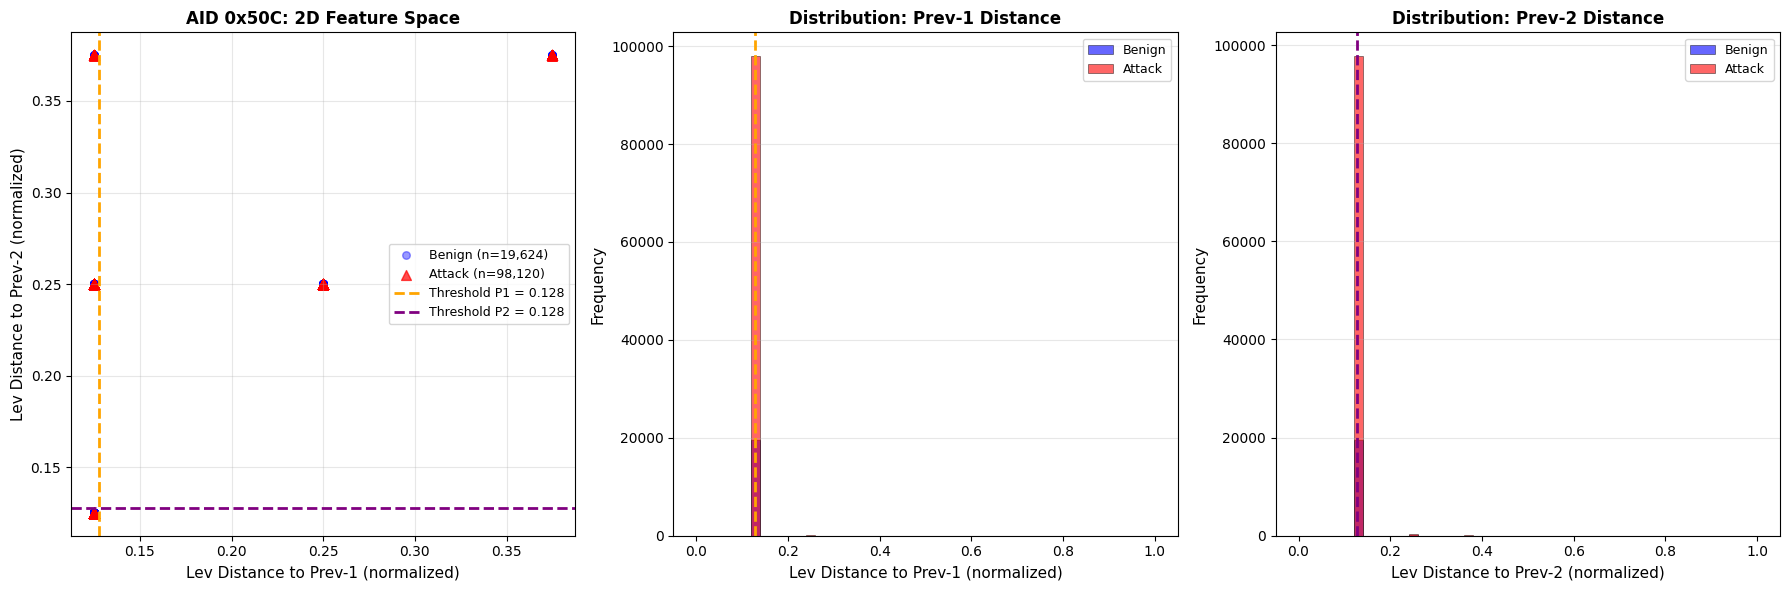


AID 0x50C - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):     410  (attacks detected)
   False Negatives (FN):  97710  (attacks missed)
   True Negatives (TN):   19542  (benign correctly classified)
   False Positives (FP):     82  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.95%
   Detection Rate (TPR):   0.42%  (How many attacks caught)
   False Alarm Rate:       0.42%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               0.83%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x52A (masq-52Ah)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x52A
Data: 17,940 benign, 89,700 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.128
   Threshold P2: 0.128

   Performance:
   - Detection Ra

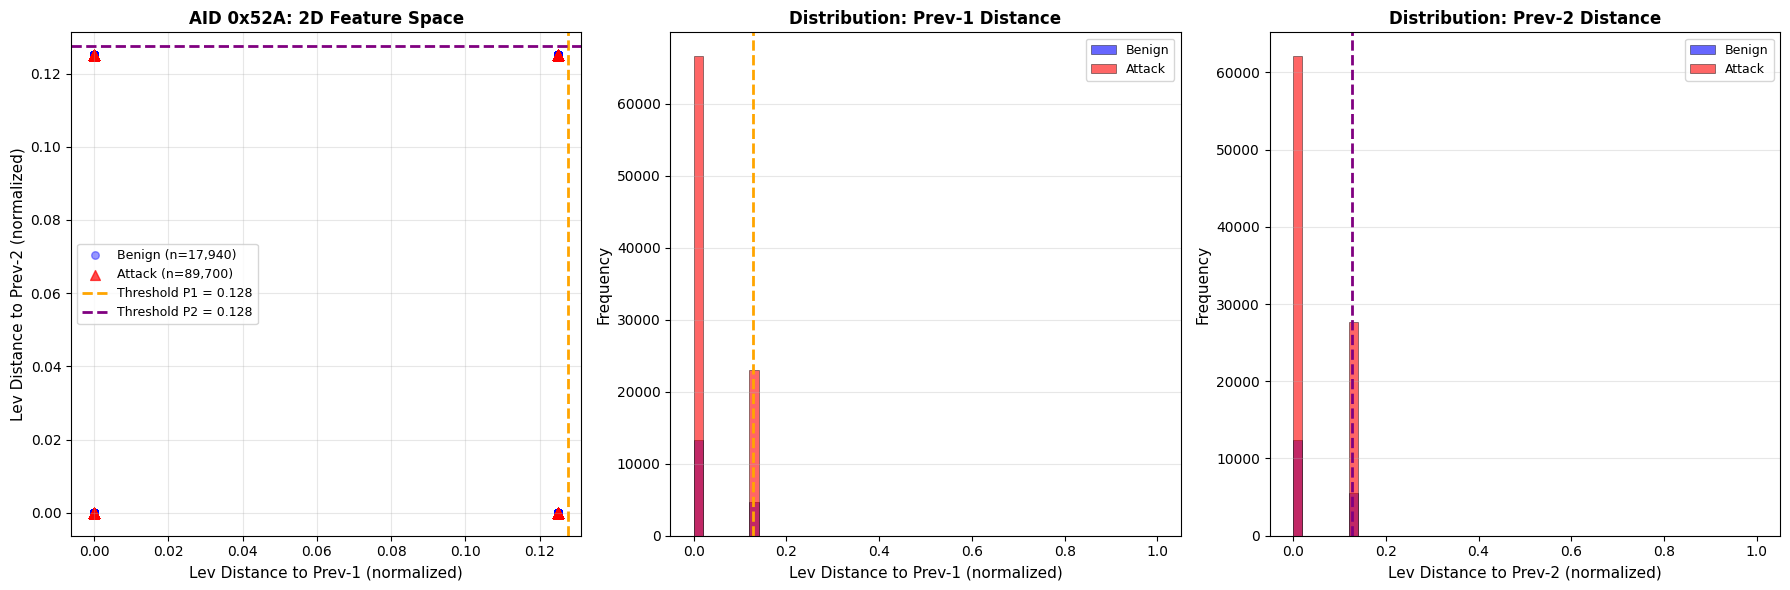


AID 0x52A - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):       0  (attacks detected)
   False Negatives (FN):  89700  (attacks missed)
   True Negatives (TN):   17940  (benign correctly classified)
   False Positives (FP):      0  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.67%
   Detection Rate (TPR):   0.00%  (How many attacks caught)
   False Alarm Rate:       0.00%  (How many benign flagged)
   Precision:              0.00%  (When flagged, how often correct)
   F1-Score:               0.00%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x541 (masq-541h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x541
Data: 20,483 benign, 102,415 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.128
   Threshold P2: 0.128

   Performance:
   - Detection R

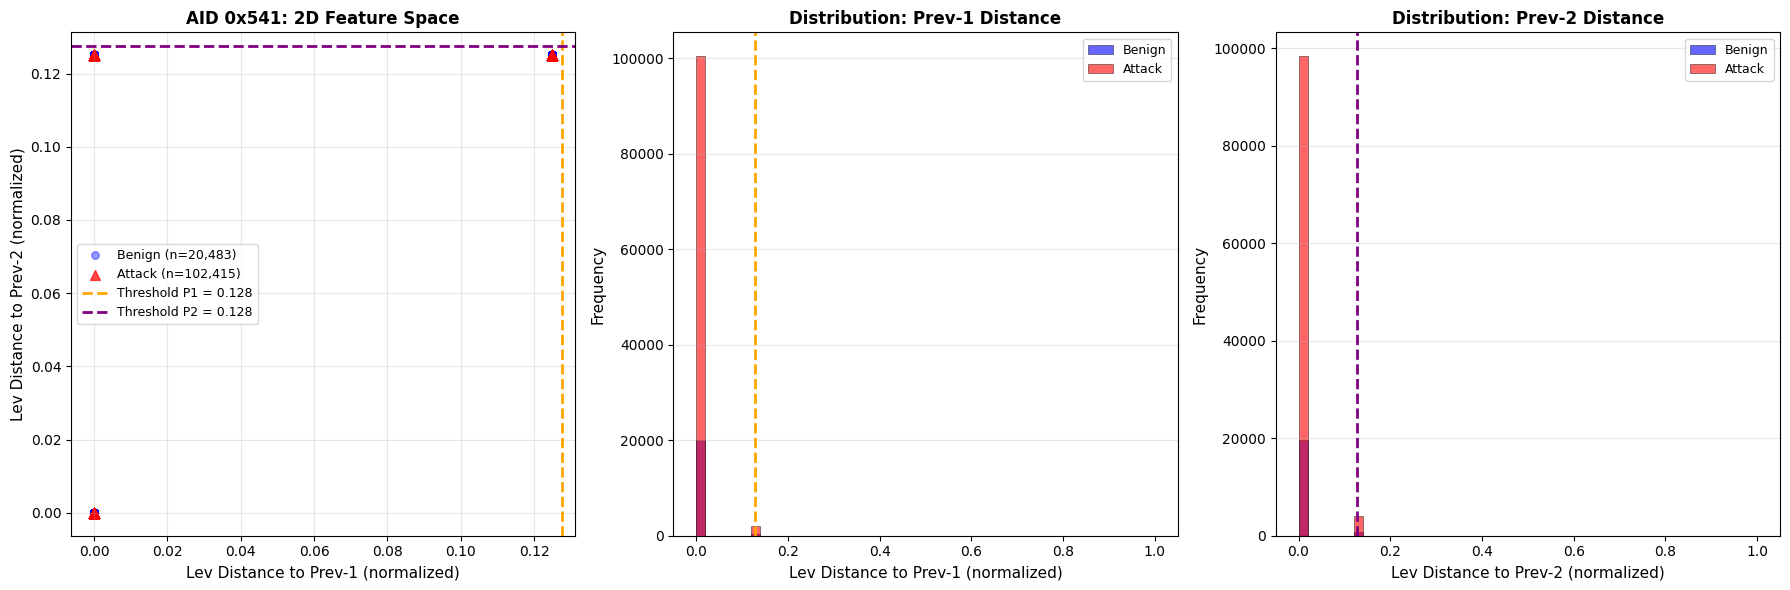


AID 0x541 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):       0  (attacks detected)
   False Negatives (FN): 102415  (attacks missed)
   True Negatives (TN):   20483  (benign correctly classified)
   False Positives (FP):      0  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.67%
   Detection Rate (TPR):   0.00%  (How many attacks caught)
   False Alarm Rate:       0.00%  (How many benign flagged)
   Precision:              0.00%  (When flagged, how often correct)
   F1-Score:               0.00%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x545 (masq-545h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x545
Data: 19,619 benign, 98,095 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.266
   Threshold P2: 0.266

   Performance:
   - Detection Ra

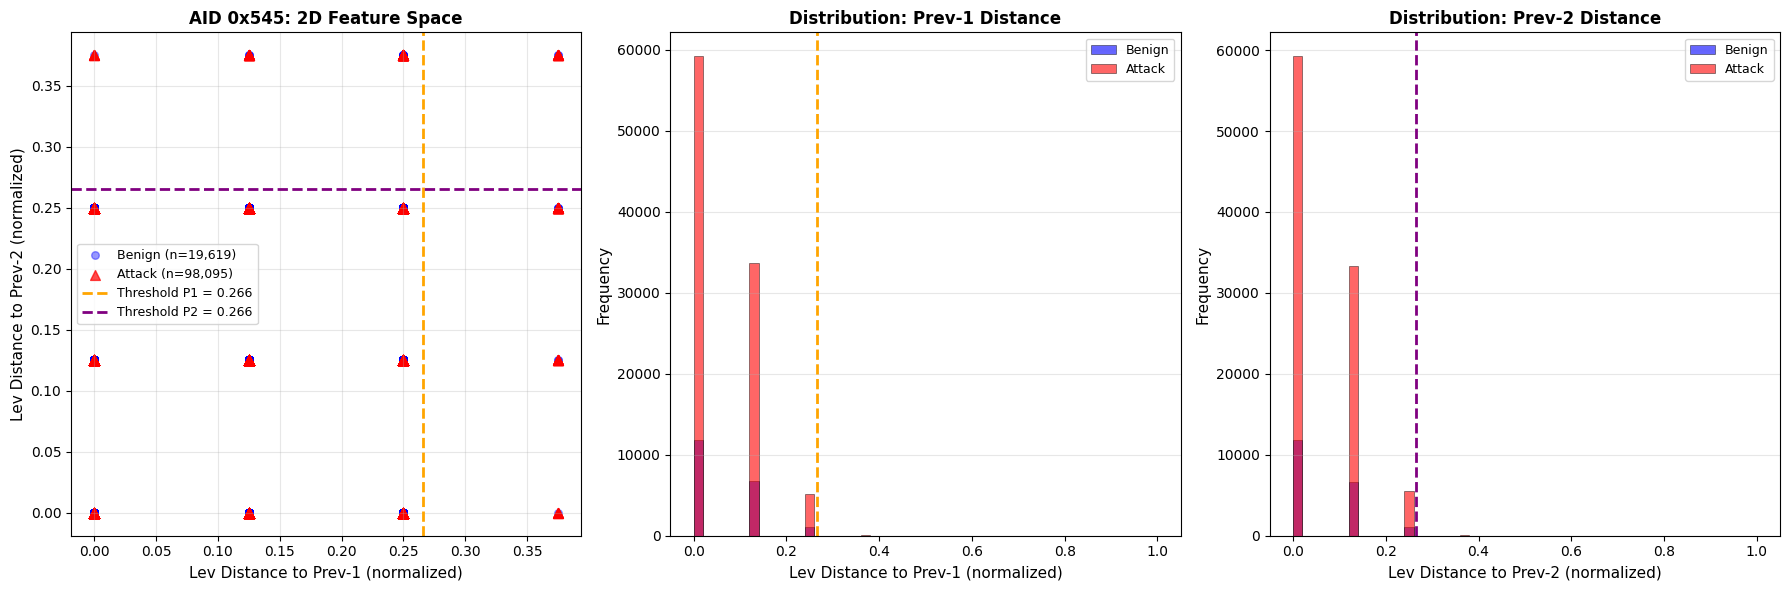


AID 0x545 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):     100  (attacks detected)
   False Negatives (FN):  97995  (attacks missed)
   True Negatives (TN):   19599  (benign correctly classified)
   False Positives (FP):     20  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.73%
   Detection Rate (TPR):   0.10%  (How many attacks caught)
   False Alarm Rate:       0.10%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               0.20%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x547 (masq-547h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x547
Data: 19,619 benign, 98,095 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.128
   Threshold P2: 0.128

   Performance:
   - Detection Ra

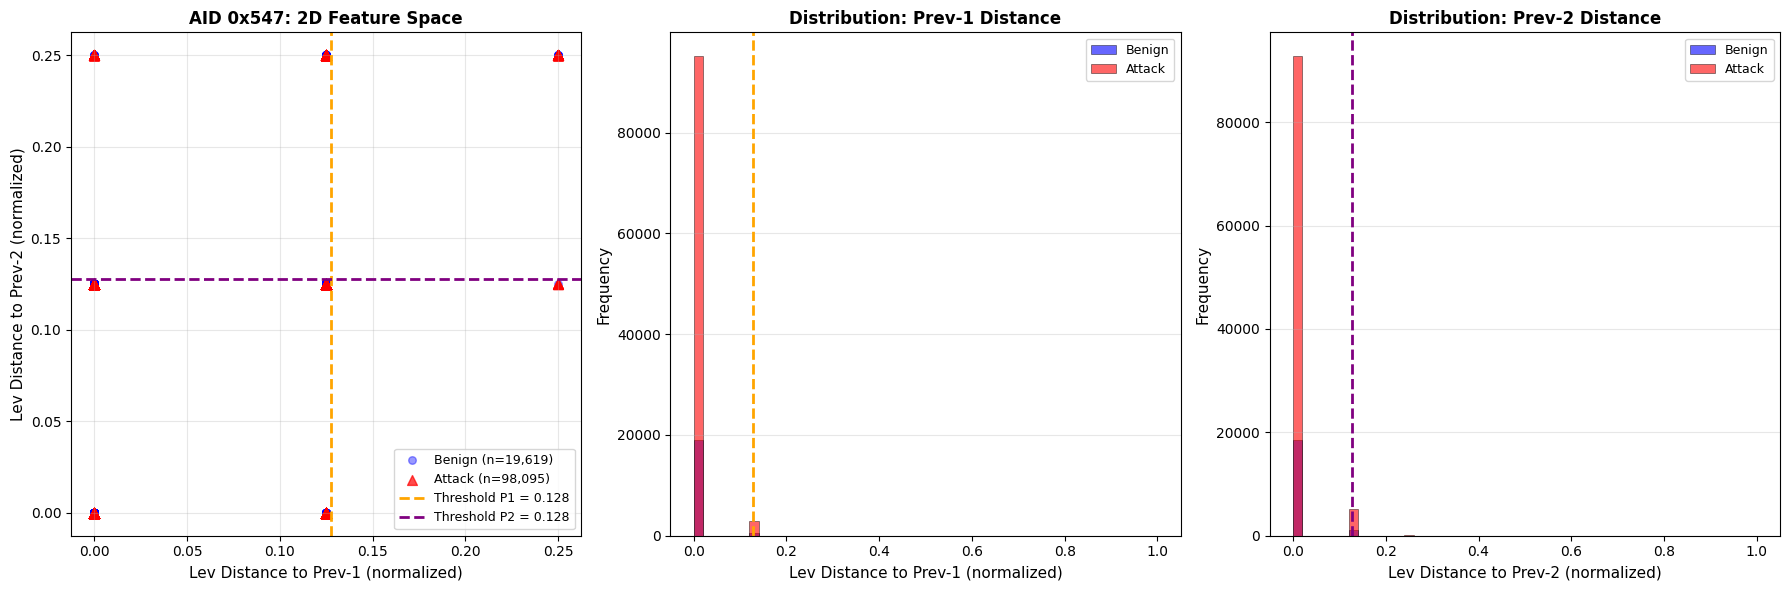


AID 0x547 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):     135  (attacks detected)
   False Negatives (FN):  97960  (attacks missed)
   True Negatives (TN):   19592  (benign correctly classified)
   False Positives (FP):     27  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.76%
   Detection Rate (TPR):   0.14%  (How many attacks caught)
   False Alarm Rate:       0.14%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               0.27%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x549 (masq-549h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x549
Data: 19,619 benign, 98,095 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.376
   Threshold P2: 0.376

   Performance:
   - Detection Ra

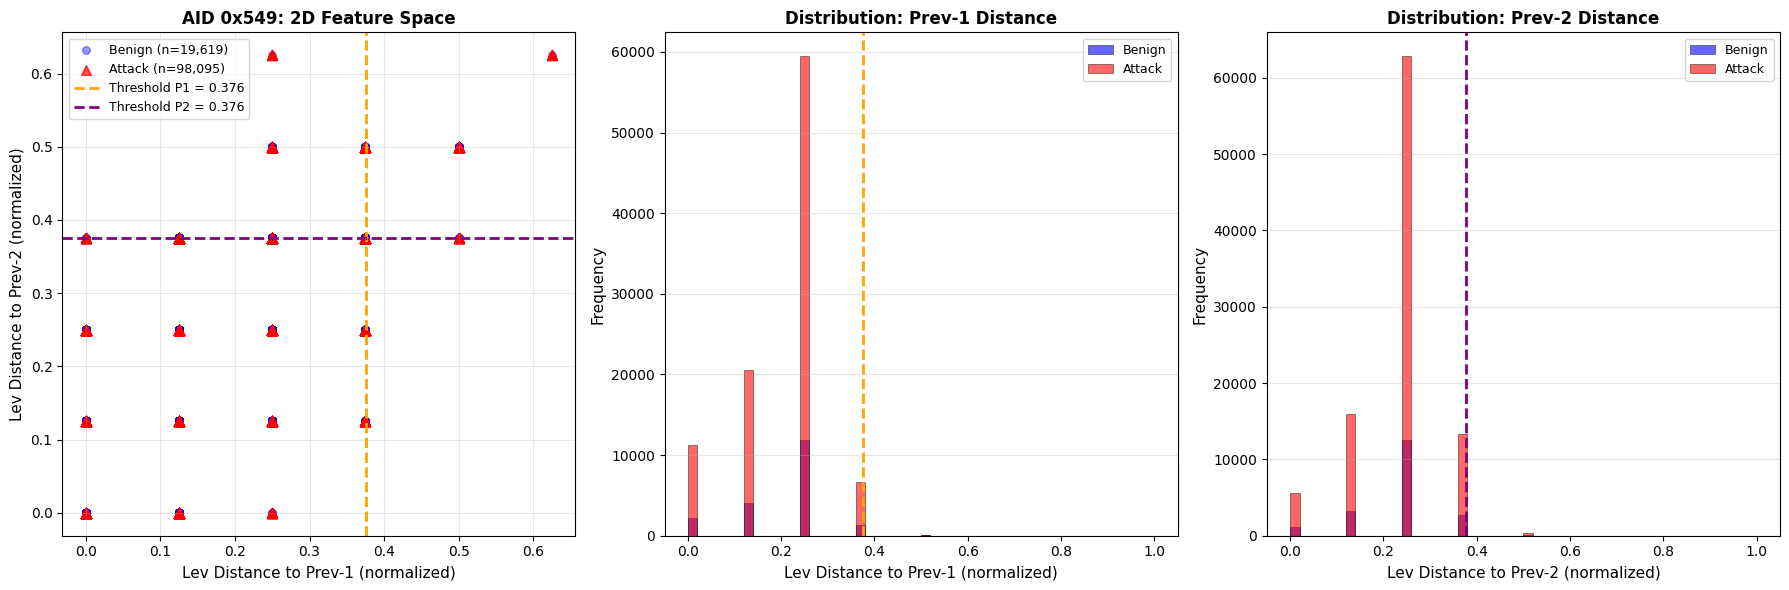


AID 0x549 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):     400  (attacks detected)
   False Negatives (FN):  97695  (attacks missed)
   True Negatives (TN):   19539  (benign correctly classified)
   False Positives (FP):     80  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.94%
   Detection Rate (TPR):   0.41%  (How many attacks caught)
   False Alarm Rate:       0.41%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               0.81%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x553 (masq-553h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x553
Data: 9,872 benign, 49,360 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.100
   Threshold P2: 0.100

   Performance:
   - Detection Rat

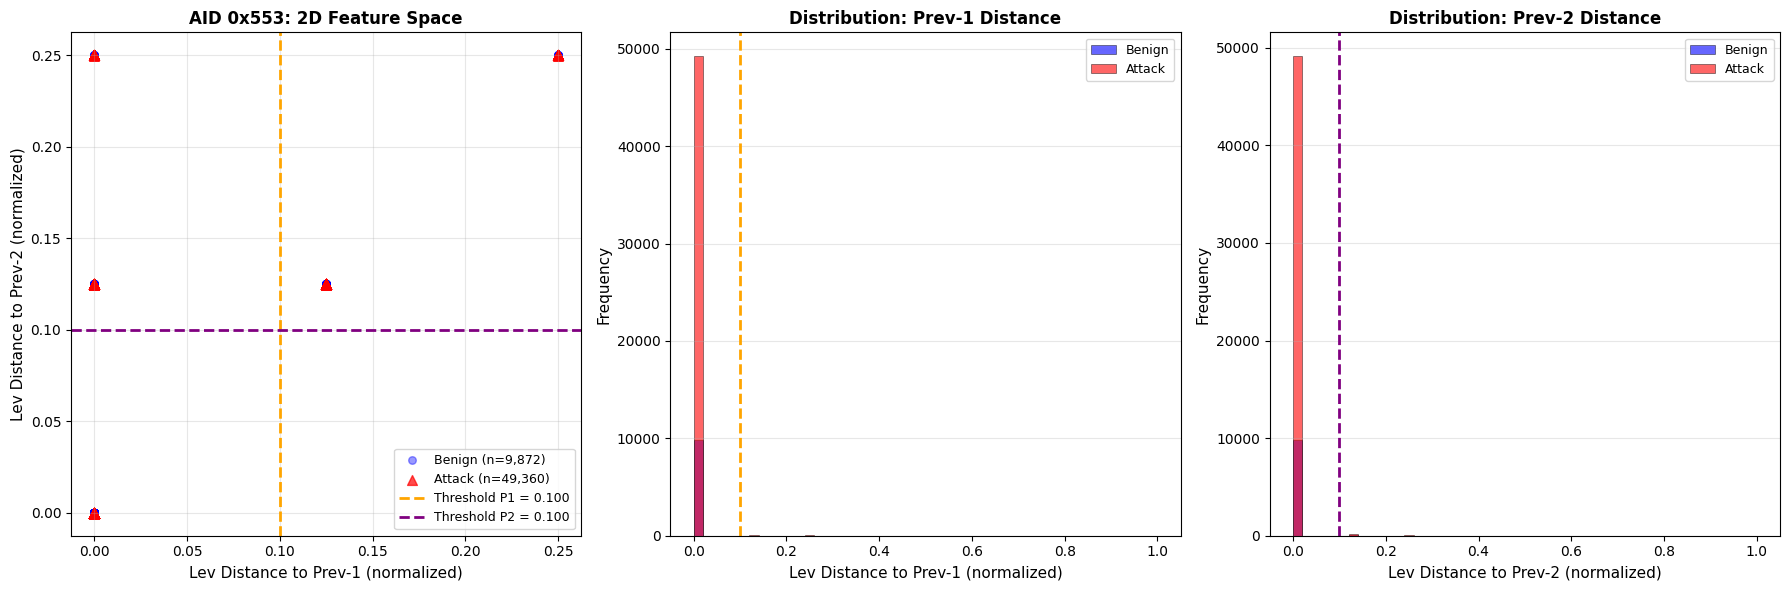


AID 0x553 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):     240  (attacks detected)
   False Negatives (FN):  49120  (attacks missed)
   True Negatives (TN):    9824  (benign correctly classified)
   False Positives (FP):     48  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.99%
   Detection Rate (TPR):   0.49%  (How many attacks caught)
   False Alarm Rate:       0.49%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               0.97%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x555 (masq-555h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x555
Data: 19,648 benign, 98,240 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.376
   Threshold P2: 0.514

   Performance:
   - Detection Ra

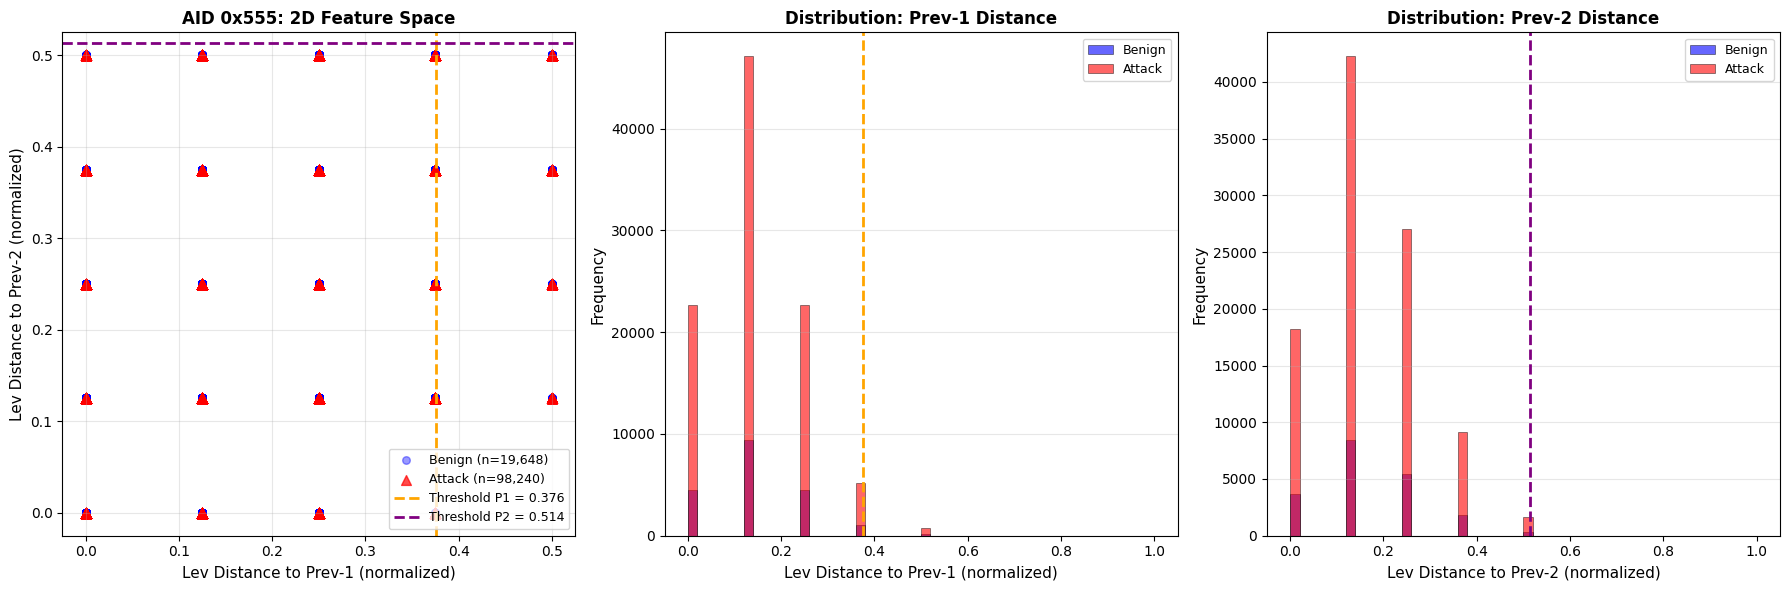


AID 0x555 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):     750  (attacks detected)
   False Negatives (FN):  97490  (attacks missed)
   True Negatives (TN):   19498  (benign correctly classified)
   False Positives (FP):    150  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             17.18%
   Detection Rate (TPR):   0.76%  (How many attacks caught)
   False Alarm Rate:       0.76%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               1.51%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x556 (masq-556h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x556
Data: 19,619 benign, 98,095 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.514
   Threshold P2: 0.652

   Performance:
   - Detection Ra

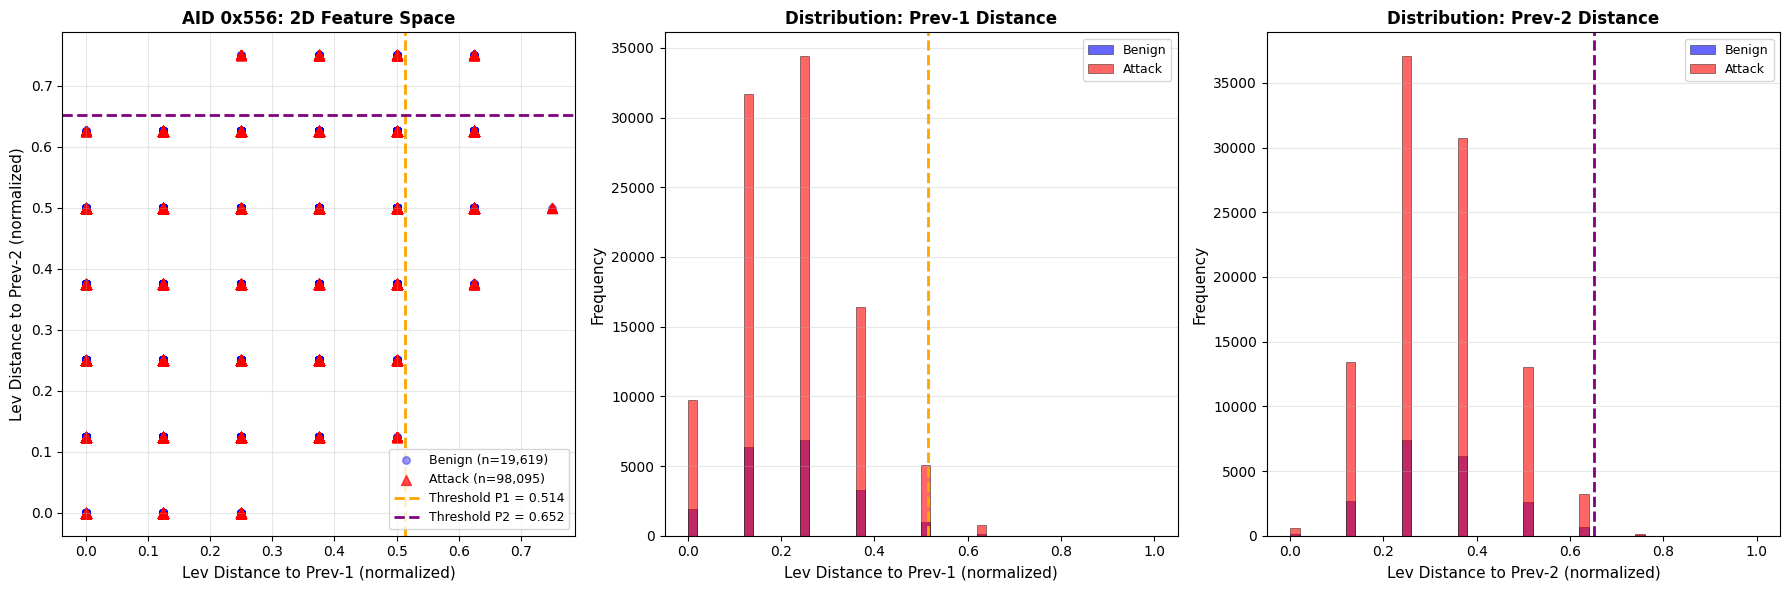


AID 0x556 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):     865  (attacks detected)
   False Negatives (FN):  97230  (attacks missed)
   True Negatives (TN):   19446  (benign correctly classified)
   False Positives (FP):    173  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             17.25%
   Detection Rate (TPR):   0.88%  (How many attacks caught)
   False Alarm Rate:       0.88%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               1.75%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x557 (masq-557h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x557
Data: 19,619 benign, 98,095 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.376
   Threshold P2: 0.376

   Performance:
   - Detection Ra

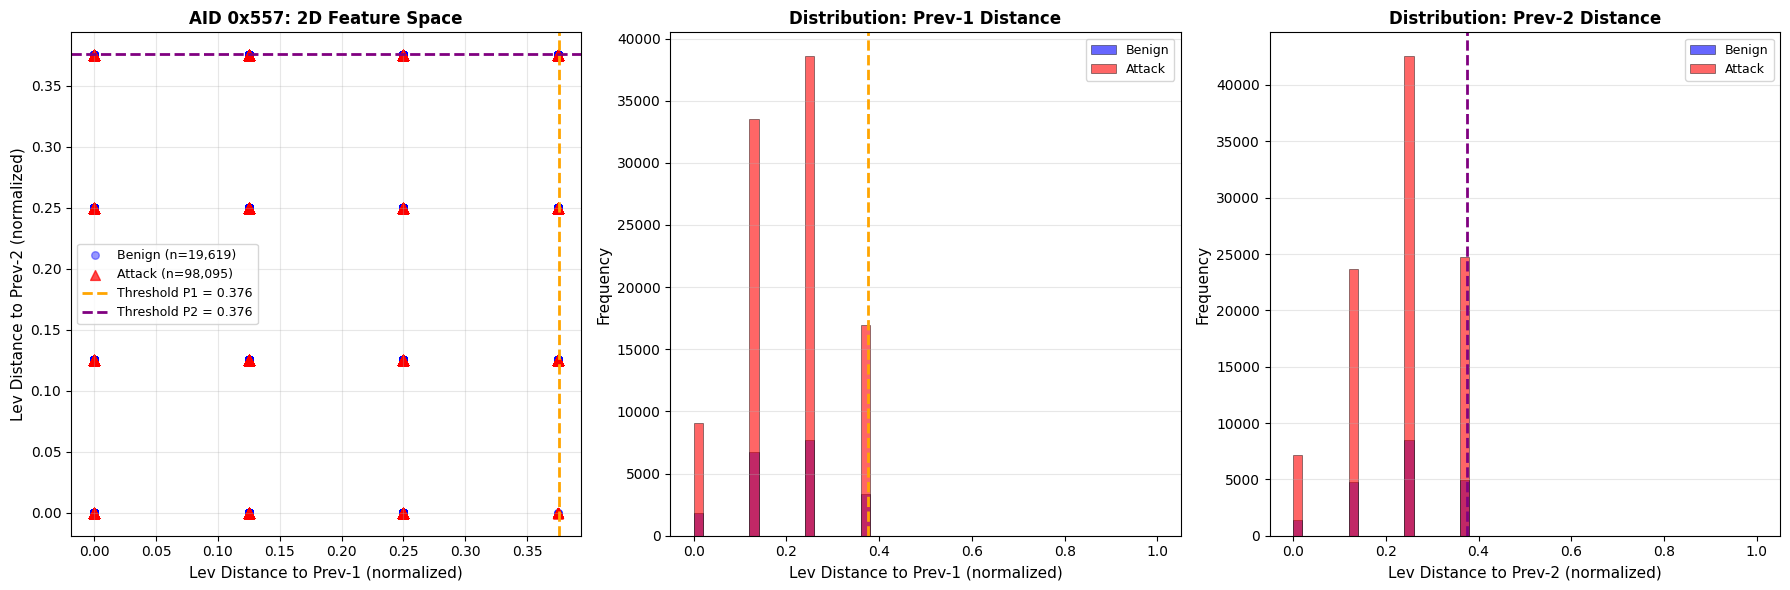


AID 0x557 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):       0  (attacks detected)
   False Negatives (FN):  98095  (attacks missed)
   True Negatives (TN):   19619  (benign correctly classified)
   False Positives (FP):      0  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.67%
   Detection Rate (TPR):   0.00%  (How many attacks caught)
   False Alarm Rate:       0.00%  (How many benign flagged)
   Precision:              0.00%  (When flagged, how often correct)
   F1-Score:               0.00%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x58B (masq-58Bh)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x58B
Data: 19,617 benign, 98,085 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.100
   Threshold P2: 0.100

   Performance:
   - Detection Ra

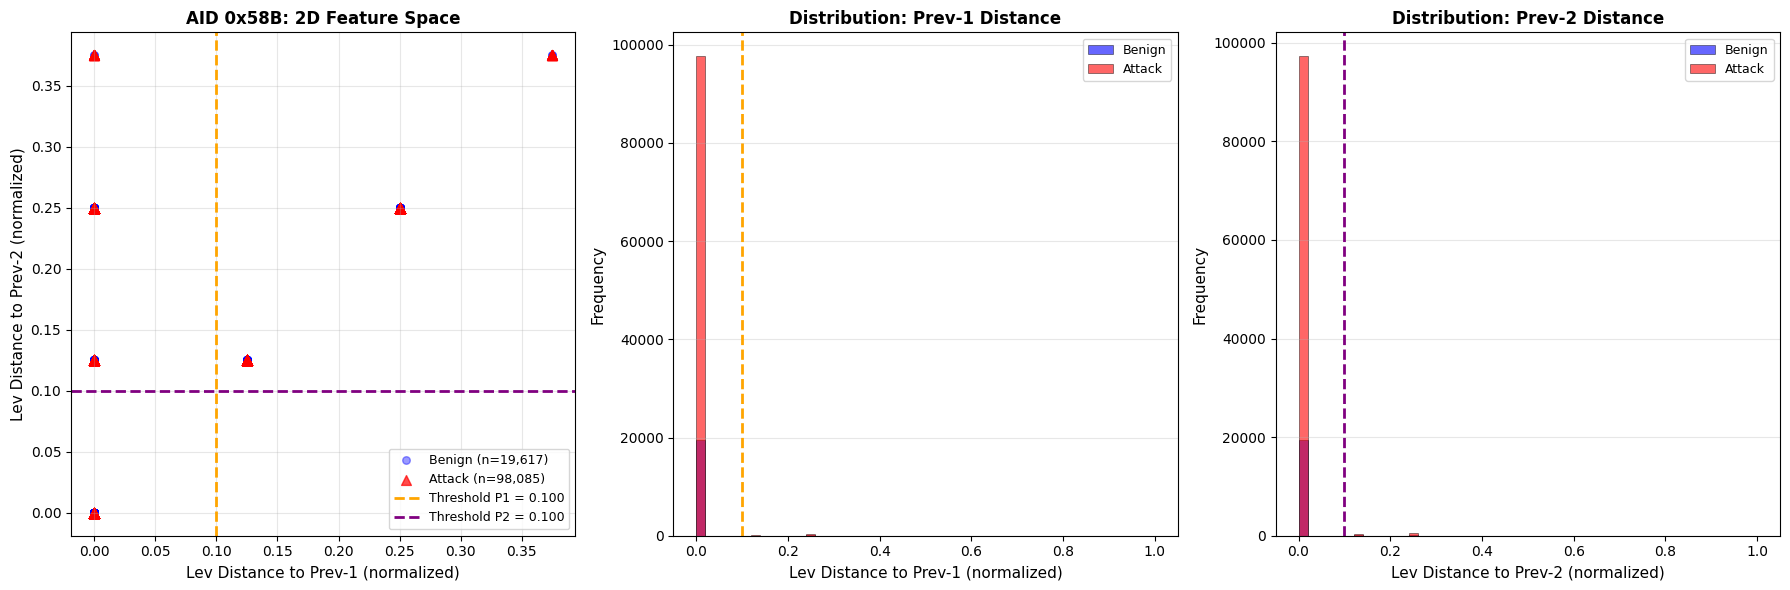


AID 0x58B - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):     850  (attacks detected)
   False Negatives (FN):  97235  (attacks missed)
   True Negatives (TN):   19447  (benign correctly classified)
   False Positives (FP):    170  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             17.24%
   Detection Rate (TPR):   0.87%  (How many attacks caught)
   False Alarm Rate:       0.87%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               1.72%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x593 (masq-593h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x593
Data: 9,808 benign, 49,040 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.100
   Threshold P2: 0.100

   Performance:
   - Detection Rat

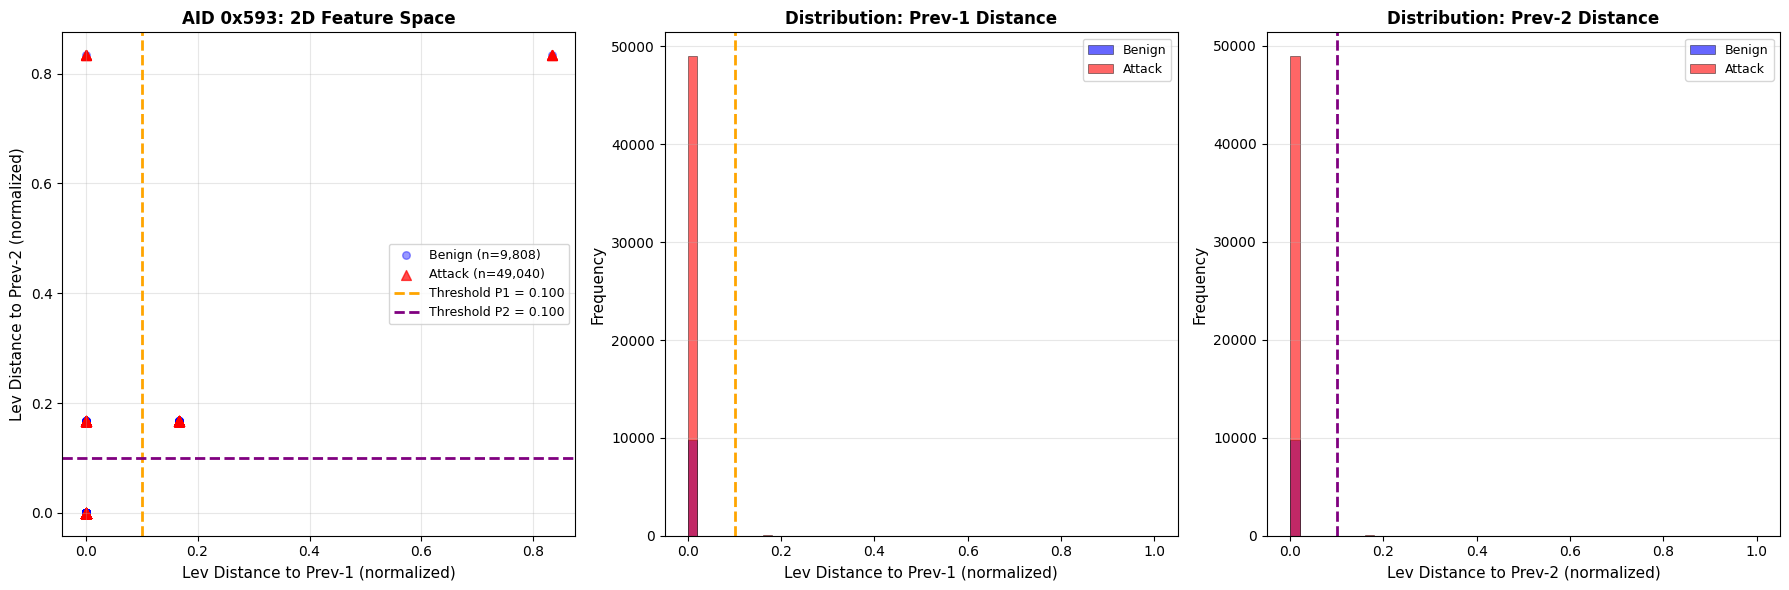


AID 0x593 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):     100  (attacks detected)
   False Negatives (FN):  48940  (attacks missed)
   True Negatives (TN):    9788  (benign correctly classified)
   False Positives (FP):     20  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.80%
   Detection Rate (TPR):   0.20%  (How many attacks caught)
   False Alarm Rate:       0.20%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               0.41%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x5A0 (masq-5A0h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x5A0
Data: 1,963 benign, 9,815 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.266
   Threshold P2: 0.100

   Performance:
   - Detection Rate

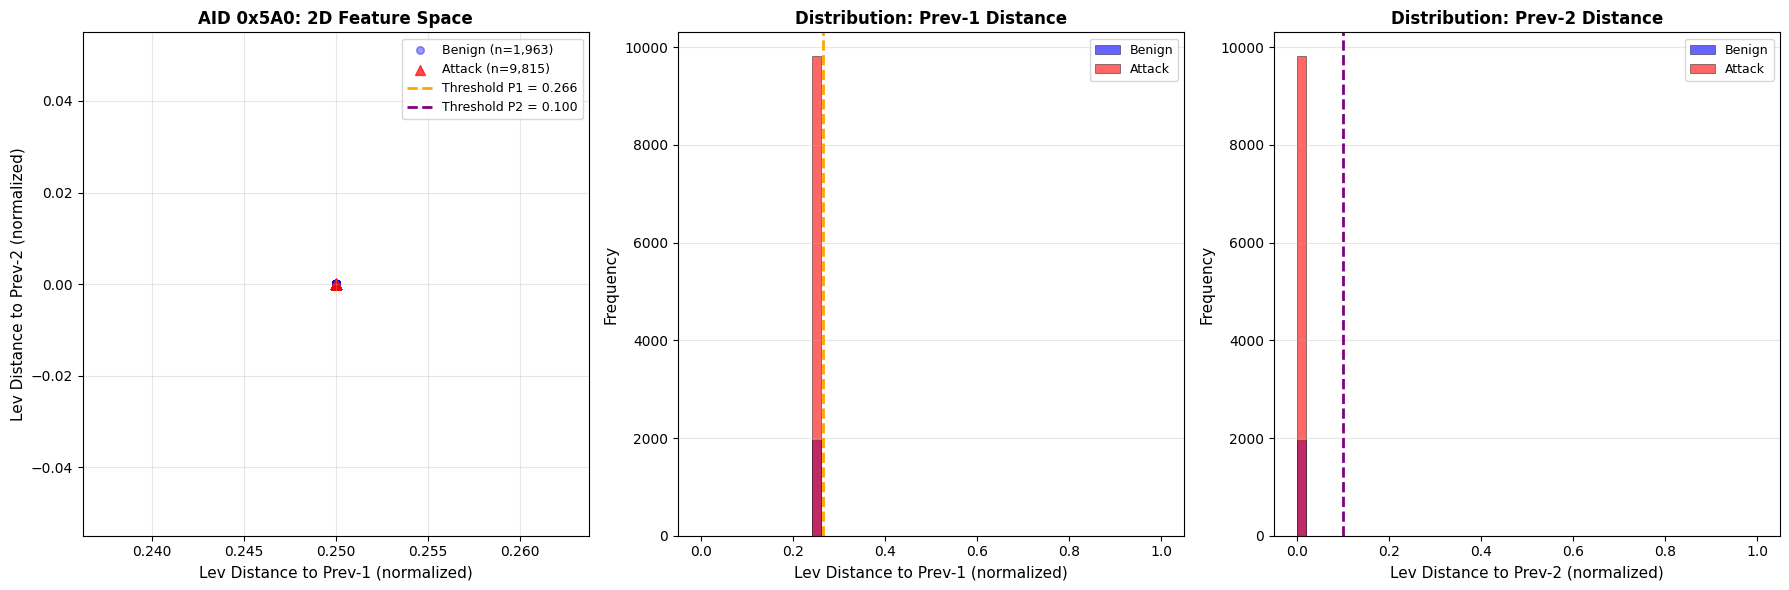


AID 0x5A0 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):       0  (attacks detected)
   False Negatives (FN):   9815  (attacks missed)
   True Negatives (TN):    1963  (benign correctly classified)
   False Positives (FP):      0  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.67%
   Detection Rate (TPR):   0.00%  (How many attacks caught)
   False Alarm Rate:       0.00%  (How many benign flagged)
   Precision:              0.00%  (When flagged, how often correct)
   F1-Score:               0.00%


──────────────────────────────────────────────────────────────────────
🎯 Processing AID 0x5B0 (masq-5B0h)
──────────────────────────────────────────────────────────────────────

🔍 Threshold Search for AID 0x5B0
Data: 1,961 benign, 9,805 attack samples
Target: max FPR = 1.0%, optimize F1

🔄 Searching threshold space...

✅ Best configuration found:
   Threshold P1: 0.266
   Threshold P2: 0.266

   Performance:
   - Detection Rate

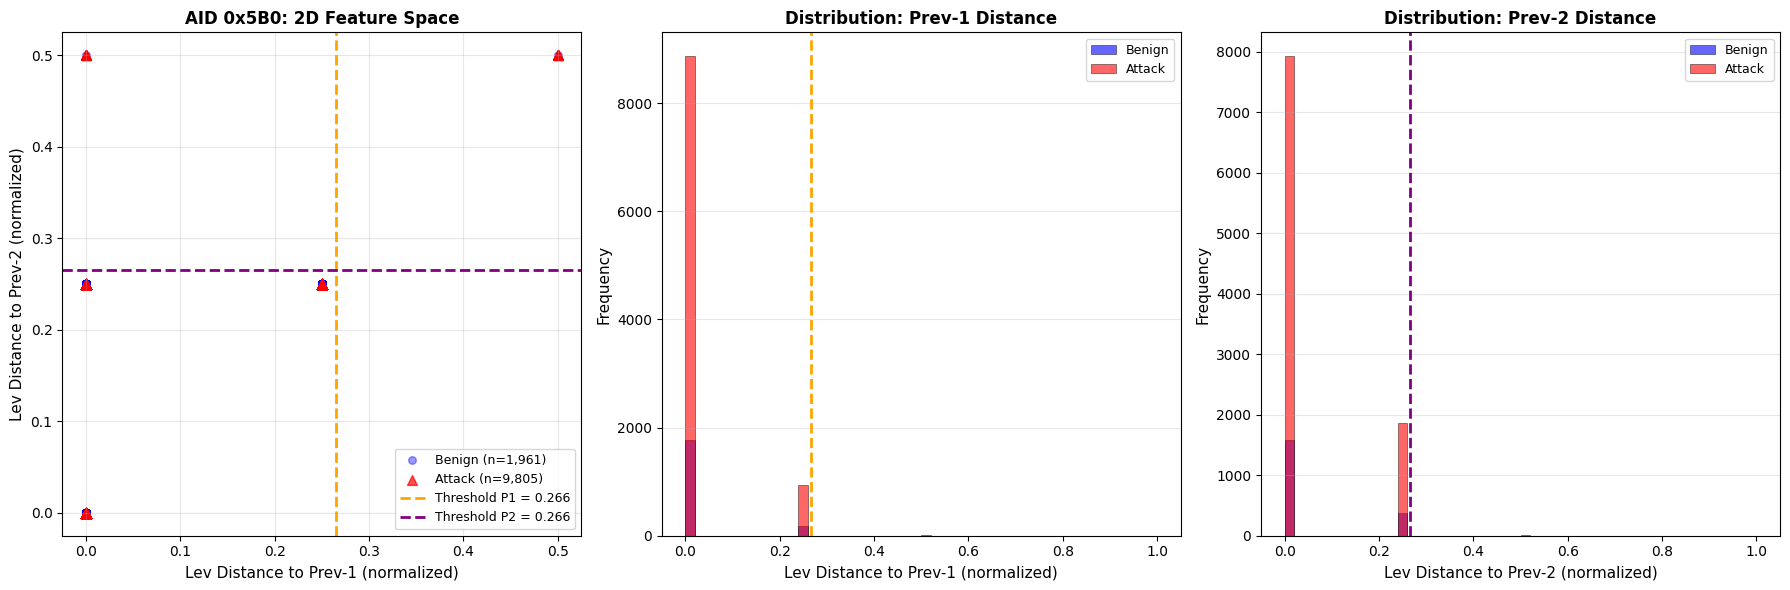


AID 0x5B0 - Threshold Performance Analysis

📊 Confusion Matrix:
   True Positives (TP):      10  (attacks detected)
   False Negatives (FN):   9795  (attacks missed)
   True Negatives (TN):    1959  (benign correctly classified)
   False Positives (FP):      2  (benign flagged as attack)

🎯 Performance Metrics:
   Accuracy:             16.73%
   Detection Rate (TPR):   0.10%  (How many attacks caught)
   False Alarm Rate:       0.10%  (How many benign flagged)
   Precision:             83.33%  (When flagged, how often correct)
   F1-Score:               0.20%


✅ Detailed results saved to: artifacts/batch_results/batch_analysis_summary.csv

📊 BATCH ANALYSIS SUMMARY

✅ Successfully analyzed: 34 AIDs
❌ Failed to analyze: 1 AIDs

📈 Performance Statistics (Successful AIDs):
   Average Detection Rate: 1.8%
   Average False Alarm Rate: 0.35%
   Average F1-Score: 3.3%

🏆 Top 5 Performers (by F1-Score):
aid_hex  detection_rate  false_alarm_rate  f1_score
  0x111       10.694396          0.993

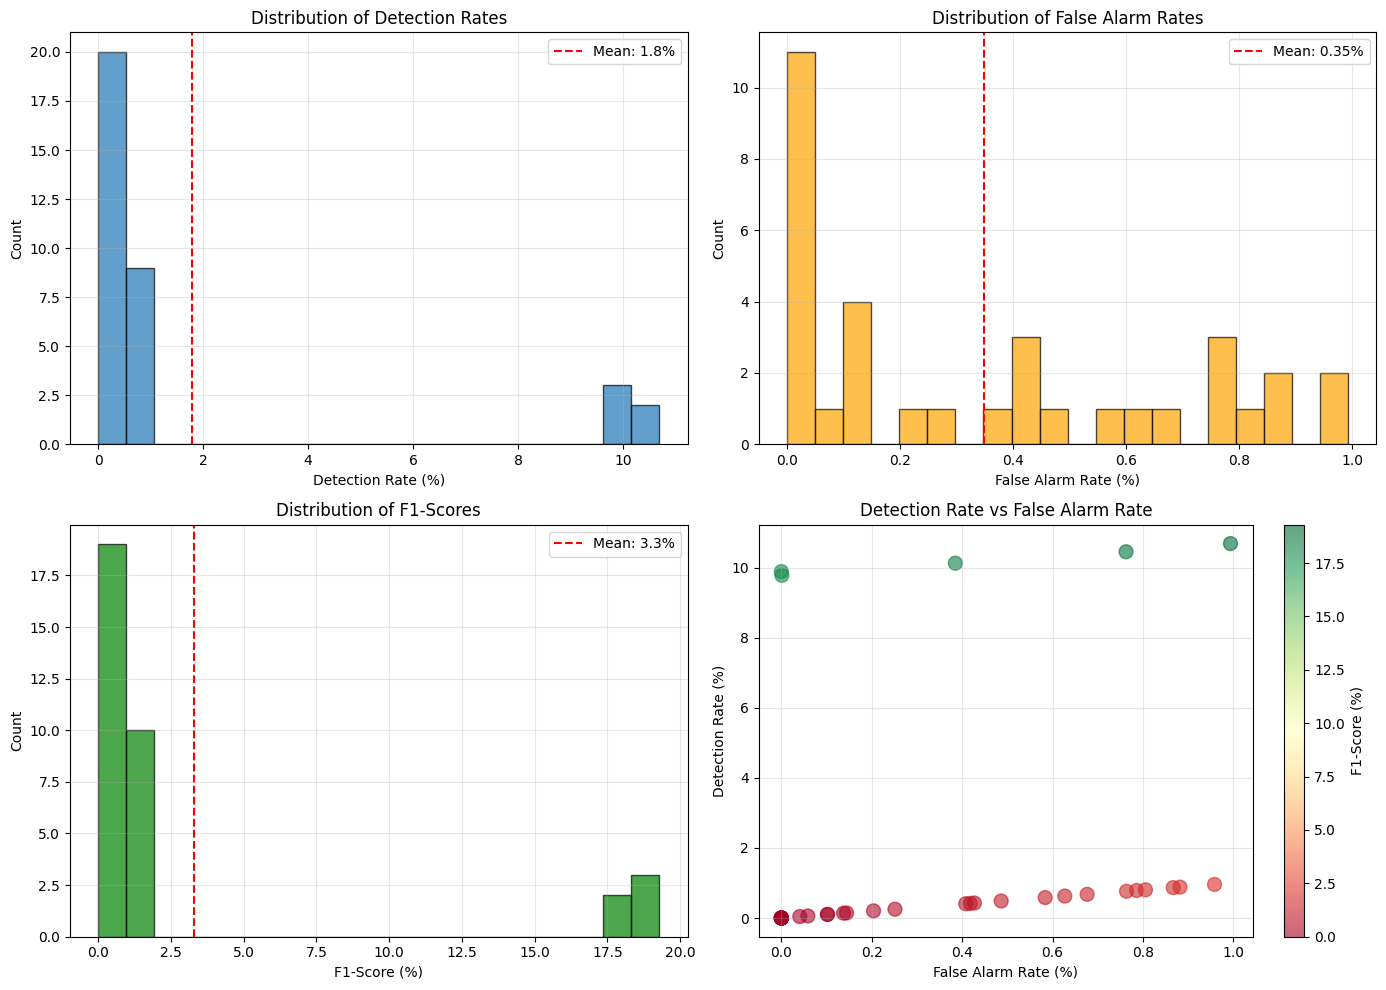

📨 Sent: ✅ DONE: Cell 9: Batch analysis of all masqueraded AIDs
Duration: 60.6 min


In [ ]:
"""with notify_wrap("Cell 9: Batch analysis of all masqueraded AIDs"):
    # ============================================================================
    # BATCH ANALYSIS: Process all masqueraded AIDs automatically
    # ============================================================================

    def batch_analyze_attacks(benign_csv, attack_csv, masq_ids, 
                            target_fpr=0.01, save_dir="artifacts/batch_results"):
        
        Analyze all masqueraded AIDs and generate comprehensive report.
        
        Args:
            benign_csv: Path to benign Levenshtein data
            attack_csv: Path to attack Levenshtein data
            masq_ids: List of masqueraded ID strings (e.g., ['044h', '080h', ...])
            target_fpr: Maximum acceptable false positive rate
            save_dir: Directory to save all results
        
        Path(save_dir).mkdir(parents=True, exist_ok=True)
        
        results = []
        
        print("="*70)
        print(f"🚀 BATCH ANALYSIS: Processing {len(masq_ids)} Masqueraded AIDs")
        print("="*70)
        
        for masq_id in masq_ids:
            # Convert hex string to decimal (e.g., '044h' -> 68)
            try:
                aid = int(masq_id.replace('h', ''), 16)
            except:
                print(f"⚠️  Could not parse masq_id: {masq_id}")
                continue
            
            print(f"\n{'─'*70}")
            print(f"🎯 Processing AID 0x{aid:03X} (masq-{masq_id})")
            print(f"{'─'*70}")
            
            # Find optimal thresholds
            config = suggest_thresholds(
                benign_csv=benign_csv,
                attack_csv=attack_csv,
                aid=aid,
                target_fpr=target_fpr,
                metric='f1'
            )
            
            if config is None:
                print(f"⚠️  Skipping 0x{aid:03X} - no suitable thresholds found")
                results.append({
                    'masq_id': masq_id,
                    'aid': aid,
                    'aid_hex': f"0x{aid:03X}",
                    'status': 'FAILED',
                    'reason': 'No thresholds meeting FPR constraint'
                })
                continue
            
            # Generate visualization with optimal thresholds
            plot_result = plot_threshold_analysis(
                benign_csv=benign_csv,
                attack_csv=attack_csv,
                aid=aid,
                threshold_p1=config['t_p1'],
                threshold_p2=config['t_p2'],
                save_prefix=f"{save_dir}/aid_{masq_id}"
            )
            
            # Store results
            result = {
                'masq_id': masq_id,
                'aid': aid,
                'aid_hex': f"0x{aid:03X}",
                'status': 'SUCCESS',
                'threshold_p1': config['t_p1'],
                'threshold_p2': config['t_p2'],
                'detection_rate': config['recall'] * 100,
                'false_alarm_rate': config['fpr'] * 100,
                'precision': config['precision'] * 100,
                'f1_score': config['f1'] * 100,
                'TP': config['TP'],
                'FP': config['FP'],
                'TN': config['TN'],
                'FN': config['FN']
            }
            results.append(result)
        
        # Create summary DataFrame
        results_df = pd.DataFrame(results)
        
        # Save detailed CSV
        csv_path = f"{save_dir}/batch_analysis_summary.csv"
        results_df.to_csv(csv_path, index=False)
        print(f"\n✅ Detailed results saved to: {csv_path}")
        
        # Print summary table
        print("\n" + "="*70)
        print("📊 BATCH ANALYSIS SUMMARY")
        print("="*70)
        
        successful = results_df[results_df['status'] == 'SUCCESS']
        failed = results_df[results_df['status'] == 'FAILED']
        
        print(f"\n✅ Successfully analyzed: {len(successful)} AIDs")
        print(f"❌ Failed to analyze: {len(failed)} AIDs")
        
        if len(successful) > 0:
            print("\n📈 Performance Statistics (Successful AIDs):")
            print(f"   Average Detection Rate: {successful['detection_rate'].mean():.1f}%")
            print(f"   Average False Alarm Rate: {successful['false_alarm_rate'].mean():.2f}%")
            print(f"   Average F1-Score: {successful['f1_score'].mean():.1f}%")
            
            print("\n🏆 Top 5 Performers (by F1-Score):")
            top5 = successful.nlargest(5, 'f1_score')[
                ['aid_hex', 'detection_rate', 'false_alarm_rate', 'f1_score']
            ]
            print(top5.to_string(index=False))
            
            print("\n⚠️  Bottom 5 Performers (by F1-Score):")
            bottom5 = successful.nsmallest(5, 'f1_score')[
                ['aid_hex', 'detection_rate', 'false_alarm_rate', 'f1_score']
            ]
            print(bottom5.to_string(index=False))
        
        if len(failed) > 0:
            print(f"\n❌ Failed AIDs:")
            print(failed[['aid_hex', 'reason']].to_string(index=False))
        
        print("\n" + "="*70)
        
        return results_df


    # ============================================================================
    # RUN BATCH ANALYSIS
    # ============================================================================

    batch_results = batch_analyze_attacks(
        benign_csv="artifacts/benign_lev.csv",
        attack_csv="artifacts/attack_lev.csv",
        masq_ids=masq_ids,  # Use the list from earlier
        target_fpr=0.01,     # 1% false alarm rate
        save_dir="artifacts/batch_results"
    )

    # Optional: Create a visual summary report
    print("\n📊 Generating visual summary report...")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    successful = batch_results[batch_results['status'] == 'SUCCESS']

    if len(successful) > 0:
        # Plot 1: Detection Rate distribution
        axes[0, 0].hist(successful['detection_rate'], bins=20, edgecolor='black', alpha=0.7)
        axes[0, 0].set_xlabel('Detection Rate (%)')
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].set_title('Distribution of Detection Rates')
        axes[0, 0].axvline(successful['detection_rate'].mean(), color='red', 
                        linestyle='--', label=f'Mean: {successful["detection_rate"].mean():.1f}%')
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)
        
        # Plot 2: False Alarm Rate distribution
        axes[0, 1].hist(successful['false_alarm_rate'], bins=20, edgecolor='black', 
                    alpha=0.7, color='orange')
        axes[0, 1].set_xlabel('False Alarm Rate (%)')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].set_title('Distribution of False Alarm Rates')
        axes[0, 1].axvline(successful['false_alarm_rate'].mean(), color='red', 
                        linestyle='--', label=f'Mean: {successful["false_alarm_rate"].mean():.2f}%')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)
        
        # Plot 3: F1-Score distribution
        axes[1, 0].hist(successful['f1_score'], bins=20, edgecolor='black', 
                    alpha=0.7, color='green')
        axes[1, 0].set_xlabel('F1-Score (%)')
        axes[1, 0].set_ylabel('Count')
        axes[1, 0].set_title('Distribution of F1-Scores')
        axes[1, 0].axvline(successful['f1_score'].mean(), color='red', 
                        linestyle='--', label=f'Mean: {successful["f1_score"].mean():.1f}%')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
        
        # Plot 4: Detection Rate vs False Alarm Rate scatter
        axes[1, 1].scatter(successful['false_alarm_rate'], successful['detection_rate'], 
                        s=100, alpha=0.6, c=successful['f1_score'], cmap='RdYlGn')
        axes[1, 1].set_xlabel('False Alarm Rate (%)')
        axes[1, 1].set_ylabel('Detection Rate (%)')
        axes[1, 1].set_title('Detection Rate vs False Alarm Rate')
        axes[1, 1].grid(alpha=0.3)
        cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
        cbar.set_label('F1-Score (%)')

    plt.tight_layout()
    plt.savefig('artifacts/batch_results/summary_statistics.png', dpi=300, bbox_inches='tight')
    print("✅ Summary report saved to: artifacts/batch_results/summary_statistics.png")"""
    plt.show()

In [ ]:
notify_cell("✅ batch analysis completed and program ended")

📨 Sent: ✅ batch analysis completed and program ended


True

In [ ]:
"""def hex_to_bytes(h):
    if h is None or (isinstance(h, float) and np.isnan(h)): return b""
    if isinstance(h, (bytes, bytearray)): return bytes(h)
    s = str(h).strip().replace("0x","").replace(" ","")
    if s == "": return b""
    if len(s) % 2 == 1: s = "0"+s
    try: return bytes.fromhex(s)
    except Exception: return str(h).encode("utf-8", errors="ignore")

def lev_bytes(a: bytes, b: bytes) -> int:
    m, n = len(a), len(b)
    if m == 0: return n
    if n == 0: return m
    prev = list(range(n+1))
    for i in range(1, m+1):
        curr = [i] + [0]*n
        ai = a[i-1]
        for j in range(1, n+1):
            cost = 0 if ai == b[j-1] else 1
            curr[j] = min(curr[j-1]+1, prev[j]+1, prev[j-1]+cost)
        prev = curr
    return prev[n]

def compute_payload_lev(dumps, out_csv="artifacts/payload_lev.csv", process_per_dump=True):
    
    dumps: list of tuples (dump_name, df). df should have columns:
           ['arbitration_id','data'] and ideally ['timestamp','dlc','label'].
    Saves CSV with: dump, timestamp, arbitration_id, payload_len,
           lev_dist_min, lev_norm_min, lev_dist_p1, lev_norm_p1, lev_dist_p2, lev_norm_p2, label
    
    Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
    recs = []
    prev_by_aid = defaultdict(lambda: deque(maxlen=2))  # aid -> deque([prev1, prev2])

    for dump_name, df in dumps:
        d = df.copy()

        # Ensure we have a timestamp column
        if "timestamp" not in d.columns:
            if d.index.name == "timestamp":
                d = d.reset_index()
            else:
                d = d.reset_index().rename(columns={"index":"timestamp"})
        d = d.sort_values("timestamp", kind="mergesort")

        has_label = "label" in d.columns

        for _, row in d.iterrows():
            aid = row["arbitration_id"]
            ts  = row["timestamp"]
            lab = int(row["label"]) if has_label and not pd.isna(row["label"]) else 0
            curb = hex_to_bytes(row["data"])

            dq = prev_by_aid[aid]                 # deque for this ID
            p1 = dq[-1] if len(dq) >= 1 else None
            p2 = dq[-2] if len(dq) >= 2 else None

            if p1 is not None:
                d1 = lev_bytes(curb, p1);  L1 = max(len(curb), len(p1));  n1 = d1 / L1 if L1 > 0 else np.nan
                if p2 is not None:
                    d2 = lev_bytes(curb, p2);  L2 = max(len(curb), len(p2));  n2 = d2 / L2 if L2 > 0 else np.nan
                else:
                    d2, n2, L2 = np.nan, np.nan, np.nan

                # min distance and its normalization
                if p2 is None or (not np.isnan(d1) and (np.isnan(d2) or d1 <= d2)):
                    dm, Lm = d1, L1
                else:
                    dm, Lm = d2, L2
                nm = dm / Lm if Lm and Lm > 0 else np.nan

                recs.append({
                    "dump": dump_name,
                    "timestamp": ts,
                    "arbitration_id": aid,
                    "payload_len": len(curb),
                    "lev_dist_min": int(dm),
                    "lev_norm_min": float(nm),
                    "lev_dist_p1": int(d1), "lev_norm_p1": float(n1),
                    "lev_dist_p2": (int(d2) if not np.isnan(d2) else np.nan),
                    "lev_norm_p2": (float(n2) if not np.isnan(n2) else np.nan),
                    "label": lab
                })

            # append current payload (deque keeps only last 2)
            dq.append(curb)

        if process_per_dump:
            # Start fresh for next dump (no cross-dump comparisons)
            prev_by_aid.clear()

    out = pd.DataFrame.from_records(recs)
    # make sure numeric columns are numeric
    num_cols = ["lev_dist_min","lev_norm_min","lev_dist_p1","lev_norm_p1","lev_dist_p2","lev_norm_p2","payload_len"]
    for c in num_cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    out.to_csv(out_csv, index=False)
    print(f"[saved] {out_csv}  rows={len(out):,}")
    return out

# EXAMPLE — benign only (hold out dump6 for attacks later)
dumps = [("dump6", dump6)]
#dumps = [("dump1", dump1), ("dump2", dump2), ("dump3", dump3),
#         ("dump4", dump4), ("dump5", dump5), ("dump6", dump6), ("dump7", dump7)]
lev_df = compute_payload_lev(dumps, out_csv="artifacts/payload_lev.csv", process_per_dump=True)

# quick per-ID summary (mean/std/min/max on lev_norm_min)
summary = (lev_df.groupby("arbitration_id")["lev_norm_min"]
           .agg(['count','mean','std','min','max'])
           .sort_values("count", ascending=False))
display(summary.head(30))
summary.to_csv("artifacts/payload_lev_per_id_summary.csv")

lev_df = compute_payload_lev(
    dumps,
    out_csv="artifacts/payload_lev_dump1.csv",
    process_per_dump=True  # harmless with a single dump
)"""

'def hex_to_bytes(h):\n    if h is None or (isinstance(h, float) and np.isnan(h)): return b""\n    if isinstance(h, (bytes, bytearray)): return bytes(h)\n    s = str(h).strip().replace("0x","").replace(" ","")\n    if s == "": return b""\n    if len(s) % 2 == 1: s = "0"+s\n    try: return bytes.fromhex(s)\n    except Exception: return str(h).encode("utf-8", errors="ignore")\n\ndef lev_bytes(a: bytes, b: bytes) -> int:\n    m, n = len(a), len(b)\n    if m == 0: return n\n    if n == 0: return m\n    prev = list(range(n+1))\n    for i in range(1, m+1):\n        curr = [i] + [0]*n\n        ai = a[i-1]\n        for j in range(1, n+1):\n            cost = 0 if ai == b[j-1] else 1\n            curr[j] = min(curr[j-1]+1, prev[j]+1, prev[j-1]+cost)\n        prev = curr\n    return prev[n]\n\ndef compute_payload_lev(dumps, out_csv="artifacts/payload_lev.csv", process_per_dump=True):\n\n    dumps: list of tuples (dump_name, df). df should have columns:\n           [\'arbitration_id\',\'data\'] a

In [ ]:
"""# CELL 2 — Plotting (Levenshtein only)
LEV_CSV = "artifacts/payload_lev_dump6.csv"
df = pd.read_csv(LEV_CSV)

def pick_top_id(df, min_count=100):
    counts = df["arbitration_id"].value_counts()
    for aid, c in counts.items():
        if c >= min_count: return aid
    return counts.index[0] if len(counts) else None

def plot_time_series(df, aid, metric="lev_norm_min", last_n=4000, save_prefix=None):
    d = df[df["arbitration_id"] == aid].sort_values("timestamp")
    if d.empty:
        print("No data for", aid); return
    y = d[metric].to_numpy(dtype=float)
    x = np.arange(len(y))
    y = y[-last_n:]
    x = x[-last_n:]
    plt.figure(figsize=(12,3))
    plt.plot(x, y, linewidth=0.9)
    plt.title(f"AID={aid}  {metric} over time (last {len(y)} windows)")
    plt.xlabel("window index"); plt.ylabel(metric); plt.grid(alpha=0.3)
    if save_prefix:
        Path(save_prefix).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(f"{save_prefix}_timeseries_{aid}.png", dpi=200, bbox_inches="tight")
    plt.show()

def plot_hist(df, aid, metric="lev_norm_min", bins=60, save_prefix=None):
    d = df[df["arbitration_id"] == aid]
    if d.empty:
        print("No data for", aid); return
    v = d[metric].to_numpy(dtype=float)
    v = v[~np.isnan(v)]
    plt.figure(figsize=(6,3))
    plt.hist(v, bins=bins)
    plt.title(f"AID={aid}  {metric} histogram")
    plt.xlabel(metric); plt.ylabel("count"); plt.grid(alpha=0.3)
    if save_prefix:
        Path(save_prefix).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(f"{save_prefix}_hist_{aid}.png", dpi=200, bbox_inches="tight")
    plt.show()

def plot_scatter_prev1_prev2(df, aid, save_prefix=None, slope=-1.0, intercept=0.8):
    
    2D scatter of normalized distances to prev1 vs prev2.
    This is the “structure” view you wanted (manual linear boundary you can tweak).
    
    d = df[df["arbitration_id"] == aid].copy()
    if d.empty:
        print("No data for", aid); return
    x = d["lev_norm_p1"].to_numpy(dtype=float)
    y = d["lev_norm_p2"].to_numpy(dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]
    if len(x) == 0:
        print("Not enough (prev2) points for scatter."); return

    plt.figure(figsize=(6,6))
    plt.scatter(x, y, s=8, alpha=0.8)
    plt.xlabel("lev_norm to prev1"); plt.ylabel("lev_norm to prev2")
    plt.title(f"AID={aid}  scatter(prev1, prev2)")
    plt.grid(alpha=0.3)

    # manual decision line: y = slope*x + intercept
    xx = np.linspace(np.nanmin(x), np.nanmax(x), 200)
    yy = slope*xx + intercept
    plt.plot(xx, yy, linewidth=1.5)

    if save_prefix:
        Path(save_prefix).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(f"{save_prefix}_scatter_prev_{aid}.png", dpi=200, bbox_inches="tight")
    plt.show()

# ---- Example run (pick an ID and plot the three views) ----
aid_example = 274 #pick_top_id(df, min_count=200)
print("Chosen AID:", aid_example)

plot_time_series(df, aid_example, metric="lev_norm_min", last_n=4000,
                 save_prefix="artifacts/plots/lev")
plot_hist(df, aid_example, metric="lev_norm_min", bins=60,
          save_prefix="artifacts/plots/lev")
plot_scatter_prev1_prev2(df, aid_example, save_prefix="artifacts/plots/lev",
                         slope=-1.0, intercept=0.8)"""


'# CELL 2 — Plotting (Levenshtein only)\nLEV_CSV = "artifacts/payload_lev_dump6.csv"\ndf = pd.read_csv(LEV_CSV)\n\ndef pick_top_id(df, min_count=100):\n    counts = df["arbitration_id"].value_counts()\n    for aid, c in counts.items():\n        if c >= min_count: return aid\n    return counts.index[0] if len(counts) else None\n\ndef plot_time_series(df, aid, metric="lev_norm_min", last_n=4000, save_prefix=None):\n    d = df[df["arbitration_id"] == aid].sort_values("timestamp")\n    if d.empty:\n        print("No data for", aid); return\n    y = d[metric].to_numpy(dtype=float)\n    x = np.arange(len(y))\n    y = y[-last_n:]\n    x = x[-last_n:]\n    plt.figure(figsize=(12,3))\n    plt.plot(x, y, linewidth=0.9)\n    plt.title(f"AID={aid}  {metric} over time (last {len(y)} windows)")\n    plt.xlabel("window index"); plt.ylabel(metric); plt.grid(alpha=0.3)\n    if save_prefix:\n        Path(save_prefix).parent.mkdir(parents=True, exist_ok=True)\n        plt.savefig(f"{save_prefix}_timeseri

In [ ]:
"""aid = 544  # change per plot
d = lev_df[lev_df.arbitration_id == aid]

# 1) DLC / payload length stability
print(d["payload_len"].describe())      # should be a single value (e.g., 8.0)

# 2) Are lev_norm_min values near multiples of 1 / DLC?
dlc = int(d["payload_len"].mode().iloc[0])
step = 1.0 / dlc
vals = d["lev_norm_min"].dropna().to_numpy()
print("unique bins (rounded):", sorted(set(np.round(vals/step)*step))[:10])

# 3) What fraction of frames are in the main mode?
mode_bin = np.round(vals/step)*step
counts = np.bincount((mode_bin/step).astype(int))
print("mode freq:", counts.max()/counts.sum())"""


'aid = 544  # change per plot\nd = lev_df[lev_df.arbitration_id == aid]\n\n# 1) DLC / payload length stability\nprint(d["payload_len"].describe())      # should be a single value (e.g., 8.0)\n\n# 2) Are lev_norm_min values near multiples of 1 / DLC?\ndlc = int(d["payload_len"].mode().iloc[0])\nstep = 1.0 / dlc\nvals = d["lev_norm_min"].dropna().to_numpy()\nprint("unique bins (rounded):", sorted(set(np.round(vals/step)*step))[:10])\n\n# 3) What fraction of frames are in the main mode?\nmode_bin = np.round(vals/step)*step\ncounts = np.bincount((mode_bin/step).astype(int))\nprint("mode freq:", counts.max()/counts.sum())'

In [ ]:
"""# ============================================================================
# DECISION BOUNDARY VISUALIZATION (2D Feature Space)
# ============================================================================

def plot_decision_boundary_2d(benign_csv, attack_csv, aid, 
                               classifier_type='linear_svm',
                               save_prefix=None):
   
    Visualize decision boundary in 2D feature space (lev_norm_p1 vs lev_norm_p2).
    
    This is BETTER than histograms when you have 2 features because it shows:
    - Spatial clustering of benign vs attack
    - Non-linear separation patterns
    - Confidence regions
    
    Args:
        benign_csv: Path to benign data CSV
        attack_csv: Path to attack data CSV
        aid: Arbitration ID to analyze
        classifier_type: 'linear_svm', 'rbf_svm', 'logistic', 'tree', or 'rf'
        save_prefix: Optional path prefix for saving plots
    
    benign = pd.read_csv(benign_csv)
    attack = pd.read_csv(attack_csv)
    
    # Filter for specific arbitration ID
    b_data = benign[benign['arbitration_id'] == aid][['lev_norm_p1', 'lev_norm_p2']].dropna()
    a_data = attack[attack['arbitration_id'] == aid][['lev_norm_p1', 'lev_norm_p2']].dropna()
    
    if len(b_data) < 50 or len(a_data) < 10:
        print(f"⚠️  AID 0x{aid:03X}: Insufficient 2D data (benign={len(b_data)}, attack={len(a_data)})")
        return None
    
    # Prepare data
    X_benign = b_data.values
    X_attack = a_data.values
    X = np.vstack([X_benign, X_attack])
    y = np.concatenate([np.zeros(len(X_benign)), np.ones(len(X_attack))])
    
    # Train classifier
    classifiers = {
        'linear_svm': SVC(kernel='linear', C=1.0, probability=True),
        'rbf_svm': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True),
        'logistic': LogisticRegression(max_iter=1000),
        'tree': DecisionTreeClassifier(max_depth=5),
        'rf': RandomForestClassifier(n_estimators=100, max_depth=5)
    }
    
    clf = classifiers.get(classifier_type, classifiers['linear_svm'])
    clf.fit(X, y)
    
    # Calculate performance
    y_pred = clf.predict(X)
    accuracy = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    # Create mesh for decision boundary
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    h = 0.01  # Step size in mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict on mesh
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # ---- LEFT PLOT: Decision Boundary with Data Points ----
    cmap_light = ListedColormap(['#AAFFAA', '#FFAAAA'])  # Light green/red
    cmap_bold = ['#00AA00', '#FF0000']  # Dark green/red
    
    axes[0].contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    
    # Plot data points
    axes[0].scatter(X_benign[:, 0], X_benign[:, 1], 
                   c='green', marker='o', s=30, alpha=0.6, 
                   edgecolors='darkgreen', linewidth=0.5, label='Benign')
    axes[0].scatter(X_attack[:, 0], X_attack[:, 1], 
                   c='red', marker='^', s=50, alpha=0.8, 
                   edgecolors='darkred', linewidth=0.5, label='Attack')
    
    axes[0].set_xlabel('Levenshtein Distance to Prev-1 (normalized)', fontsize=11)
    axes[0].set_ylabel('Levenshtein Distance to Prev-2 (normalized)', fontsize=11)
    axes[0].set_title(f'AID 0x{aid:03X}: Decision Boundary ({classifier_type})\n'
                     f'Accuracy: {accuracy*100:.1f}%, F1: {f1*100:.1f}%', fontsize=12)
    axes[0].legend(fontsize=10, loc='best')
    axes[0].grid(alpha=0.3)
    
    # ---- RIGHT PLOT: Confidence/Probability Heatmap ----
    if hasattr(clf, 'predict_proba'):
        Z_proba = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
        Z_proba = Z_proba.reshape(xx.shape)
        
        im = axes[1].contourf(xx, yy, Z_proba, levels=20, cmap='RdYlGn_r', alpha=0.8)
        plt.colorbar(im, ax=axes[1], label='Attack Probability')
        
        # Overlay data points
        axes[1].scatter(X_benign[:, 0], X_benign[:, 1], 
                       c='blue', marker='o', s=20, alpha=0.4, label='Benign')
        axes[1].scatter(X_attack[:, 0], X_attack[:, 1], 
                       c='red', marker='^', s=40, alpha=0.7, label='Attack')
        
        axes[1].set_xlabel('Levenshtein Distance to Prev-1 (normalized)', fontsize=11)
        axes[1].set_ylabel('Levenshtein Distance to Prev-2 (normalized)', fontsize=11)
        axes[1].set_title(f'AID 0x{aid:03X}: Attack Probability Heatmap', fontsize=12)
        axes[1].legend(fontsize=10, loc='best')
        axes[1].grid(alpha=0.3)
    else:
        # For classifiers without probability, show decision regions
        axes[1].contourf(xx, yy, Z, alpha=0.5, cmap=cmap_light)
        axes[1].scatter(X_benign[:, 0], X_benign[:, 1], 
                       c='green', marker='o', s=30, alpha=0.6, label='Benign')
        axes[1].scatter(X_attack[:, 0], X_attack[:, 1], 
                       c='red', marker='^', s=50, alpha=0.8, label='Attack')
        axes[1].set_title(f'AID 0x{aid:03X}: Decision Regions', fontsize=12)
        axes[1].legend()
    
    plt.tight_layout()
    
    if save_prefix:
        Path(save_prefix).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(f"{save_prefix}_decision_boundary_0x{aid:03X}.png", 
                   dpi=300, bbox_inches='tight')
        print(f"📊 Saved: {save_prefix}_decision_boundary_0x{aid:03X}.png")
    
    plt.show()
    
    # Print detailed report
    print(f"\n{'='*70}")
    print(f"AID 0x{aid:03X} - Decision Boundary Analysis ({classifier_type})")
    print(f"{'='*70}")
    print(f"\n📊 Data Summary:")
    print(f"   Benign samples:  {len(X_benign):,}")
    print(f"   Attack samples:  {len(X_attack):,}")
    print(f"\n🎯 Classifier Performance:")
    print(f"   Accuracy:  {accuracy*100:.2f}%")
    print(f"   F1-Score:  {f1*100:.2f}%")
    print(f"\n📋 Classification Report:")
    print(classification_report(y, y_pred, target_names=['Benign', 'Attack']))
    print(f"{'='*70}\n")
    
    return {
        'aid': aid,
        'classifier': classifier_type,
        'accuracy': accuracy,
        'f1_score': f1,
        'n_benign': len(X_benign),
        'n_attack': len(X_attack)
    }"""

'# ============================================================================\n# DECISION BOUNDARY VISUALIZATION (2D Feature Space)\n# ============================================================================\n\ndef plot_decision_boundary_2d(benign_csv, attack_csv, aid, \n                               classifier_type=\'linear_svm\',\n                               save_prefix=None):\n\n    Visualize decision boundary in 2D feature space (lev_norm_p1 vs lev_norm_p2).\n\n    This is BETTER than histograms when you have 2 features because it shows:\n    - Spatial clustering of benign vs attack\n    - Non-linear separation patterns\n    - Confidence regions\n\n    Args:\n        benign_csv: Path to benign data CSV\n        attack_csv: Path to attack data CSV\n        aid: Arbitration ID to analyze\n        classifier_type: \'linear_svm\', \'rbf_svm\', \'logistic\', \'tree\', or \'rf\'\n        save_prefix: Optional path prefix for saving plots\n\n    benign = pd.read_csv(benign_csv)\

In [ ]:
"""def plot_manual_threshold_lines(benign_csv, attack_csv, aid, 
                                 threshold_p1=0.5, threshold_p2=0.5,
                                 threshold_combined=None,
                                 save_prefix=None):
    
    Plot with MANUAL threshold lines (like in your drawing).
    
    This lets you visually tune thresholds by drawing lines:
    - Vertical line at lev_norm_p1 = threshold_p1
    - Horizontal line at lev_norm_p2 = threshold_p2
    - Diagonal line if threshold_combined specified (e.g., "p1 + p2 > X")
    
    Args:
        threshold_combined: Tuple (slope, intercept) for diagonal line
                           e.g., (-1, 0.8) means: p2 = -1*p1 + 0.8
    
    benign = pd.read_csv(benign_csv)
    attack = pd.read_csv(attack_csv)
    
    b_data = benign[benign['arbitration_id'] == aid][['lev_norm_p1', 'lev_norm_p2']].dropna()
    a_data = attack[attack['arbitration_id'] == aid][['lev_norm_p1', 'lev_norm_p2']].dropna()
    
    if len(b_data) < 10 or len(a_data) < 10:
        print(f"⚠️  Insufficient data")
        return None
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot data points
    ax.scatter(b_data['lev_norm_p1'], b_data['lev_norm_p2'], 
              c='blue', marker='o', s=40, alpha=0.5, label='Benign')
    ax.scatter(a_data['lev_norm_p1'], a_data['lev_norm_p2'], 
              c='red', marker='^', s=60, alpha=0.7, label='Attack')
    
    # Plot threshold lines
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Vertical threshold (on prev-1)
    ax.axvline(threshold_p1, color='orange', linestyle='--', linewidth=2, 
              label=f'Threshold P1 = {threshold_p1:.3f}')
    
    # Horizontal threshold (on prev-2)
    ax.axhline(threshold_p2, color='purple', linestyle='--', linewidth=2,
              label=f'Threshold P2 = {threshold_p2:.3f}')
    
    # Diagonal/combined threshold (like in your drawing)
    if threshold_combined:
        slope, intercept = threshold_combined
        x_line = np.linspace(xlim[0], xlim[1], 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, color='orange', linestyle='-', linewidth=3,
               label=f'Combined: P2 = {slope:.2f}*P1 + {intercept:.2f}')
    
    ax.set_xlabel('Levenshtein Distance to Prev-1 (normalized)', fontsize=12)
    ax.set_ylabel('Levenshtein Distance to Prev-2 (normalized)', fontsize=12)
    ax.set_title(f'AID 0x{aid:03X}: Manual Threshold Lines', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    plt.tight_layout()
    
    if save_prefix:
        Path(save_prefix).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(f"{save_prefix}_manual_thresholds_0x{aid:03X}.png", 
                   dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Calculate performance with manual thresholds
    def apply_threshold(data, t_p1, t_p2, t_comb):
        if t_comb:
            slope, intercept = t_comb
            return (data['lev_norm_p1'] > t_p1) | \
                   (data['lev_norm_p2'] > t_p2) | \
                   (data['lev_norm_p2'] > slope * data['lev_norm_p1'] + intercept)
        else:
            return (data['lev_norm_p1'] > t_p1) | (data['lev_norm_p2'] > t_p2)
    
    b_pred = apply_threshold(b_data, threshold_p1, threshold_p2, threshold_combined)
    a_pred = apply_threshold(a_data, threshold_p1, threshold_p2, threshold_combined)
    
    FP = b_pred.sum()
    TP = a_pred.sum()
    TN = len(b_data) - FP
    FN = len(a_data) - TP
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n{'='*70}")
    print(f"Manual Threshold Performance:")
    print(f"{'='*70}")
    print(f"  Detection Rate (Recall): {recall*100:.1f}%")
    print(f"  False Alarm Rate:        {(FP/len(b_data))*100:.1f}%")
    print(f"  Precision:               {precision*100:.1f}%")
    print(f"  F1-Score:                {f1*100:.1f}%")
    print(f"{'='*70}\n")""""""

SyntaxError: incomplete input (3242716043.py, line 101)

In [ ]:
"""if __name__ == "__main__":
    BENIGN_DF = pq.read_table(r"C:\Users\User\Desktop\OneDrive - Universita degli Studi Roma Tre\Desktop\MATERIALE TESI POLIMI\Filtered Papers\To Study In Depth\Possible Pipeline\First Layer\New_strategy\X-CANIDS\raw\dump6.parquet").to_pandas()
    ATTACK_DF = pq.read_table(r"C:\Users\User\Desktop\OneDrive - Universita degli Studi Roma Tre\Desktop\MATERIALE TESI POLIMI\Filtered Papers\To Study In Depth\Possible Pipeline\First Layer\New_strategy\X-CANIDS\raw\dump6-masq-044h.parquet").to_pandas()
    aid = 68  # 0x044
    
    print("🎯 Method 1: ML-based Decision Boundary")
    print("="*70)
    
    benign_lev_df = compute_payload_lev([("dump6", BENIGN_DF)], "artifacts/payload_lev.csv", process_per_dump=True)
    attack_lev_df = compute_payload_lev([("masq_044h", ATTACK_DF)], "artifacts/payload_lev.csv", process_per_dump=True)
    
    # Try different classifiers
    for clf_type in ['linear_svm', 'rbf_svm', 'logistic']:
        plot_decision_boundary_2d(
            BENIGN_DF, ATTACK_DF, aid,
            classifier_type=clf_type,
            save_prefix=f"artifacts/plots/boundary_{clf_type}"
        )
    
    print("\n🎯 Method 2: Manual Threshold Lines (Your Drawing Style)")
    print("="*70)
    
    # Plot with manual thresholds (you can adjust these!)
    plot_manual_threshold_lines(
        BENIGN_DF, ATTACK_DF, aid,
        threshold_p1=0.5,      # Adjust based on your data
        threshold_p2=0.5,      # Adjust based on your data
        threshold_combined=(-1, 0.8),  # Diagonal line: p2 = -p1 + 0.8
        save_prefix="artifacts/plots/manual"
    )"""